# Data extraction 

## Define current dictionnary 

In [153]:
import os
notebook_dir = os.getcwd()
print("Current notebook directory:", notebook_dir)

Current notebook directory: /home/a0342481/Analyses/WMH_analyses-main


## Define all good PR

In [168]:
# Import required libraries
import pandas as pd
import os

# Define file paths
flair_qc_path = os.path.join(notebook_dir, 'CSV/QC_FLAIR_160925.csv')
mpm_qc_path = os.path.join(notebook_dir, 'CSV/QC_MPM_160925.csv')
diff_qc_path = os.path.join(notebook_dir, 'CSV/QC_diffusion_160925.csv')

# Load datasets
flair_qc = pd.read_csv(flair_qc_path)
mpm_qc = pd.read_csv(mpm_qc_path)
diffusion_qc = pd.read_csv(diff_qc_path)

# Create PR variable
flair_qc['PR'] = flair_qc['NAMES FLAIR'].str[1:8]
flair_qc['QC_flair'] = flair_qc['QC']
mpm_qc['PR'] = mpm_qc['Names'].str[1:8]
diffusion_qc['PR'] = diffusion_qc['Names'].str[1:8]
diffusion_qc['QC_diff'] = diffusion_qc['QC']

# Merge QC togethe
flair_mpm_qc = pd.merge(flair_qc[['QC_flair','PR']], mpm_qc[['Names','QC_R1','QC_R2s','QC_MT','PR']], on='PR')
flair_mpm_diffusion_qc = pd.merge(flair_mpm_qc, diffusion_qc[['QC_diff','PR']], on='PR')

# Filter by QC criteria
good_QC = flair_mpm_diffusion_qc[
    (flair_mpm_diffusion_qc['QC_R1'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_R2s'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_MT'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_flair'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_diff'].astype(float) < 2.5)
]


# Create table with QC info
flair_mpm_diffusion_qc=flair_mpm_diffusion_qc.astype({'QC_flair': 'category', 'QC_R1': 'category', 'QC_R2s': 'category','QC_MT': 'category','QC_diff': 'category'})
#table_QC=TableOne(flair_mpm_diffusion_qc, columns=['QC_flair', 'QC_R1','QC_R2s','QC_MT','QC_diff'], pval=False)# Create a styled summary table
#table_QC.to_csv(os.path.join(notebook_dir, 'CSV/table_QC.csv'))

good_PR = good_QC['PR'].tolist()

# Print the length of good_PR for verification
print("Number of good PRs:", len(good_PR))


Number of good PRs: 479


## Define data (i.e. all good FLAIR + segmentation)

In [173]:
### cross-sectional from brainlaus

PT_to_colaudID = PT_to_colaudID.copy()  # Create a copy of the DataFrame
PT_to_colaudID['PR_short'] = PT_to_colaudID['SubjectName'].str[:7]
merged_PR = pd.merge(good_QC, PT_to_colaudID, left_on='PR', right_on='PR_short')
PR_colaus_cross_sectionnal = merged_PR[merged_PR['Unnamed: 0'] != 'UNKNOWN']
PR_colaus_cross_sectionnal = PR_colaus_cross_sectionnal[PR_colaus_cross_sectionnal['Unnamed: 0'] != 'NCCR']
PR_colaus_cross_sectionnal = PR_colaus_cross_sectionnal[PR_colaus_cross_sectionnal['Unnamed: 0'] != 'SACR']
PR_colaus_cross_sectionnal = PR_colaus_cross_sectionnal.copy()  # Create a copy of the DataFrame
PR_colaus_cross_sectionnal['PR'] = 's' + PR_colaus_cross_sectionnal['SubjectName'].str[:16]
len(PR_colaus_cross_sectionnal)

323

In [174]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np


# Load csv variable baseline
FU3_new = pd.read_csv(os.path.join(notebook_dir, 'CSV/ExtractedData_AB_20250424_20250516_172200_CoLaus_8_FU3.csv'))

# --- Step 1: Format valid_prs_wmh as DataFrame ---

PR_colaus_cross_sectionnal = pd.DataFrame(PR_colaus_cross_sectionnal, columns=['PR'])

# --- Step 2: Extract and clean FU3 and FU4 PRs ---
fu3_prs = FU3_new['CoLaus Follow up 3 PR number  '].dropna().astype(str)
fu3_prs = 's' + fu3_prs

fu4_prs = FU3_new['CoLaus Follow up 4 PR number  '].dropna().astype(str)
fu4_prs = 's' + fu4_prs

# --- Step 3: Combine FU3 and FU4, drop duplicates ---
fu_all_prs = pd.concat([fu3_prs, fu4_prs]).drop_duplicates().reset_index(drop=True)
fu_all_df = pd.DataFrame({'PR': fu_all_prs})

# --- Step 4: Merge with valid_prs_wmh ---
merged_all = PR_colaus_cross_sectionnal.merge(fu_all_df, on='PR', how='inner')

print(f"Total number of matched PRs across FU3 and FU4: {len(merged_all)}")

# --- Step 5: Prepare FU3_new with PR columns as strings ---
FU3_new = FU3_new.copy()
FU3_new['FU3_PR'] = FU3_new['CoLaus Follow up 3 PR number  '].astype(str)
FU3_new['FU4_PR'] = FU3_new['CoLaus Follow up 4 PR number  '].astype(str)

# --- Step 6: Remove 's' prefix from merged PRs for matching ---
merged_all['PR_no_s'] = merged_all['PR'].str.lstrip('s')

# --- Step 7: Extract matching rows and assign a unified 'PR' column ---
matched_fu3 = FU3_new[FU3_new['FU3_PR'].isin(merged_all['PR_no_s'])].copy()
matched_fu3['PR'] = 's' + matched_fu3['FU3_PR']

matched_fu4 = FU3_new[FU3_new['FU4_PR'].isin(merged_all['PR_no_s'])].copy()
matched_fu4['PR'] = 's' + matched_fu4['FU4_PR']

# --- Step 8: Combine and drop duplicates if needed ---
final_matched_rows = pd.concat([matched_fu3, matched_fu4], ignore_index=True)
final_matched_rows = final_matched_rows.drop_duplicates(subset=['PR']).reset_index(drop=True)

final_matched_rows['F3sex'] = final_matched_rows['F3sex'].astype('category')

# --- Output ---
print(f"Final number of unique matched rows with PR column: {len(final_matched_rows)}")

# --- Define your CVR variable list ---
cvr_vars = ['F3SBP', 'F3DBP', 'F3BMI', 'F3hdlch', 'F3ldlch',
            'F3bmpsc', 'F3trig', 'F3WHR', 'F3crpu', 'F3chol', 'F3age']

cvr_vars =[ 'F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch', 
             'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
            'F3conso_hebdo', 'F3cafuse', 
             'F3equiv', 'F3antiHTA', 'F3antiDIAB', 'F3hba1c', 'F3TSH', 'F3FT4', 'F3hb', 'F3age']

# --- Clean each CVR variable ---
for col in cvr_vars:
    if col in final_matched_rows.columns:
        mean_val = final_matched_rows[col].mean(skipna=True)
        std_val = final_matched_rows[col].std(skipna=True)
        upper = mean_val + 2.5 * std_val
        lower = mean_val - 2.5 * std_val

        # Replace outliers with NaN
        outlier_mask = (final_matched_rows[col] < lower) | (final_matched_rows[col] > upper)
        final_matched_rows.loc[outlier_mask, col] = np.nan
        print(f"{col}: replaced {outlier_mask.sum()} outliers")

# --- Optional: Check how many remain valid ---
valid_counts = final_matched_rows[cvr_vars].notna().sum()

Total number of matched PRs across FU3 and FU4: 175
Final number of unique matched rows with PR column: 175
F3SBP: replaced 4 outliers
F3DBP: replaced 3 outliers
F3BMI: replaced 3 outliers
F3bmpsc: replaced 0 outliers
F3hdlch: replaced 3 outliers
F3ldlch: replaced 3 outliers
F3WHR: replaced 1 outliers
F3chol: replaced 3 outliers
F3trig: replaced 1 outliers
F3gluc: replaced 5 outliers
F3insulin: replaced 6 outliers
F3crpu: replaced 5 outliers
F3conso_hebdo: replaced 5 outliers
F3cafuse: replaced 5 outliers
F3equiv: replaced 8 outliers
F3antiHTA: replaced 0 outliers
F3antiDIAB: replaced 10 outliers
F3hba1c: replaced 4 outliers
F3TSH: replaced 3 outliers
F3FT4: replaced 2 outliers
F3hb: replaced 4 outliers
F3age: replaced 1 outliers


In [175]:
import pandas as pd
import os

# === Load your QC files ===
flair_qc = pd.read_csv(os.path.join(notebook_dir, 'CSV/QC_FLAIR_150125.csv'))
mpm_qc = pd.read_csv(os.path.join(notebook_dir, 'CSV/QC_MPM_150125.csv'))
diff_qc = pd.read_csv(os.path.join(notebook_dir, 'CSV/QC_diffusion_150125.csv'))

flair_qc = pd.read_csv(os.path.join(notebook_dir, 'CSV/QC_FLAIR_160925.csv'))
mpm_qc = pd.read_csv(os.path.join(notebook_dir, 'CSV/QC_MPM_160925.csv'))
diff_qc = pd.read_csv(os.path.join(notebook_dir, 'CSV/QC_diffusion_160925.csv'))

# === Create PR variables ===
flair_qc['PR'] = flair_qc['NAMES FLAIR'].str[1:8]
mpm_qc['PR'] = mpm_qc['Names'].str[1:8]
diff_qc['PR'] = diff_qc['Names'].str[1:8]

# === Merge QC tables ===
flair_qc['QC_flair'] = flair_qc['QC']
diff_qc['QC_diff'] = diff_qc['QC']

qc_merged = flair_qc[['PR', 'QC_flair']].merge(
    mpm_qc[['PR', 'QC_R1', 'QC_R2s', 'QC_MT']],
    on='PR'
).merge(
    diff_qc[['PR', 'QC_diff']],
    on='PR'
)

# === Load PT_to_colaudID to identify BrainLaus ===
PT_to_colaudID['PR_short'] = PT_to_colaudID['SubjectName'].str[:7]
brainlaus_merged = qc_merged.merge(PT_to_colaudID, left_on='PR', right_on='PR_short')

# Exclude non-BrainLaus entries
brainlaus_filtered = brainlaus_merged[
    ~brainlaus_merged['Unnamed: 0'].isin(['UNKNOWN', 'NCCR', 'SACR'])
].copy()

brainlaus_filtered['PR_full'] = 's' + brainlaus_filtered['SubjectName'].str[:16]

print(f"✅ Number of BrainLaus participants: {len(brainlaus_filtered)}")

# === Apply QC < 3 filtering ===
brainlaus_qc_ok = brainlaus_filtered[
    (brainlaus_filtered['QC_flair'].astype(float) < 3) &
    (brainlaus_filtered['QC_R1'].astype(float) < 3) &
    (brainlaus_filtered['QC_R2s'].astype(float) < 3) &
    (brainlaus_filtered['QC_MT'].astype(float) < 3) &
    (brainlaus_filtered['QC_diff'].astype(float) < 3)
].copy()

print(f"✅ Number of BrainLaus participants after QC < 3: {len(brainlaus_qc_ok)}")

# === Load FU3 CVR data ===
fu_data = pd.read_csv(os.path.join(notebook_dir, 'CSV/ExtractedData_AB_20250424_20250516_172200_CoLaus_8_FU3.csv'))

# Extract PRs
fu3_prs = 's' + fu_data['CoLaus Follow up 3 PR number  '].dropna().astype(str)
fu4_prs = 's' + fu_data['CoLaus Follow up 4 PR number  '].dropna().astype(str)
fu_all_prs = pd.concat([fu3_prs, fu4_prs]).drop_duplicates()

# === Merge with CVR PRs ===
brainlaus_final = brainlaus_qc_ok[brainlaus_qc_ok['PR_full'].isin(fu_all_prs)].copy()

print(f"✅ Number of BrainLaus participants after merging with CVR data: {len(brainlaus_final)}")


✅ Number of BrainLaus participants: 423
✅ Number of BrainLaus participants after QC < 3: 363
✅ Number of BrainLaus participants after merging with CVR data: 202


In [176]:
def summarize_pr_data(df, label, cvr_available=False):
    n = len(df)
    print(f"\n🔹 {label}:")
    print(f"   - N = {n}")

    # Only report age/sex if CVR data has been merged
    if cvr_available:
        if 'F3age' in df.columns:
            mean_age = df['F3age'].mean(skipna=True)
            print(f"   - Mean age = {mean_age:.1f}")
        if 'F3sex' in df.columns:
            percent_male = (df['F3sex'].value_counts(normalize=True).get(1, 0) * 100)
            print(f"   - % Male = {percent_male:.1f}%")
    
    # QC stats
    for qc_col in ['QC_flair', 'QC_R1', 'QC_R2s', 'QC_MT', 'QC_diff']:
        if qc_col in df.columns:
            qc_vals = df[qc_col].astype(float)
            print(f"   - {qc_col}: mean={qc_vals.mean():.2f}, std={qc_vals.std():.2f}, min={qc_vals.min()}, max={qc_vals.max()}")

# Summarize included groups
summarize_pr_data(brainlaus_filtered, "All BrainLaus participants", cvr_available=False)
summarize_pr_data(brainlaus_qc_ok, "BrainLaus participants after QC < 3", cvr_available=False)
summarize_pr_data(brainlaus_final, "BrainLaus participants after QC < 3 + CVR matched", cvr_available=True)

# Summarize excluded groups
excluded_qc = brainlaus_filtered[~brainlaus_filtered['PR_full'].isin(brainlaus_qc_ok['PR_full'])]
summarize_pr_data(excluded_qc, "Excluded due to QC", cvr_available=False)

excluded_cvr = brainlaus_qc_ok[~brainlaus_qc_ok['PR_full'].isin(brainlaus_final['PR_full'])]
summarize_pr_data(excluded_cvr, "Excluded due to CVR merge", cvr_available=False)



🔹 All BrainLaus participants:
   - N = 423
   - QC_flair: mean=1.58, std=0.45, min=1.0, max=4.0
   - QC_R1: mean=1.46, std=0.65, min=1.0, max=4.0
   - QC_R2s: mean=1.94, std=0.64, min=1.0, max=4.0
   - QC_MT: mean=1.66, std=0.68, min=1.0, max=4.0
   - QC_diff: mean=1.10, std=0.47, min=1.0, max=4.0

🔹 BrainLaus participants after QC < 3:
   - N = 363
   - QC_flair: mean=1.50, std=0.29, min=1.0, max=2.0
   - QC_R1: mean=1.29, std=0.43, min=1.0, max=2.5
   - QC_R2s: mean=1.76, std=0.40, min=1.0, max=2.5
   - QC_MT: mean=1.48, std=0.47, min=1.0, max=2.5
   - QC_diff: mean=1.03, std=0.16, min=1.0, max=2.0

🔹 BrainLaus participants after QC < 3 + CVR matched:
   - N = 202
   - QC_flair: mean=1.58, std=0.28, min=1.0, max=2.0
   - QC_R1: mean=1.34, std=0.46, min=1.0, max=2.5
   - QC_R2s: mean=1.80, std=0.40, min=1.0, max=2.5
   - QC_MT: mean=1.55, std=0.48, min=1.0, max=2.5
   - QC_diff: mean=1.03, std=0.18, min=1.0, max=2.0

🔹 Excluded due to QC:
   - N = 60
   - QC_flair: mean=2.09, std=0.8

In [177]:
import pandas as pd

# Initialize a list to store the summary statistics for each CVR variable
summary_stats = []

cvr_vars =[ 'F3age', 'F3sex', 'F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch', 
             'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
            'F3conso_hebdo', 'F3cafuse', 
             'F3equiv','F3hba1c', 'F3TSH', 'F3FT4', 'F3hb']

# Loop through each CVR variable to calculate the statistics
for col in cvr_vars:
    # Check if the column is continuous or categorical
    if final_matched_rows[col].dtype in ['float64', 'int64']:  # Continuous
        # Calculate mean, standard deviation, min, max, and count (n)
        mean_val = final_matched_rows[col].mean()
        std_val = final_matched_rows[col].std()
        min_val = final_matched_rows[col].min()
        max_val = final_matched_rows[col].max()
        n_val = final_matched_rows[col].count()
        n_missing = final_matched_rows[col].isna().sum()
        
        # Store these values in the summary list
        summary_stats.append({
            'Variable': col,
            'Mean': mean_val,
            'SD': std_val,
            'Min': min_val,
            'Max': max_val,
            'missing': n_missing
        })
    else:  # Categorical
        # Calculate counts and percentages for categorical variables
        counts = final_matched_rows[col].value_counts()
        percentages = final_matched_rows[col].value_counts(normalize=True) * 100
        
        # Combine the counts and percentages into a string for easy visualization
        count_str = ', '.join([f'{index}: {count}' for index, count in counts.items()])
        percent_str = ', '.join([f'{index}: {percent:.2f}%' for index, percent in percentages.items()])
        
        # Store these values in the summary list
        summary_stats.append({
            'Variable': col,
            'Count': count_str,
            'Percentage': percent_str,
            'n': counts.sum()  # Total count of non-null entries
        })

# Convert the summary_stats list to a pandas DataFrame for better visualization
summary_df = pd.DataFrame(summary_stats)

# Display the table
display(summary_df)

,Variable,Mean,SD,Min,Max,missing,Count,Percentage,n
0,F3age,69.414943,6.920131,53.299999,85.400002,1.0,NaN,NaN,NaN
1,F3sex,NaN,NaN,NaN,NaN,NaN,"0.0: 100, 1.0: 75","0.0: 57.14%, 1.0: 42.86%",175.0
2,F3SBP,129.655882,17.586325,83.000000,178.000000,5.0,NaN,NaN,NaN
3,F3DBP,75.985380,9.373214,56.000000,101.000000,4.0,NaN,NaN,NaN
4,F3BMI,25.104675,3.491071,17.630806,35.106670,3.0,NaN,NaN,NaN
5,F3bmpsc,34.833742,8.533943,15.700000,53.700000,12.0,NaN,NaN,NaN
6,F3hdlch,1.552326,0.385172,0.600000,2.600000,3.0,NaN,NaN,NaN
7,F3ldlch,2.953801,0.884723,1.000000,5.200000,4.0,NaN,NaN,NaN
8,F3WHR,0.878775,0.079369,0.697674,1.070094,1.0,NaN,NaN,NaN
9,F3chol,5.131395,0.988857,2.700000,7.600000,3.0,NaN,NaN,NaN


In [178]:
import pandas as pd

# Clean the 'PR' column by stripping any leading/trailing whitespace
final_matched_rows['PR'] = final_matched_rows['PR'].str.strip()
flair_qc['PR'] = flair_qc['PR'].str.strip()

# Merge final_matched_rows with flair_qc based on PR and NAMES FLAIR
fazekas = pd.merge(final_matched_rows, flair_qc[['NAMES FLAIR', 'Fazekas total']], 
                   left_on='PR', right_on='NAMES FLAIR', how='left')

# Convert 'Fazekas total' to categorical
fazekas['Fazekas category'] = fazekas['Fazekas total'].astype(str)

# Group by the 'Fazekas category' and calculate the desired statistics
category_summary = fazekas.groupby('Fazekas category').agg(
    n_PR=('PR', 'nunique'),
    mean_age=('F3age', 'mean'),
    #mean_SBP=('F3SBP', 'mean'),
    #mean_DBP=('F3DBP', 'mean'),
    #mean_chol=('F3chol', 'mean'),
    percent_male=('F3sex', lambda x: (x == 1).mean() * 100),
)

# Convert to DataFrame
category_summary_df = pd.DataFrame(category_summary.T)
# Round all numeric values to 1 decimal
category_summary_df = category_summary_df.round(1)

# Save to CSV
category_summary_df.to_csv('CSV/fazekas_summary_by_category.csv')

# Optionally, display the summary
print(category_summary_df)


Fazekas category     0     1     2     3     4     5     6
n_PR               8.0  29.0  42.0  34.0  27.0  20.0  15.0
mean_age          62.5  66.0  66.7  71.5  71.6  71.7  75.7
percent_male      50.0  62.1  45.2  26.5  48.1  35.0  33.3


## Process specific scans (DO NOT RERUN)

In [ ]:
import os
import nibabel as nib
import glob
import numpy as np
from scipy.ndimage import binary_dilation, binary_erosion, binary_fill_holes
import pickle
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

def load_nifti_data(file_path):
    if isinstance(file_path, list):
        file_path = file_path[0] if file_path else None  # Select the first file if the list is non-empty
    try:
        data = nib.load(file_path).get_fdata() if file_path else None
        return data
    except Exception as e:
        print(f"Error loading NIfTI file {file_path}: {e}")
        return None


def save_checkpoint(data, filename):
    temp_filename = filename + '.tmp'
    with open(temp_filename, 'wb') as f:
        pickle.dump(data, f)
    os.replace(temp_filename, filename)

def load_checkpoint(filename):
    if os.path.exists(filename):
        try:
            with open(filename, 'rb') as f:
                return pickle.load(f)
        except (pickle.UnpicklingError, EOFError) as e:
            print(f"Error loading checkpoint {filename}: {e}")
            return None
    return None

def save_batch(batch_data, batch_index, batch_type='masks'):
    batch_folder = dictionnary_dir
    batch_file = os.path.join(batch_folder, f'{batch_type}_batch_cross_sectionnal_{batch_index}.pkl')
    with open(batch_file, 'wb') as f:
        pickle.dump(batch_data, f)

def apply_mask(data, mask):
    if data is not None and mask is not None:
        return data * mask
    return data

def save_cleaned_wmh_data(wmh_data, original_file_path):
    if wmh_data is not None:
        # Load the original WMH NIfTI to get the affine matrix
        original_nifti = nib.load(original_file_path)
        affine_matrix = original_nifti.affine  # Extract affine matrix
        
        # Create the output filename by adding 'cleaned' to the original filename
        cleaned_filename = original_file_path.replace('.nii.gz', '_cleaned.nii.gz')
        
        # Create a NIfTI image object from the cleaned data using the original affine matrix
        cleaned_nifti = nib.Nifti1Image(wmh_data, affine_matrix)
        
        # Save the cleaned data
        nib.save(cleaned_nifti, cleaned_filename)
        print(f"Saved cleaned WMH data to {cleaned_filename}")
    else:
        print("No cleaned WMH data to save.")

def process_subject(pr_tuple):
    pr, pr_short = pr_tuple
    subject_data = {}

    # Define paths based on the updated structure
    wm_file_path = glob.glob(os.path.join(dir_path, 'MPRAGE', pr, f'{pr}*WM.*'))
    wmh_file_path = glob.glob(os.path.join(dir_path, 'FLAIR', pr, f'whitenet_FLAIR_WMH_sanlm_m{pr}*_in_MPRAGE_masked_in_MPM.nii.gz'))
    csf_file_path = glob.glob(os.path.join(dir_path, 'MPRAGE', pr, f'{pr}*CSF.*'))

    wm_data = load_nifti_data(wm_file_path)
    wmh_data = load_nifti_data(wmh_file_path)
    csf_data = load_nifti_data(csf_file_path)

    if wm_data is not None:
        subject_data['WM'] = wm_data
    if csf_data is not None:
        subject_data['CSF'] = csf_data

    if wm_data is not None and wmh_data is not None:
        wmh_data = np.where((wmh_data == 1) & (wm_data == 0), 0, wmh_data)
        nawm_data = np.logical_and(wm_data == 1, wmh_data == 0).astype(np.uint8)
        subject_data['NAWM'] = nawm_data
        subject_data['WMH'] = wmh_data
    else:
        nawm_data = None

    if wmh_data is not None:
        wmh_dilated = binary_dilation(wmh_data, iterations=1)
        wmh_inverted = np.logical_not(wmh_data).astype(np.uint8)
        layer_1 = wmh_dilated * wmh_inverted

        layers = [apply_mask(layer_1, nawm_data)] + [
            apply_mask(np.logical_xor(binary_dilation(wmh_data, iterations=i+1), binary_dilation(wmh_data, iterations=i)), nawm_data)
            for i in range(1, 5)
        ]
        subject_data['Layers'] = layers

        # Define Inner Layers
        inner_layer_1 = np.logical_xor(wmh_data, binary_erosion(wmh_data, iterations=1))
        inner_layer_2 = binary_erosion(wmh_data, iterations=1).astype(np.uint8) - binary_erosion(wmh_data, iterations=2).astype(np.uint8)
        
        subject_data['InnerLayers'] = [inner_layer_1, inner_layer_2]

        wmh_center_mask = binary_erosion(wmh_data, iterations=2)
        subject_data['WMH_center'] = wmh_center_mask

        # Now save the cleaned WMH data with 'cleaned' added to the filename
        save_cleaned_wmh_data(wmh_data, wmh_file_path[0])  # Save using the original file path

    if nawm_data is not None:
        wmh_dilated_mask = binary_dilation(wmh_data, iterations=5)
        wmh_inverted_mask = np.logical_not(wmh_dilated_mask).astype(np.uint8)
        wm_left_mask = nawm_data * wmh_inverted_mask
        subject_data['WM_left'] = wm_left_mask

    if csf_data is not None and wm_data is not None:
        csf_dilated_mask = binary_dilation(csf_data, iterations=8)
        combined_wm_csf = np.logical_or(wm_data, csf_dilated_mask).astype(np.uint8)

        # Fill holes in the combined WM and CSF mask
        combined_filled = binary_fill_holes(combined_wm_csf).astype(np.uint8)

        # Erode the filled combined mask
        combined_eroded = binary_erosion(combined_filled, iterations=2)

        # Define SWM mask
        swm_mask = combined_filled * np.logical_not(combined_eroded).astype(np.uint8)
        subject_data['SWM'] = swm_mask

        # Define PVWM mask
        csf_dilated_mask = binary_dilation(csf_data, iterations=8)
        csf_inverted_mask = np.logical_not(csf_data).astype(np.uint8)
        pvwm_mask = csf_dilated_mask * csf_inverted_mask * wm_data
        subject_data['PVWM'] = pvwm_mask      
        
    if all(mask in subject_data for mask in ['WM', 'PVWM', 'SWM', 'CSF']):
        dwm_mask = wm_data * np.logical_not(subject_data['PVWM']) * np.logical_not(subject_data['SWM']) * np.logical_not(csf_data).astype(np.uint8)
        subject_data['DWM'] = dwm_mask

    if 'WMH' in subject_data:
        subject_data['WMH_DWM'] = np.logical_and(subject_data['WMH'], subject_data.get('DWM', 0)).astype(np.uint8)
        subject_data['WMH_SWM'] = np.logical_and(subject_data['WMH'], subject_data.get('SWM', 0)).astype(np.uint8)
        subject_data['WMH_PVWM'] = np.logical_and(subject_data['WMH'], subject_data.get('PVWM', 0)).astype(np.uint8)

    if 'NAWM' in subject_data:
        subject_data['NAWM_SWM'] = nawm_data * subject_data.get('SWM', 0)
        subject_data['NAWM_DWM'] = nawm_data * subject_data.get('DWM', 0)
        subject_data['NAWM_PVWM'] = nawm_data * subject_data.get('PVWM', 0)

    # Define WMH and NAWM lobar masks
    lobes_file_path = glob.glob(os.path.join(dir_path, 'MPM', pr, 'label_*MT_lobes.nii'))
    lobes_data = load_nifti_data(lobes_file_path)

    if lobes_data is not None:
        lobe_labels = {1: 'frontal', 2: 'parietal', 3: 'temporal', 4: 'occipital'}
        for label_val, lobe_name in lobe_labels.items():
            lobe_mask = (lobes_data == label_val).astype(np.uint8)
            if 'WMH' in subject_data:
                subject_data[f'WMH_{lobe_name}'] = subject_data['WMH'] * lobe_mask
            if 'NAWM' in subject_data:
                subject_data[f'NAWM_{lobe_name}'] = subject_data['NAWM'] * lobe_mask

    if 'WMH' in subject_data and lobes_data is not None:
        region_masks = {
            'SWM': subject_data.get('SWM'),
            'DWM': subject_data.get('DWM'),
            'PVWM': subject_data.get('PVWM')
        }
        lobe_labels = {1: 'frontal', 2: 'parietal', 3: 'temporal', 4: 'occipital'}
        for region_key, region_mask in region_masks.items():
            if region_mask is None:
                continue
            for label_val, lobe_name in lobe_labels.items():
                lobe_mask = (lobes_data == label_val).astype(np.uint8)
                intersection_mask = subject_data['WMH'] * region_mask * lobe_mask
                mask_key = f'WMH_{region_key}_{lobe_name}'
                subject_data[mask_key] = intersection_mask

    if 'NAWM' in subject_data and lobes_data is not None:
        region_masks = {
            'SWM': subject_data.get('SWM'),
            'DWM': subject_data.get('DWM'),
            'PVWM': subject_data.get('PVWM')
        }
        lobe_labels = {1: 'frontal', 2: 'parietal', 3: 'temporal', 4: 'occipital'}
        for region_key, region_mask in region_masks.items():
            if region_mask is None:
                continue
            for label_val, lobe_name in lobe_labels.items():
                lobe_mask = (lobes_data == label_val).astype(np.uint8)
                intersection_mask = subject_data['NAWM'] * region_mask * lobe_mask
                mask_key = f'NAWM_{region_key}_{lobe_name}'
                subject_data[mask_key] = intersection_mask

    return pr, subject_data


def load_metrics(pr):
    subject_metrics = {}
    for data_type, file_pattern in data_types.items():
        metric_file_pattern = os.path.join(mpm_path, pr, file_pattern)
        metric_files = glob.glob(metric_file_pattern)
        
        for metric_file_path in metric_files:
            metric_data = load_nifti_data(metric_file_path)
            if metric_data is not None:
                if data_type not in subject_metrics:
                    subject_metrics[data_type] = {}
                subject_metrics[data_type][pr] = metric_data
    return subject_metrics

def calculate_mean_sd_metrics(data_type, metric_data_dict, mask_dict):
    mean_metrics = {key: {} for key in mask_dict.keys() if key not in ['WM', 'CSF']}
    sd_metrics = {key: {} for key in mask_dict.keys() if key not in ['WM', 'CSF']}
    for subject, metric_data in metric_data_dict.items():
        for mask_key in mean_metrics.keys():
            if mask_key in mask_dict and subject in mask_dict[mask_key]:
                mask_data = mask_dict[mask_key][subject]
                masked_metric_data = metric_data[mask_data == 1]
                if masked_metric_data.size > 0:
                    mean_value = np.mean(masked_metric_data)
                    sd_value = np.std(masked_metric_data)
                else:
                    mean_value = np.nan
                    sd_value = np.nan
                mean_metrics[mask_key][subject] = mean_value
                sd_metrics[mask_key][subject] = sd_value
    return data_type, mean_metrics, sd_metrics

def process_and_save_batch(pr_batch, batch_index):
    # Initialize the nifti_masks dictionary for the batch
    # Add to batch_masks initialization
    # Expanded list of region-lobe combinations
    batch_masks = {key: {} for key in [
        'WM', 'WMH', 'CSF', 'NAWM', 'Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5',
        'InnerLayer1', 'InnerLayer2', 'WMH_center', 'WM_left', 'PVWM', 'SWM', 'DWM',
        'WMH_DWM', 'WMH_SWM', 'WMH_PVWM', 'NAWM_SWM', 'NAWM_DWM', 'NAWM_PVWM',
        'WMH_frontal', 'WMH_parietal', 'WMH_temporal', 'WMH_occipital',
        'NAWM_frontal', 'NAWM_parietal', 'NAWM_temporal', 'NAWM_occipital',
        'WMH_SWM_frontal', 'WMH_SWM_parietal', 'WMH_SWM_temporal', 'WMH_SWM_occipital',
        'WMH_DWM_frontal', 'WMH_DWM_parietal', 'WMH_DWM_temporal', 'WMH_DWM_occipital',
        'WMH_PVWM_frontal', 'WMH_PVWM_parietal', 'WMH_PVWM_temporal', 'WMH_PVWM_occipital',
        'NAWM_SWM_frontal', 'NAWM_SWM_parietal', 'NAWM_SWM_temporal', 'NAWM_SWM_occipital',
        'NAWM_DWM_frontal', 'NAWM_DWM_parietal', 'NAWM_DWM_temporal', 'NAWM_DWM_occipital',
        'NAWM_PVWM_frontal', 'NAWM_PVWM_parietal', 'NAWM_PVWM_temporal', 'NAWM_PVWM_occipital'
    ]}




    # Load masks
    with Pool(cpu_count()) as pool:
        results = pool.map(process_subject, pr_batch)
    
    for pr, subject_data in results:
        for key, value in subject_data.items():
            if key == 'Layers':
                for i, layer in enumerate(value):
                    layer_key = f'Layer{i+1}'
                    if pr not in batch_masks[layer_key]:
                        batch_masks[layer_key][pr] = layer
            elif key == 'InnerLayers':
                for i, inner_layer in enumerate(value):
                    inner_layer_key = f'InnerLayer{i+1}'
                    if pr not in batch_masks[inner_layer_key]:
                        batch_masks[inner_layer_key][pr] = inner_layer
            else:
                batch_masks[key][pr] = value
    # Save the batch of masks
    save_batch(batch_masks, batch_index, batch_type='masks')

    # Load metrics and calculate means and standard deviations
    batch_metrics = {data_type: {} for data_type in data_types}
    for pr in [pr for pr, pr_short in pr_batch]:
        subject_metrics = load_metrics(pr)
        for data_type, metrics in subject_metrics.items():
            batch_metrics[data_type].update(metrics)
    save_batch(batch_metrics, batch_index, batch_type='metrics')

    # Calculate mean and standard deviation metrics
    mean_sd_metrics_results = []
    for data_type in data_types:
        if data_type in batch_metrics:
            data_type_result = calculate_mean_sd_metrics(data_type, batch_metrics[data_type], batch_masks)
            mean_sd_metrics_results.append(data_type_result)

    output_dictionary_mean = {f'Mean_Metrics_In_{data_type}': {} for data_type in data_types}
    output_dictionary_sd = {f'SD_Metrics_In_{data_type}': {} for data_type in data_types}
    for key, mean_value, sd_value in mean_sd_metrics_results:
        output_dictionary_mean[f'Mean_Metrics_In_{key}'] = mean_value
        output_dictionary_sd[f'SD_Metrics_In_{key}'] = sd_value

    save_checkpoint(output_dictionary_mean, os.path.join(dictionnary_dir, f'metrics_cross_sectional_mean_batch_{batch_index}.pkl'))


common_PR_cross_sectionnal=PR_colaus_cross_sectionnal['PR']
#common_PR_cross_sectionnal=PR_colaus_cross_sectionnal['PR'][0:2]

# Main processing loop
dir_path = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/'
mpm_path = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/MPM/'
dictionnary_dir='/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_cross_lobes_QC3/'
batch_size = 5
PR_short_cross_sectionnal = [pr[1:8] for pr in common_PR_cross_sectionnal]


# Define data types and their corresponding file patterns
data_types = {
    'MT': 's*MT.nii',
    'R1': 's*R1.nii',
    'R2*': 's*R2s_OLS.nii',
    'ISOVF': '*data_aligned_FIT_ISOVF_in_MPM.nii.gz',
    'ICVF': '*data_aligned_FIT_ICVF_in_MPM.nii.gz',
    'OD': '*data_aligned_FIT_OD_in_MPM.nii.gz',
    'FA': '*data_aligned_unwarped_FA_in_MPM.nii.gz',
    'MD': '*data_aligned_unwarped_MD_in_MPM.nii.gz',
    'g-ratio': '*MT_g_ratio.nii'
}

#common_PR = ["sPR05710_JD190636", "sPR05714_NP091046","sPR05719_PG220250"]  # Replace with your actual subject list
    
batches = [list(zip(common_PR_cross_sectionnal[i:i + batch_size], PR_short_cross_sectionnal[i:i + batch_size])) for i in range(0, len(common_PR_cross_sectionnal), batch_size)]

# Process subjects in batches
for batch_index, batch in enumerate(tqdm(batches, desc='Processing batches')):
    process_and_save_batch(batch, batch_index)

NameError: name 'PR_colaus_cross_sectionnal' is not defined

In [ ]:
import os
import pickle
import pandas as pd
from glob import glob
from tqdm import tqdm
import numpy as np

# Chemin vers les fichiers de masques batchés
dictionnary_dir = '/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_cross_lobes_QC3/'
mask_files = sorted(glob(os.path.join(dictionnary_dir, 'masks_batch_cross_sectionnal_*.pkl')))

# Dictionnaire pour stocker les résultats
voxel_counts = []

# Boucle sur les fichiers de batch
for mask_file in tqdm(mask_files, desc="Chargement des fichiers de masques"):
    with open(mask_file, 'rb') as f:
        batch_data = pickle.load(f)
    
    # Pour chaque type de masque
    for mask_type, subject_masks in batch_data.items():
        for pr, mask in subject_masks.items():
            # Compter les voxels non nuls (masque binaire)
            voxel_count = np.sum(mask)
            voxel_counts.append({
                'PR': pr,
                'Mask_Type': mask_type,
                'Voxel_Count': voxel_count
            })

# Conversion en DataFrame
df_voxel_counts = pd.DataFrame(voxel_counts)

output_csv = os.path.join(dictionnary_dir, 'voxel_counts_per_mask.csv')
df_voxel_counts.to_csv(output_csv, index=False)

Chargement des fichiers de masques: 0it [00:00, ?it/s]


OSError: Cannot save file into a non-existent directory: '/mnt/HDD1/USERS_DATAS/aurelie/Dictionnaries_cross_lobes_QC3'

## Load to avoid rerunning processing

In [162]:
import pickle
import os
import glob

def load_saved_data(batch_index, batch_type='masks'):
    batch_folder = '/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_cross_lobes_QC3/'
    batch_file = os.path.join(batch_folder, f'{batch_type}_batch_{batch_index}.pkl')
    
    if os.path.exists(batch_file):
        try:
            with open(batch_file, 'rb') as f:
                data = pickle.load(f)
                #print(f"Successfully loaded {batch_type} data for batch {batch_index}")
                return data
        except (pickle.UnpicklingError, EOFError) as e:
            print(f"Error loading {batch_type} data for batch {batch_index}: {e}")
            return None
            
    else:
        print(f"No saved data found for batch {batch_index} and type {batch_type}.")
        return None

def load_all_batches(start_batch, end_batch, batch_type='masks'):
    all_batches = []

    for batch_index in range(start_batch, end_batch + 1):
        batch_data = load_saved_data(batch_index, batch_type)
        if batch_data:
            all_batches.append(batch_data)
    
    return all_batches

def merge_dictionaries(all_batches):
    combined_data = {}

    for batch_data in all_batches:
        for metric_key, regions_data in batch_data.items():
            if metric_key not in combined_data:
                combined_data[metric_key] = {}
            
            for region_key, pr_values in regions_data.items():
                if region_key not in combined_data[metric_key]:
                    combined_data[metric_key][region_key] = {}

                for pr_key, value in pr_values.items():
                    if pr_key in combined_data[metric_key][region_key]:
                        combined_data[metric_key][region_key][pr_key].append(value)
                    else:
                        combined_data[metric_key][region_key][pr_key] = [value]

    return combined_data

# Example usage:
# Load all mean and SD batches from 0 to 31
all_mean_batches = load_all_batches(0, 97, batch_type='metrics_cross_sectional_mean')

# Merge all the loaded batches into combined dictionaries
combined_mean_metrics_data_cross_sectionnal = merge_dictionaries(all_mean_batches)

PR_cross=list(combined_mean_metrics_data_cross_sectionnal['Mean_Metrics_In_MT']['WMH'].keys())
print(len(combined_mean_metrics_data_cross_sectionnal['Mean_Metrics_In_MT']['WMH']))

dictionnary_dir = '/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_cross_lobes_QC3/'
csv_path = os.path.join(dictionnary_dir, 'voxel_counts_per_mask.csv')
df_voxel_counts = pd.read_csv(csv_path)

n_pr = df_voxel_counts['PR'].nunique()
n_mask_types = df_voxel_counts['Mask_Type'].nunique()

print(f"Number of unique PRs: {n_pr}")
print(f"Number of unique mask types: {n_mask_types}")


486
Number of unique PRs: 486
Number of unique mask types: 54


# Main analyses paper

## Create palette

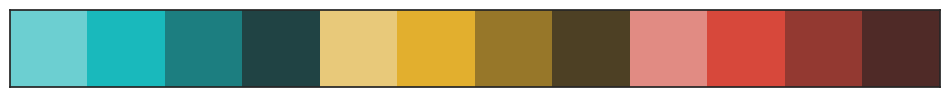

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define 3 main colors
main_colors = ['#19b9bc', '#e2af2e', '#d7483b']  # Blue, Green, Orange

# Create a palette with 4 shades for each main color, from light to dark with more contrast
palette = []

for color in main_colors:
    # Generate both light and dark palettes for more contrast
    light_shades = sns.light_palette(color, n_colors=6)[3:4]  # Skip the first color to avoid white
    light_shades1 = sns.light_palette(color, n_colors=6)[5:6]  # Skip the first color to avoid white
    dark_shades = sns.dark_palette(color, n_colors=6)[3:4]  # Reverse the order of dark shades    
    dark_shades1 = sns.dark_palette(color, n_colors=6)[1:2]  # Reverse the order of dark shades    
    # Combine the shades to get a better contrast (light + dark)
    palette += light_shades + light_shades1 + dark_shades+ dark_shades1

# Display the palette
sns.palplot(palette)
plt.show()


## Fig 1 - Plot brains

### Map and mask plot

In [164]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_erosion, binary_fill_holes
import glob

# Define paths
wm_path = '/mnt/inage/Aurelie-A0342481/aurelie/ResUnet_outputs/WM/'
wmh_path = '/mnt/inage/Aurelie-A0342481/aurelie/ResUnet_outputs/WMH/'
csf_path = '/mnt/inage/Aurelie-A0342481/abussy/Freesurfer/'
root_path = '//mnt/inage/Aurelie-A0342481/aurelie/Diffusion/radtract_from_CPU_selected/'

# Path for brain mask
brain_mask_path = '/mnt/inage/Aurelie-A0342481/abussy/BIANCA/MPM/'

# Function to load NIfTI data
def load_nifti_data(file_path):
    try:
        return nib.load(file_path).get_fdata()
    except Exception as e:
        print(f"Error loading NIfTI file {file_path}: {e}")
        return None

# Load the brain mask for a given subject
def load_brain_mask(subject_id):
    brain_mask_file = glob.glob(os.path.join(brain_mask_path, subject_id, '**', '*MT_c2_c3_mask.nii.gz'), recursive=True)
    if brain_mask_file:
        brain_mask = nib.load(brain_mask_file[0]).get_fdata()
        return brain_mask
    else:
        print(f"Brain mask not found for subject {subject_id}")
        return None

# Apply the brain mask to the given data
def apply_brain_mask(data, brain_mask):
    return data * brain_mask if brain_mask is not None else data

# Function to apply a mask and return the result
def apply_mask(data, mask):
    if data is not None and mask is not None:
        return data * mask
    return data

# Function to process a subject
def process_subject(pr, pr_short):
    subject_data = {}

    # File paths
    wm_file_path = os.path.join(wm_path, f'WM_resunet_{pr_short}.nii.gz')
    wmh_file_path = os.path.join(wmh_path, f'WMH_resunet_{pr_short}.nii.gz')
    csf_file_path = os.path.join(csf_path, f'{pr}_synthseg_T1_CSF_in_MPM.nii.gz')

    # Load data
    wm_data = load_nifti_data(wm_file_path)
    wmh_data = load_nifti_data(wmh_file_path)
    csf_data = load_nifti_data(csf_file_path)

    # Save loaded data
    subject_data['WM'] = wm_data
    subject_data['WMH'] = wmh_data
    subject_data['CSF'] = csf_data

    if wm_data is not None and wmh_data is not None:
        nawm_data = np.logical_and(wm_data == 1, wmh_data == 0).astype(np.uint8)
        subject_data['NAWM'] = nawm_data
    else:
        nawm_data = None

    if wmh_data is not None:
        wmh_dilated = binary_dilation(wmh_data, iterations=1)
        wmh_inverted = np.logical_not(wmh_data).astype(np.uint8)
        layer_1 = wmh_dilated * wmh_inverted

        layers = [apply_mask(layer_1, nawm_data)] + [
            apply_mask(np.logical_xor(binary_dilation(wmh_data, iterations=i+1), binary_dilation(wmh_data, iterations=i)), nawm_data)
            for i in range(1, 5)
        ]
        subject_data['Layers'] = layers

        # Define Inner Layers
        inner_layer_1 = np.logical_xor(wmh_data, binary_erosion(wmh_data, iterations=1))
        inner_layer_2 = binary_erosion(wmh_data, iterations=1).astype(np.uint8) - binary_erosion(wmh_data, iterations=2).astype(np.uint8)
        
        subject_data['InnerLayers'] = [inner_layer_1, inner_layer_2]

        wmh_center_mask = binary_erosion(wmh_data, iterations=2)
        subject_data['WMH_center'] = wmh_center_mask

    if nawm_data is not None:
        wmh_dilated_mask = binary_dilation(wmh_data, iterations=5)
        wmh_inverted_mask = np.logical_not(wmh_dilated_mask).astype(np.uint8)
        wm_left_mask = nawm_data * wmh_inverted_mask
        subject_data['WM_left'] = wm_left_mask

    if csf_data is not None and wm_data is not None:
        csf_dilated_mask = binary_dilation(csf_data, iterations=8)
        csf_inverted_mask = np.logical_not(csf_data).astype(np.uint8)
        pvwm_mask = csf_dilated_mask * csf_inverted_mask * wm_data
        subject_data['PVWM'] = pvwm_mask

    if wm_data is not None:
        
        # Combine WM and dilated CSF masks
        combined_wm_csf = np.logical_or(wm_data, csf_dilated_mask).astype(np.uint8)

        # Fill holes in the combined WM and CSF mask
        combined_filled = binary_fill_holes(combined_wm_csf).astype(np.uint8)

        # Erode the filled combined mask
        combined_eroded = binary_erosion(combined_filled, iterations=2)

        # Define SWM mask
        swm_mask = combined_filled * np.logical_not(combined_eroded).astype(np.uint8)

        subject_data['SWM'] = swm_mask

    if all(mask in subject_data for mask in ['WM', 'PVWM', 'SWM', 'CSF']):
        dwm_mask = wm_data * np.logical_not(subject_data['PVWM']) * np.logical_not(subject_data['SWM']) * np.logical_not(csf_data).astype(np.uint8)
        subject_data['DWM'] = dwm_mask

    if 'WMH' in subject_data:
        subject_data['WMH_DWM'] = np.logical_and(subject_data['WMH'], subject_data.get('DWM', 0)).astype(np.uint8)
        subject_data['WMH_SWM'] = np.logical_and(subject_data['WMH'], subject_data.get('SWM', 0)).astype(np.uint8)
        subject_data['WMH_PVWM'] = np.logical_and(subject_data['WMH'], subject_data.get('PVWM', 0)).astype(np.uint8)

    if 'NAWM' in subject_data:
        subject_data['NAWM_SWM'] = nawm_data * subject_data.get('SWM', 0)
        subject_data['NAWM_DWM'] = nawm_data * subject_data.get('DWM', 0)
        subject_data['NAWM_PVWM'] = nawm_data * subject_data.get('PVWM', 0)

    return subject_data

# Load metrics (MT scan in this case)
def load_metrics(pr, data_types):
    subject_metrics = {}
    for data_type, file_pattern in data_types.items():
        metric_file_pattern = os.path.join(root_path, pr, file_pattern)
        metric_files = glob.glob(metric_file_pattern)
        
        for metric_file_path in metric_files:
            metric_data = load_nifti_data(metric_file_path)
            if metric_data is not None:
                subject_metrics[data_type] = metric_data
    return subject_metrics

# Processing for subject number 0
subject_index = 31
pr = common_PR[subject_index]
pr_short = pr[1:8]

# Process the subject and load the data
subject_data = process_subject(pr, pr_short)

# Define data types and their corresponding file patterns
data_types = {
    'MT': 's*MT.nii',
    'R1': 's*R1.nii',
    'R2*': 's*R2s_OLS.nii',
    'ISOVF': '*data_aligned_FIT_ISOVF_in_MPM.nii.gz',
    'ICVF': '*data_aligned_FIT_ICVF_in_MPM.nii.gz',
    'OD': '*data_aligned_FIT_OD_in_MPM.nii.gz',
    'FA': '*data_aligned_unwarped_FA_in_MPM.nii.gz',
    'MD': '*data_aligned_unwarped_MD_in_MPM.nii.gz',
    'g-ratio': '*MT_g_ratio.nii'
}

# Load MT scan
nifti_outputs = load_metrics(pr, data_types)


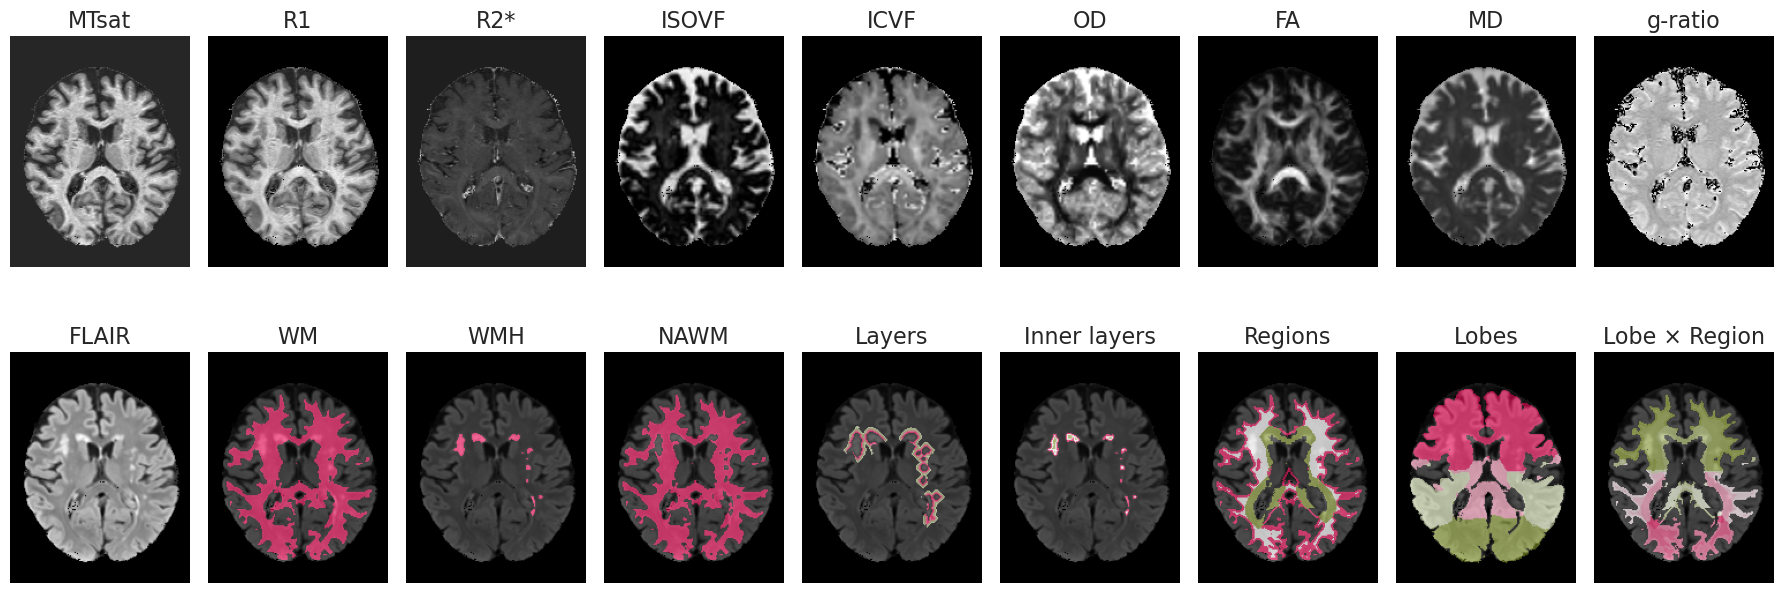

In [165]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import label
import seaborn as sns

def apply_brain_mask(data_slice, brain_mask_slice):
    """Apply brain mask to the given data slice."""
    return data_slice * brain_mask_slice

# Function to load the data (MT, R1, R2*, ISOVF, etc.)
def load_data(subject_id, data_type):
    data_file = glob.glob(os.path.join(brain_mask_path, subject_id, data_type), recursive=True)
    if data_file:
        return nib.load(data_file[0]).get_fdata()
    else:
        print(f"{data_type} data not found for subject {subject_id}")
        return None

def crop_slice(data, left_margin=10, right_margin=10, top_margin=20, bottom_margin=20):
    """Crop the slice to remove padding around the brain."""
    return data[top_margin:-bottom_margin, left_margin:-right_margin]

# Load the FLAIR data for the given subject
def load_flair_data(pr):
    flair_file = glob.glob(os.path.join(flair_path, pr, 'sanlm_ms*in_MPRAGE_masked_in_MPM.nii.gz*'), recursive=True)
    if flair_file:
        return nib.load(flair_file[0]).get_fdata()
    else:
        print(f"FLAIR data not found for subject {pr}")
        return None

# Function to replace 0s with white background (255 for RGB)
def make_background_white(image):
    # Replace all zero values with 255 (white) for RGB
    image[image == 0] = 255
    return image

# Load the brain mask for the given subject
def load_brain_mask(pr):
    brain_mask_file = glob.glob(os.path.join(brain_mask_path, pr, '*MT_c2_c3_mask.nii.gz'), recursive=True)
    if brain_mask_file:
        return nib.load(brain_mask_file[0]).get_fdata()
    else:
        print(f"Brain mask not found for subject {pr}")
        return None

# Load the masks from the paths
def load_masks(mask_paths):
    masks = {}
    for mask_name, mask_path in mask_paths.items():
        if os.path.exists(mask_path):  # Check if the mask file exists
            masks[mask_name] = nib.load(mask_path).get_fdata()  # Load the mask using nibabel
        else:
            print(f"Mask not found for {mask_name} at {mask_path}")
            masks[mask_name] = None  # Add None if the mask is not found
    return masks


# Example paths for MT and brain mask
output_dir = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/WMH_analyses/mask_visualizations' 
flair_path='/mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/'
brain_mask_path = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/MPM/'  # Example path for brain mask
pr = 'sPR05814_RS250141'  # Replace with the actual subject ID
pr = 'sPR06046_EV200438'  # Replace with the actual subject ID

# Define the mask paths
mask_paths = {
    'WM': f'{output_dir}/{pr}_WM_mask.nii',
    'WMH': f'{output_dir}/{pr}_WMH_mask.nii',
    'NAWM': f'{output_dir}/{pr}_NAWM_mask.nii',
    'SWM': f'{output_dir}/{pr}_SWM_mask.nii',
    'DWM': f'{output_dir}/{pr}_DWM_mask.nii',
    'PVWM': f'{output_dir}/{pr}_PVWM_mask.nii',
    'frontal': f'{output_dir}/{pr}_frontal_mask.nii',
    'parietal': f'{output_dir}/{pr}_parietal_mask.nii',
    'temporal': f'{output_dir}/{pr}_temporal_mask.nii',
    'occipital': f'{output_dir}/{pr}_occipital_mask.nii',
    'Layer_1': f'{output_dir}/{pr}_Layer_1_mask.nii',
    'Layer_2': f'{output_dir}/{pr}_Layer_2_mask.nii',
    'Layer_3': f'{output_dir}/{pr}_Layer_3_mask.nii',
    'Layer_4': f'{output_dir}/{pr}_Layer_4_mask.nii',
    'Layer_5': f'{output_dir}/{pr}_Layer_5_mask.nii',
    'InnerLayer_1': f'{output_dir}/{pr}_InnerLayer_1_mask.nii',
    'InnerLayer_2': f'{output_dir}/{pr}_InnerLayer_2_mask.nii',
    'WMH_center': f'{output_dir}/{pr}_WMH_center_mask.nii',
    'WM_left': f'{output_dir}/{pr}_WM_left_mask.nii'
}

# Load the masks
masks = load_masks(mask_paths)
flair_data = load_flair_data(pr)
# Load MT and brain mask data
data_types = {
    'MTsat': 's*MT.nii',
    'R1': 's*R1_masked.nii.gz',
    'R2*': 's*R2s_OLS_masked.nii.gz',
    'ISOVF': '*data_aligned_FIT_ISOVF_in_MPM.nii.gz',
    'ICVF': '*data_aligned_FIT_ICVF_in_MPM.nii.gz',
    'OD': '*data_aligned_FIT_OD_in_MPM.nii.gz',
    'FA': '*data_aligned_unwarped_FA_in_MPM.nii.gz',
    'MD': '*data_aligned_unwarped_MD_in_MPM.nii.gz',
    'g-ratio': '*MT_g_ratio.nii'
}

mt_data = load_data(pr, 's*MT.nii')
flair_data = load_flair_data(pr)
brain_mask = load_brain_mask(pr)

# Create the viridis colormap
colormap = sns.color_palette("inferno", as_cmap=True)
diverging_cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

colormap=diverging_cmap

# Sample it at 256 points
n_colors = 100
colors = [colormap(i / n_colors) for i in range(n_colors)]


# Check if all data is loaded correctly
if mt_data is None or brain_mask is None or not all(mask is not None for mask in masks.values()):
    print("Error: One or more data files are missing.")
else:
    # Specify the slice index to visualize
    slice_index_coronal = 175  # Adjust this slice index as needed
    slice_index_coronal = 172  # Adjust this slice index as needed

    # Extract the coronal slice for MT data and apply the brain mask
    coronal_slice_mt_o = apply_brain_mask(mt_data[:, slice_index_coronal, :], brain_mask[:, slice_index_coronal, :])
    coronal_slice_mt = crop_slice(coronal_slice_mt_o)
    coronal_slice_flair_o = apply_brain_mask(flair_data[:, slice_index_coronal, :], brain_mask[:, slice_index_coronal, :])
    coronal_slice_flair = crop_slice(coronal_slice_flair_o)

    # Create the figure for the MT slice and overlays
    fig, axes = plt.subplots(2, 9, figsize=(18, 7))  # 2 rows, 9 columns (first row for metrics, second for masks)

    # Plot the 9 metrics in the first row
    for idx, (metric, data_type) in enumerate(data_types.items()):
        # Load the data for the current data type
        data = load_data(pr, data_type)
        
        if data is not None:
            # Extract the coronal slice and apply the brain mask
            data_slice = apply_brain_mask(data[:, slice_index_coronal, :], brain_mask[:, slice_index_coronal, :])

            axes[0, idx].imshow(crop_slice(data_slice), cmap='gray')
            axes[0, idx].set_title(f'{metric}', fontsize=16)
            axes[0, idx].axis('off')

    # Plot the masks in the second row
    # Plot the FLAIR slice on the first column
    axes[1, 0].imshow(coronal_slice_flair, cmap='gray')
    axes[1, 0].set_title('FLAIR', fontsize=16)
    axes[1, 0].axis('off')

    # Overlay the WM mask
    overlay_wm = np.zeros(coronal_slice_mt_o.shape + (3,))  # RGB channels
    overlay_wm[masks['WM'][:, slice_index_coronal, :] == 1] = colors[99][:3] # First color in viridis for WM mask
    overlay_wm=crop_slice(overlay_wm)
    axes[1, 1].imshow(coronal_slice_flair, cmap='gray')
    axes[1, 1].imshow(overlay_wm, alpha=0.6)
    axes[1, 1].set_title('WM', fontsize=16)
    axes[1, 1].axis('off')

    # Overlay the WMH mask
    overlay_wmh = np.zeros(coronal_slice_mt_o.shape + (3,))  # RGB channels
    overlay_wmh[masks['WMH'][:, slice_index_coronal, :] == 1] = colors[99][:3] # Color for WMH mask
    overlay_wmh=crop_slice(overlay_wmh)
    axes[1, 2].imshow(coronal_slice_flair, cmap='gray')
    axes[1, 2].imshow(overlay_wmh, alpha=0.6)
    axes[1, 2].set_title('WMH', fontsize=16)
    axes[1, 2].axis('off')

    # Overlay the NAWM mask
    overlay_nawm = np.zeros(coronal_slice_mt_o.shape + (3,))  # RGB channels
    overlay_nawm[masks['NAWM'][:, slice_index_coronal, :] == 1] = colors[99][:3] # Color for NAWM mask
    overlay_nawm=crop_slice(overlay_nawm)
    axes[1, 3].imshow(coronal_slice_flair, cmap='gray')
    axes[1, 3].imshow(overlay_nawm, alpha=0.6)
    axes[1, 3].set_title('NAWM', fontsize=16)
    axes[1, 3].axis('off')

    # Overlay the Layer masks on the seventh column
    overlay_layers = np.zeros(coronal_slice_mt_o.shape + (3,))  # RGB channels
    overlay_layers[masks['Layer_1'][:, slice_index_coronal, :] == 1] = colors[99][:3]  # Layer 1 color
    overlay_layers[masks['Layer_2'][:, slice_index_coronal, :] == 1] = colors[79][:3]  # Layer 2 color
    overlay_layers[masks['Layer_3'][:, slice_index_coronal, :] == 1] = colors[59][:3]  # Layer 3 color
    overlay_layers[masks['Layer_4'][:, slice_index_coronal, :] == 1] = colors[39][:3]  # Layer 4 color
    overlay_layers[masks['Layer_5'][:, slice_index_coronal, :] == 1] = colors[19][:3]  # Layer 5 color
    overlay_layers=crop_slice(overlay_layers)
    axes[1,4].imshow(coronal_slice_flair, cmap='gray')
    axes[1,4].imshow(overlay_layers, alpha=0.6)  # Overlay with transparency
    axes[1,4].set_title('Layers', fontsize=16)
    axes[1,4].axis('off')

    # Overlay the Inner and WMH Center layers on the eighth column
    overlay_inner_wmh = np.zeros(coronal_slice_mt_o.shape + (3,))  # RGB channels
    overlay_inner_wmh[masks['InnerLayer_1'][:, slice_index_coronal, :] == 1] = colors[99][:3] # InnerLayer_1
    overlay_inner_wmh[masks['InnerLayer_2'][:, slice_index_coronal, :] == 1] = colors[50][:3]  # InnerLayer_2
    overlay_inner_wmh[masks['WMH_center'][:, slice_index_coronal, :] == 1] = colors[10][:3]  # WMH_center
    overlay_inner_wmh=crop_slice(overlay_inner_wmh)
    axes[1,5].imshow(coronal_slice_flair, cmap='gray')
    axes[1,5].imshow(overlay_inner_wmh, alpha=0.6)  # Overlay with transparency
    axes[1,5].set_title('Inner layers', fontsize=16)
    axes[1,5].axis('off')

    # Overlay the Regions (SWM/DWM/PVWM) mask on the fifth column
    overlay_regions = np.zeros(coronal_slice_mt_o.shape + (3,))  # RGB channels
    overlay_regions[masks['SWM'][:, slice_index_coronal, :] == 1] = colors[99][:3] # SWM color
    overlay_regions[masks['DWM'][:, slice_index_coronal, :] == 1] = colors[50][:3]  # DWM color
    overlay_regions[masks['PVWM'][:, slice_index_coronal, :] == 1] = colors[10][:3]  # PVWM color
    overlay_regions=crop_slice(overlay_regions)
    axes[1,6].imshow(coronal_slice_flair, cmap='gray')
    axes[1,6].imshow(overlay_regions, alpha=0.6)  # Overlay with transparency
    axes[1,6].set_title('Regions', fontsize=16)
    axes[1,6].axis('off')

    # Overlay the Lobes mask on the sixth column
    overlay_lobes = np.zeros(coronal_slice_mt_o.shape + (3,))  # RGB channels
    overlay_lobes[masks['frontal'][:, slice_index_coronal, :] == 1] = colors[99][:3] # Frontal lobe color
    overlay_lobes[masks['parietal'][:, slice_index_coronal, :] == 1] = colors[69][:3] # Parietal lobe color
    overlay_lobes[masks['temporal'][:, slice_index_coronal, :] == 1] = colors[39][:3] # Temporal lobe color
    overlay_lobes[masks['occipital'][:, slice_index_coronal, :] == 1] = colors[10][:3]  # Occipital lobe color
    overlay_lobes=crop_slice(overlay_lobes)
    axes[1,7].imshow(coronal_slice_flair, cmap='gray')
    axes[1,7].imshow(overlay_lobes, alpha=0.6)  # Overlay with transparency
    axes[1,7].set_title('Lobes', fontsize=16)
    axes[1,7].axis('off')

    lobes   = ['frontal', 'parietal', 'temporal', 'occipital']
    regions = ['SWM', 'DWM', 'PVWM']

    # Build all 12 pairs
    pairs = [(lob, reg) for lob in lobes for reg in regions]

    # Pick 12 evenly spaced colors from the existing 'colors' list (derived from your 'colormap')
    idxs = np.linspace(5, 95, num=len(pairs)).astype(int)
    pair_cols = [colors[i][:3] for i in idxs]  # strip alpha, keep RGB

    # Create overlay (same shape as the metric slice)
    overlay_lr = np.zeros(coronal_slice_mt_o.shape + (3,), dtype=float)

    # Fill each intersection with its color
    for (lob, reg), col in zip(pairs, pair_cols):
        lob_slice = (masks[lob][:, slice_index_coronal, :] > 0.5)
        reg_slice = (masks[reg][:, slice_index_coronal, :] > 0.5)
        inter = lob_slice & reg_slice
        overlay_lr[inter] = col  # assign RGB

    # Crop after coloring
    overlay_lr = crop_slice(overlay_lr)

    # Show on the last panel (axes[1,8])
    axes[1,8].imshow(coronal_slice_flair, cmap='gray')
    axes[1,8].imshow(overlay_lr, alpha=0.6)
    axes[1,8].set_title('Lobe × Region', fontsize=16)
    axes[1,8].axis('off')
    # Adjust layout and show the figure
    plt.tight_layout()
    plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
        'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })
    plot_path = os.path.join(notebook_dir, f'Figures_new/Maps_and_masks.png')
    plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Maps_and_masks.svg')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)     
    plt.show()


### Fazekas examples

In [13]:
# Fazekas category to representative PR substring
fazekas_pr_map = {
    '0': 'PR05785',
    '1': 'PR05754',
    '2': 'PR05731',
    '3': 'PR05714',
    '4': 'PR05739',
    '5': 'PR05736',
    '6': 'PR05740'
}

# Dictionary to store outputs per Fazekas category
fazekas_nifti_outputs = {}

# Loop over Fazekas categories and find matching full PR
for fazekas_cat, pr_short in fazekas_pr_map.items():
    matching_prs = [pr for pr in common_PR if pr_short in pr]

    if matching_prs:
        pr_full = matching_prs[0]  # Use the first match found
        pr_short_clean = pr_short[0:8]

        print(f"\n# Processing Fazekas {fazekas_cat} with PR {pr_full}")

        # Optional: process subject
        subject_data = process_subject(pr_full, pr_short_clean)

        # Load metrics
        nifti_outputs = load_metrics(pr_full, data_types)

        # Store
        fazekas_nifti_outputs[fazekas_cat] = nifti_outputs
    else:
        print(f"\n⚠️ No match found for PR {pr_short} in common_PR for Fazekas {fazekas_cat}")



# Processing Fazekas 0 with PR sPR05785_SH140764

# Processing Fazekas 1 with PR sPR05754_RL020246

# Processing Fazekas 2 with PR sPR05731_PB200451

# Processing Fazekas 3 with PR sPR05714_NP091046

# Processing Fazekas 4 with PR sPR05739_HO200936

# Processing Fazekas 5 with PR sPR05736_IT120841

# Processing Fazekas 6 with PR sPR05740_RV030345


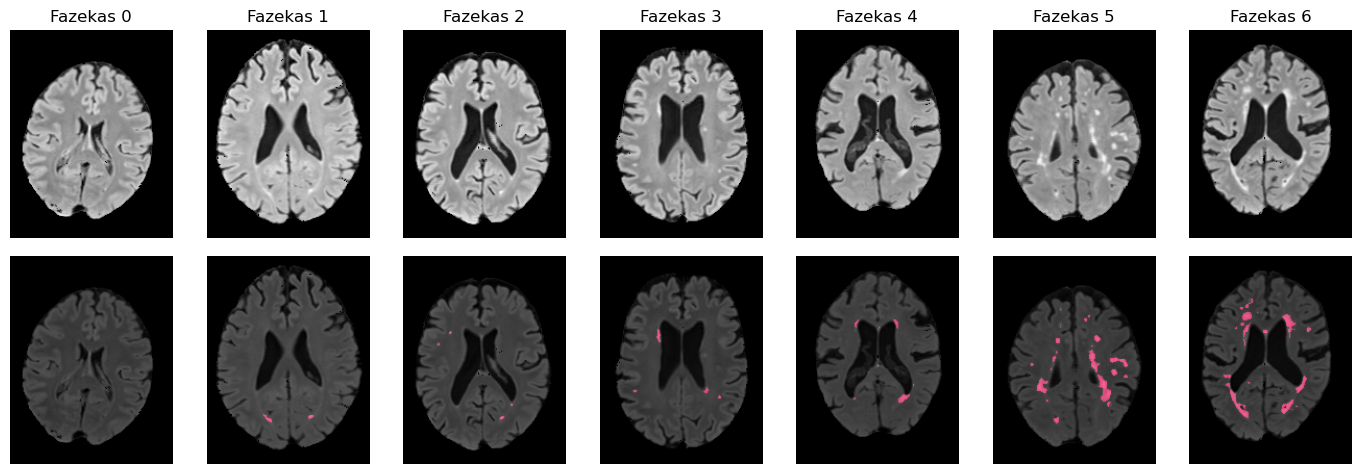

In [14]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import seaborn as sns

# === SETTINGS ===
slice_index_coronal = 175
flair_path = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/'
brain_mask_path = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/MPM/'  # Example path for brain mask

save_path = 'Figures_new/flair_wmh_grid_by_fazekas.png'
colormap = diverging_cmap

# === Load FLAIR function ===
def load_flair_data(pr):
    flair_file = glob.glob(os.path.join(flair_path, pr, 'sanlm_ms*in_MPRAGE_masked_in_MPM.nii.gz*'), recursive=True)
    if flair_file:
        return nib.load(flair_file[0]).get_fdata()
    else:
        print(f"❌ FLAIR not found for {pr}")
        return None

# === Load WMH function ===
def load_wmh_mask(pr):
    wmh_files = glob.glob(os.path.join(flair_path, pr, '*cleaned.nii.gz*'), recursive=True)
    if wmh_files:
        return nib.load(wmh_files[0]).get_fdata()
    else:
        print(f"❌ WMH mask not found for {pr}")
        return None


def load_brain_mask(pr):
    brain_mask_file = glob.glob(os.path.join(brain_mask_path, pr, '**', '*MT_c2_c3_mask.nii.gz'), recursive=True)
    if brain_mask_file:
        brain_mask = nib.load(brain_mask_file[0]).get_fdata()
        return brain_mask
    else:
        print(f"Brain mask not found for subject {subject_id}")
        return None

def crop_slice(data, left_margin=10, right_margin=10, top_margin=20, bottom_margin=20):
    """Crop the slice to remove padding around the brain."""
    return data[top_margin:-bottom_margin, left_margin:-right_margin]

# === FAZEKAS → PR map ===
fazekas_pr_map = {
    '0': 'PR05785',
    '1': 'PR05754',
    '2': 'PR05731',
    '3': 'PR05719',
    '4': 'PR05753',
    '5': 'PR05736',
    '6': 'PR05740'
}

fazekas_slice_map = {
    '0': 180,
    '1': 162,
    '2': 180,
    '3': 178,
    '4': 180,
    '5': 193,
    '6': 178
}

# === Resolve full PRs from common_PR ===
fazekas_full_prs = {}
for fazekas_cat, pr_short in fazekas_pr_map.items():
    matching = [pr for pr in common_PR if pr_short in pr]
    if matching:
        fazekas_full_prs[fazekas_cat] = matching[0]
    else:
        print(f"⚠️ No match found for PR {pr_short}")

# === Create the figure grid ===
fig, axes = plt.subplots(2, 7, figsize=(14, 5))

for col, (fazekas_cat, pr_full) in enumerate(fazekas_full_prs.items()):
    pr_short = fazekas_pr_map[fazekas_cat]
    # Load data
    flair_data = load_flair_data(pr_full)
    wmh_mask = load_wmh_mask(pr_full)
    brain_mask = load_brain_mask(pr_full)
    
    if flair_data is None or wmh_mask is None:
        continue

    slice_index_coronal=list(fazekas_slice_map.values())[int(fazekas_cat)]
    
    # Extract coronal slices
    coronal_slice_flair_o = apply_brain_mask(flair_data[:, slice_index_coronal, :], brain_mask[:, slice_index_coronal, :])
    coronal_slice_flair = crop_slice(coronal_slice_flair_o)
    

    # Plot FLAIR (top row)
    axes[0, col].imshow(coronal_slice_flair, cmap='gray')
    axes[0, col].set_title(f'Fazekas {fazekas_cat}', fontsize=12)
    axes[0, col].axis('off')

    # Overlay the WMH mask
    overlay_wmh = np.zeros(coronal_slice_flair_o.shape + (3,))  # RGB channels
    overlay_wmh[wmh_mask[:, slice_index_coronal, :] == 1] = colors[99][:3] # Color for WMH mask
    overlay_wmh=crop_slice(overlay_wmh)
    axes[1, col].imshow(coronal_slice_flair, cmap='gray')
    axes[1, col].imshow(overlay_wmh, alpha=0.6)
    axes[1, col].set_title(None, fontsize=16)
    axes[1, col].axis('off')

# Final labels
axes[0, 0].set_ylabel('FLAIR', fontsize=16)
axes[1, 0].set_ylabel('FLAIR + WMH', fontsize=16)

plt.tight_layout()
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })
plot_path = os.path.join(notebook_dir, f'Figures_new/Fazekas_brains.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Fazekas_brains.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()


## Fig 2 - Fingerprint WMH vs NAWM

### Create region function to extract values

In [15]:
def create_region_df(region_name):
    """
    Function to create a DataFrame for a specific region like 'WMH_frontal', 'WMH_parietal', etc.
    
    Parameters:
    region_name (str): The region name (e.g., 'WMH_frontal', 'WMH_temporal')
    
    Returns:
    pd.DataFrame: DataFrame containing the data for the region
    """
    # Assume this structure:
    # combined_mean_metrics_data_cross_sectionnal[metric][region_name][subject_id] = [value]
    all_metrics = list(combined_mean_metrics_data_cross_sectionnal.keys())

    # Collect data per PR
    data_per_pr = {}

    for metric in all_metrics:
        # Access the data for the specific region name
        metric_data = combined_mean_metrics_data_cross_sectionnal[metric].get(region_name, {})
        
        for pr, values in metric_data.items():
            
            if pr not in data_per_pr:
                data_per_pr[pr] = {}
            data_per_pr[pr][metric] = values[0] if values else None

    # Convert to DataFrame
    region_df = pd.DataFrame.from_dict(data_per_pr, orient='index')
    region_df.index.name = 'PR'
    region_df.reset_index(inplace=True)

    return region_df

### Fingerprint WMH and NAWM per region

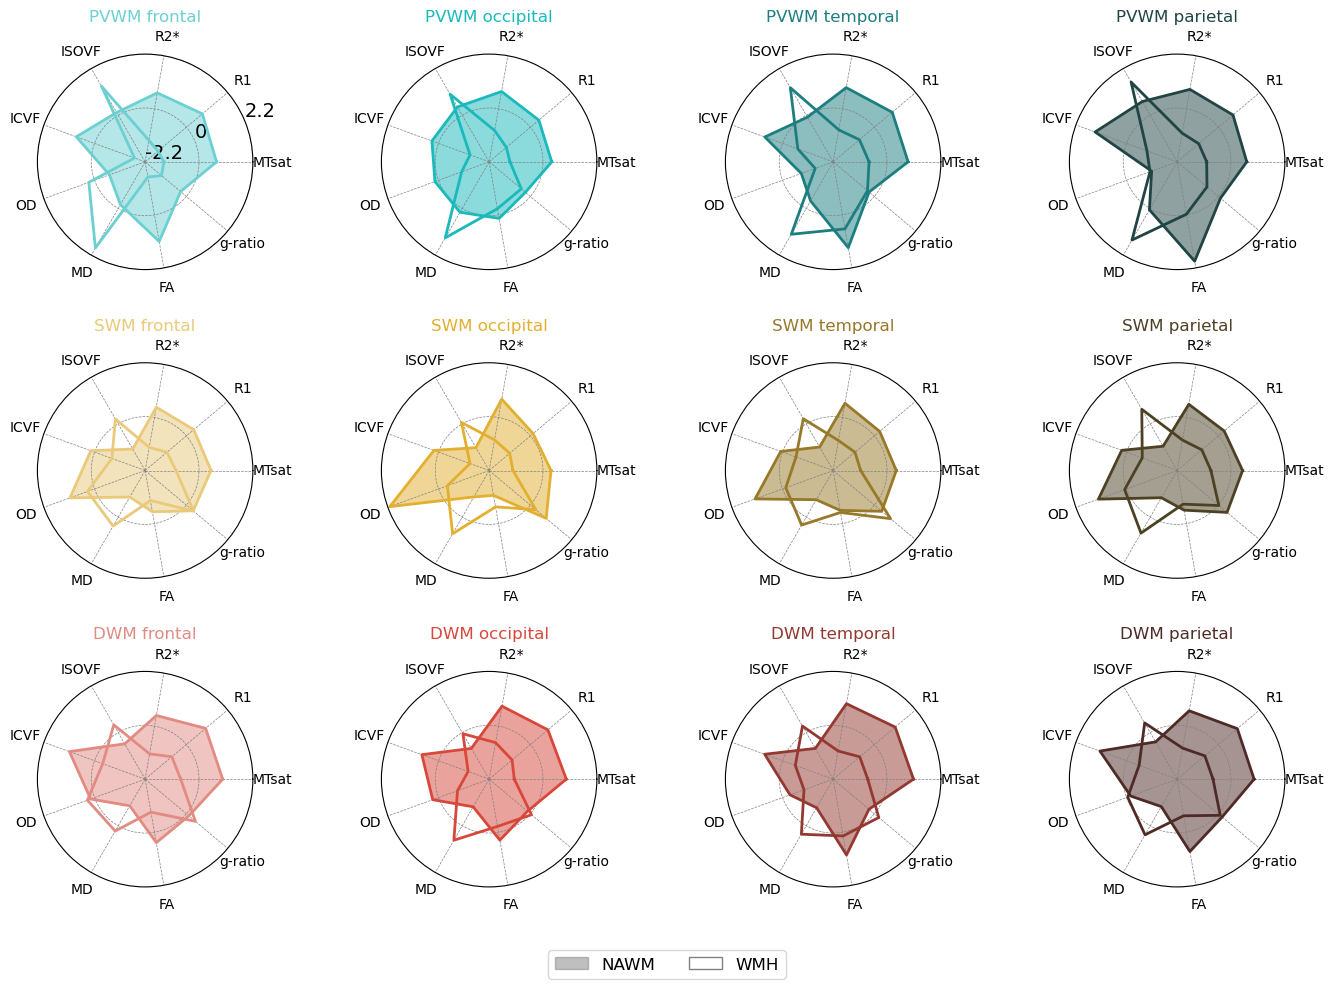

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# === Parameters ===
nawm_regions = [
    'NAWM_PVWM_frontal', 'NAWM_PVWM_occipital', 'NAWM_PVWM_temporal', 'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal', 'NAWM_SWM_occipital', 'NAWM_SWM_temporal', 'NAWM_SWM_parietal',
    'NAWM_DWM_frontal', 'NAWM_DWM_occipital', 'NAWM_DWM_temporal', 'NAWM_DWM_parietal',
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal', 'WMH_SWM_occipital', 'WMH_SWM_temporal', 'WMH_SWM_parietal',
    'WMH_DWM_frontal', 'WMH_DWM_occipital', 'WMH_DWM_temporal', 'WMH_DWM_parietal'
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# === Build full matrix ===
rows = []
for region in nawm_regions:
    region_df = create_region_df(region)
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics})
    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"⚠️ Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

# === Remove rows with any NaN in metrics ===
df_full = pd.concat(rows, ignore_index=True)

# Assuming df_full and final_matched_rows are available
df_full = df_full[df_full['PR'].isin(final_matched_rows['PR'])]

# List of metrics (MT, R1, etc.)
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

df_full['BaseRegion'] = df_full['Region'].str.replace('WMH_', '', regex=False)
df_full['BaseRegion'] = df_full['BaseRegion'].str.replace('NAWM_', '', regex=False)

# Extract WMH_NAWM, TissueType, and Lobe from the 'Region' column
df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0])  # Extract NAWM or WMH
df_full['TissueType'] = df_full['Region'].apply(lambda x: x.split('_')[1])  # Extract PVWM, DWM, SWM
df_full['Lobe'] = df_full['Region'].apply(lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown')  # Extract Lobe

# 1. Standardize the metrics across all lesions (all data)
# Standardize all lesions (across the entire dataset)
df_full_std = df_full.copy() 
df_full_std[metrics] = df_full[metrics].apply(lambda x: (x - x.mean()) / x.std(), axis=0)

# 2. Retain PR and BaseRegion columns as well
df_full_std['PR'] = df_full['PR']
df_full_std['BaseRegion'] = df_full['BaseRegion']
df_full_std['WMH_NAWM'] = df_full['WMH_NAWM']


# 2. Calculate the maximum absolute value of the mean metrics across all regions
max_abs_value = 2.2 

# 5. Number of metrics
num_metrics = len(metrics)

# 6. Create a radial grid for the plot
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # To close the circle

# 7. Set up the plotting for each BaseRegion
base_regions = df_full_std['BaseRegion'].unique()  # List of BaseRegions

# 8. Set up the plot grid (4 columns, 3 rows)
rows = 3
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(14, 10), dpi=100, subplot_kw=dict(polar=True))

# Flatten axes to easily index them
axes = axes.flatten()

# Filter data for this region
df_full_std_WMH = df_full_std[df_full_std['WMH_NAWM'] == 'WMH']
df_full_std_NAWM = df_full_std[df_full_std['WMH_NAWM'] == 'NAWM']

# Loop through each BaseRegion and plot the radial plot
for i, region in enumerate(base_regions):
    ax = axes[i]  # Get the current subplot axis
    
    # Filter data for this region
    df_full_std_WMH_region = df_full_std_WMH[df_full_std_WMH['BaseRegion'] == region]
    df_full_std_NAWM_region = df_full_std_NAWM[df_full_std_NAWM['BaseRegion'] == region]
    
    # Calculate the mean of the standardized metrics for each group in this region
    df_full_std_WMH_region = df_full_std_WMH_region[metrics].mean()
    df_full_std_NAWM_region = df_full_std_NAWM_region[metrics].mean()

    # Get color from the palette for this region
    region_color = palette[i]

    # Plot the radial fingerprint for WMH (white fill and colored edge) in this region
    ax.plot(angles, np.concatenate((df_full_std_WMH_region.values, [df_full_std_WMH_region.values[0]])), 
            color=region_color, linewidth=2, label="WMH")
    ax.fill(angles, np.concatenate((df_full_std_WMH_region.values, [df_full_std_WMH_region.values[0]])), 
            color='white', alpha=0.5)  # WMH has a white fill

    # Plot the radial fingerprint for NAWM (colored fill and edge) in this region
    ax.plot(angles, np.concatenate((df_full_std_NAWM_region.values, [df_full_std_NAWM_region.values[0]])), 
            color=region_color, linewidth=2, label="NAWM")
    ax.fill(angles, np.concatenate((df_full_std_NAWM_region.values, [df_full_std_NAWM_region.values[0]])), 
            color=region_color, alpha=0.5)  # NAWM has colored fill

    # Set labels for the metrics
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([metric.replace('MT', 'MTsat') for metric in metrics], fontsize=10)
    
    # Set the title and grid for each plot
    ax.set_title(f"{region.replace('_', ' ')}", fontsize=12, color=region_color)  # Replace underscores in BaseRegion names
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
    ax.set_yticks([0])  # Customize the distance between each radial line
    ax.set_ylim(-max_abs_value, max_abs_value)

first_ax = axes[0]  # The first subplot (radar plot)
first_ax.set_yticks([-max_abs_value, 0, max_abs_value])  # Set the y-ticks to min, 0, and max values
first_ax.set_yticklabels([f'{-max_abs_value:.1f}', '0', f'{max_abs_value:.1f}'])  # Label them

# Create custom legend handles
nawm_patch = mpatches.Patch(edgecolor='gray', facecolor='gray', alpha=0.5, label='NAWM', linewidth=1)  # Solid box for NAWM
wmh_patch = mpatches.Patch(edgecolor='gray', facecolor='none', label='WMH', linewidth=1)  # Edge-only for WMH

# Add the common legend at the bottom center of the figure
fig.legend(handles=[nawm_patch, wmh_patch], loc='lower center', ncol=2, fontsize=12)

# Adjust layout to fit subplots
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 12,
    'axes.titlesize': 12, 'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
plot_path = os.path.join(notebook_dir, f'Figures_new/Metric_radarplot_by_region.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Metric_radarplot_by_region.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
# Show the plot
plt.show()



### Fingerprint effect size WMH vs NAWM per region

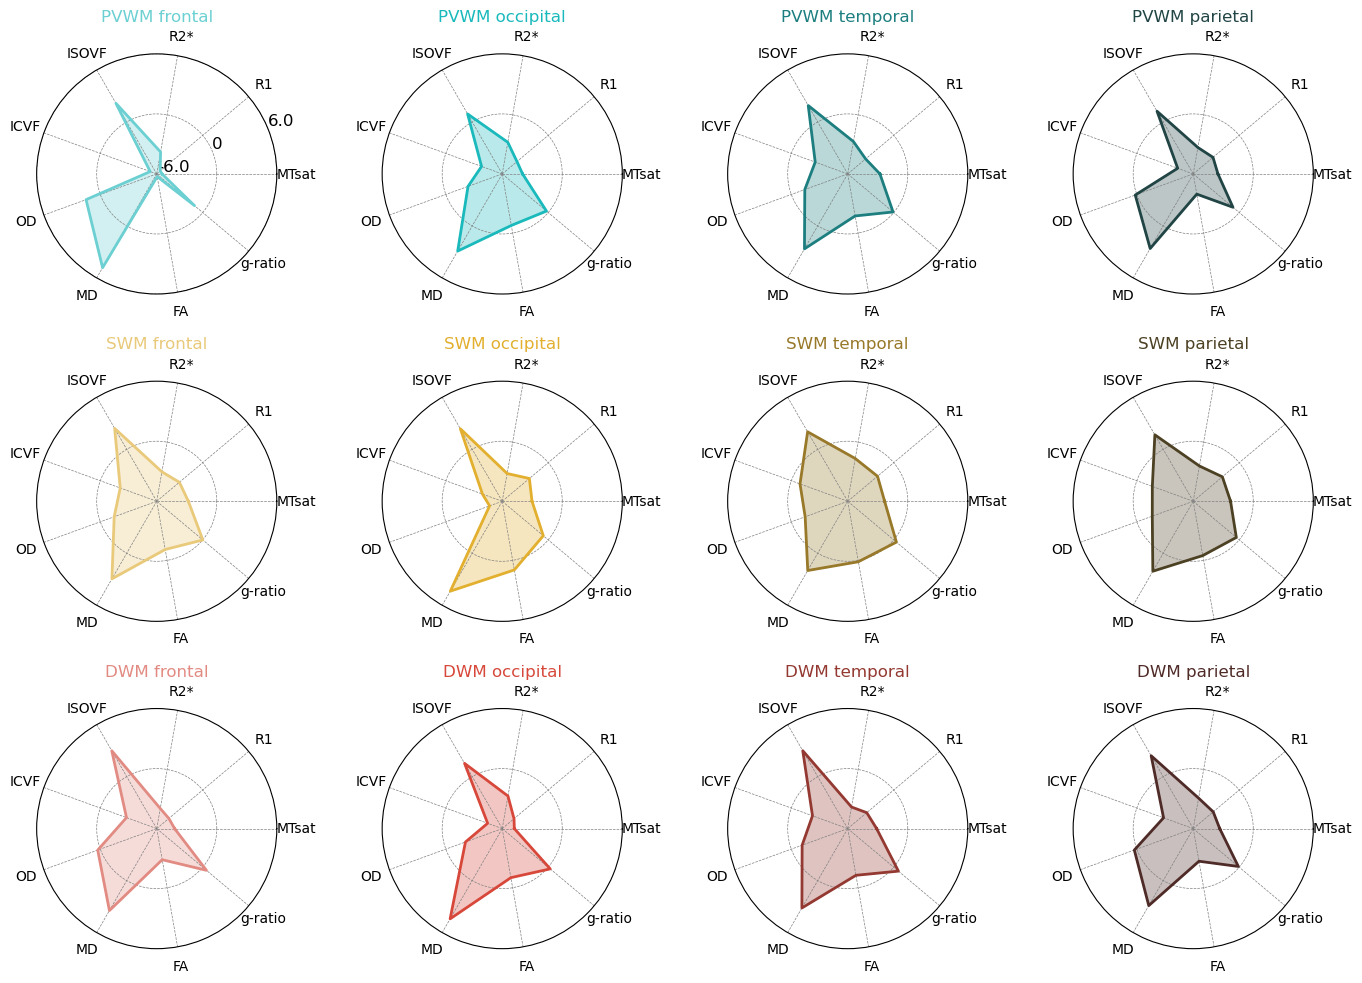

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# List of metrics (MT, R1, etc.)
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

# Assuming 'df_full' is already defined and cleaned
df_full['BaseRegion'] = df_full['Region'].str.replace('WMH_', '', regex=False)
df_full['BaseRegion'] = df_full['BaseRegion'].str.replace('NAWM_', '', regex=False)

# 1. Standardize the metrics across all lesions (all data)
df_full_std[metrics] = df_full[metrics].apply(lambda x: (x - x.mean()) / x.std(), axis=0)

# 2. Retain PR and BaseRegion columns as well
df_full_std['PR'] = df_full['PR']
df_full_std['BaseRegion'] = df_full['BaseRegion']
df_full_std['WMH_NAWM'] = df_full['WMH_NAWM']

# 3. Calculate the maximum absolute value of the mean metrics across all regions
max_abs_value = 6  # You can replace this with the calculated max value if needed

# 4. Number of metrics
num_metrics = len(metrics)

# 5. Create a radial grid for the plot
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # To close the circle

# 6. Set up the plotting for each BaseRegion
base_regions = df_full_std['BaseRegion'].unique()  # List of BaseRegions

# 7. Set up the plot grid (4 columns, 3 rows)
rows = 3
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(14, 10), dpi=100, subplot_kw=dict(polar=True))

# Flatten axes to easily index them
axes = axes.flatten()

# Filter data for this region
df_full_std_WMH = df_full_std[df_full_std['WMH_NAWM'] == 'WMH']
df_full_std_NAWM = df_full_std[df_full_std['WMH_NAWM'] == 'NAWM']

# 8. Loop through each BaseRegion and plot the radial plot
for i, region in enumerate(base_regions):
    ax = axes[i]  # Get the current subplot axis
    
    # Filter data for this region
    df_full_std_WMH_region = df_full_std_WMH[df_full_std_WMH['BaseRegion'] == region]
    df_full_std_NAWM_region = df_full_std_NAWM[df_full_std_NAWM['BaseRegion'] == region]
    
    # 9. Calculate the mean and standard deviation of the standardized metrics for each group (WMH and NAWM)
    df_full_std_WMH_region_mean = df_full_std_WMH_region[metrics].mean()
    df_full_std_NAWM_region_mean = df_full_std_NAWM_region[metrics].mean()

    df_full_std_WMH_region_std = df_full_std_WMH_region[metrics].std()
    df_full_std_NAWM_region_std = df_full_std_NAWM_region[metrics].std()

    # Get color from the palette for this region
    region_color = palette[i]
    
    # 10. Calculate Cohen's d for each metric
    cohen_d = (df_full_std_WMH_region_mean - df_full_std_NAWM_region_mean) / \
              np.sqrt((df_full_std_WMH_region_std**2 + df_full_std_NAWM_region_std**2) / 2)

    # 11. Plot Cohen's d on the radar plot instead of (or alongside) the raw standardized metrics
    ax.plot(angles, np.concatenate((cohen_d.values, [cohen_d.values[0]])), 
            color=region_color, linewidth=2, label="Cohen's d")
    ax.fill(angles, np.concatenate((cohen_d.values, [cohen_d.values[0]])), 
            color=region_color, alpha=0.3)  # Cohen's d with a shaded fill

    # Set labels for the metrics
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([metric.replace('MT', 'MTsat') for metric in metrics], fontsize=10)
    
    # Set the title and grid for each plot
    ax.set_title(f"{region.replace('_', ' ')}", fontsize=12, color=region_color)  # Replace underscores in BaseRegion names
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
    ax.set_yticks([0])  # Customize the distance between each radial line
    ax.set_ylim(-max_abs_value, max_abs_value)

first_ax = axes[0]  # The first subplot (radar plot)
first_ax.set_yticks([-max_abs_value, 0, max_abs_value])  # Set the y-ticks to min, 0, and max values
first_ax.set_yticklabels([f'{-max_abs_value:.1f}', '0', f'{max_abs_value:.1f}'])  # Label them

# Adjust layout to fit subplots
plt.tight_layout()

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 12,
    'axes.titlesize': 12, 'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})

# Save the figure
plot_path = os.path.join(notebook_dir, f'Figures_new/Metric_radarplot_by_region_cohend.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Metric_radarplot_by_region_cohend.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)

# Show the plot
plt.show()


### Barplot effect size

/tmp/ipykernel_4021517/2475964199.py:104: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


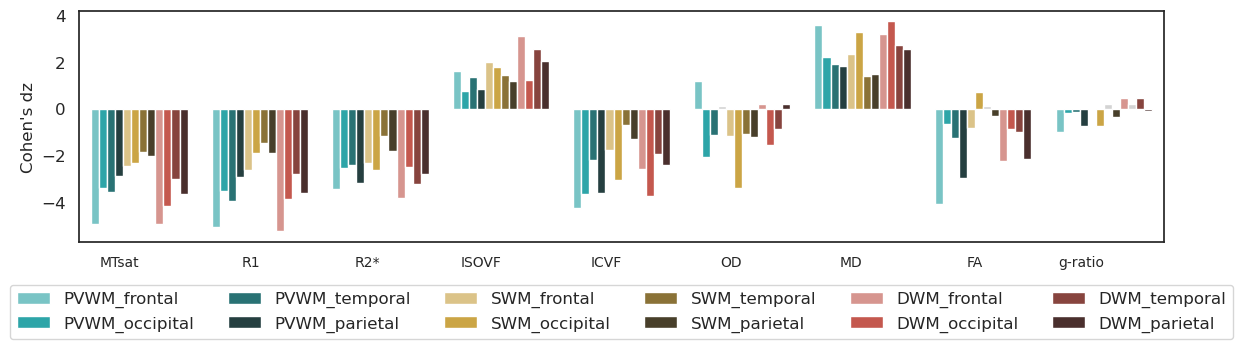

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon  # paired test
from statsmodels.stats.multitest import multipletests

# List of metrics (MT, R1, etc.)
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

# Derive BaseRegion from Region
df_full['BaseRegion'] = df_full['Region'].str.replace('WMH_', '', regex=False)
df_full['BaseRegion'] = df_full['BaseRegion'].str.replace('NAWM_', '', regex=False)

# Split by condition (kept for clarity; pairing happens below)
df_full_WMH = df_full[df_full['WMH_NAWM'] == 'WMH']
df_full_NAWM = df_full[df_full['WMH_NAWM'] == 'NAWM']

# Containers
effectsize_results = []   # stores paired Cohen's d_z
wilcoxon_results   = []   # stores Wilcoxon p-values

# Paired analysis per BaseRegion × Metric (within PR)
for region in df_full['BaseRegion'].dropna().unique():
    for metric in metrics:
        sub = df_full.loc[df_full['BaseRegion'] == region, ['PR', 'WMH_NAWM', metric]].dropna()
        if sub.empty:
            continue

        # Build PR-wise pairs: columns ['NAWM','WMH']
        wide = (sub.pivot_table(index='PR', columns='WMH_NAWM', values=metric, aggfunc='mean')
                    .reindex(columns=['NAWM', 'WMH']))
        wide = wide.dropna(subset=['NAWM', 'WMH'])
        if len(wide) < 2:
            continue

        # Paired Cohen's d_z = mean(diff) / sd(diff)
        diffs = wide['WMH'] - wide['NAWM']
        sd_diff = diffs.std(ddof=1)
        dz = diffs.mean() / sd_diff if sd_diff > 0 else np.nan

        effectsize_results.append({
            'BaseRegion': region,
            'Metric': metric,
            "Cohen's dz": dz  # keep single column for plotting
        })

        # Wilcoxon signed-rank (two-sided)
        try:
            stat, p_value = wilcoxon(wide['WMH'], wide['NAWM'], alternative='two-sided', zero_method='wilcox')
        except ValueError:
            p_value = 1.0  # e.g., all diffs exactly zero

        wilcoxon_results.append({
            'BaseRegion': region,
            'Metric': metric,
            'p_value': p_value
        })

# Wilcoxon p-values DataFrame + FDR
wilcoxon_df = pd.DataFrame(wilcoxon_results)
if not wilcoxon_df.empty:
    _, corrected_pvalues, _, _ = multipletests(wilcoxon_df['p_value'], alpha=0.05, method='fdr_bh')
    wilcoxon_df['fdr_p_value'] = corrected_pvalues
    wilcoxon_df['significance'] = wilcoxon_df['fdr_p_value'] < 0.05
else:
    wilcoxon_df['fdr_p_value'] = []
    wilcoxon_df['significance'] = []

# Effect sizes
cohen_dz_df = pd.DataFrame(effectsize_results)

# Merge significance into effect sizes
cohen_dz_df = pd.merge(
    cohen_dz_df,
    wilcoxon_df[['BaseRegion', 'Metric', 'significance']],
    on=['BaseRegion', 'Metric'],
    how='left'
)

# ---- Plot (same look; corrected y-label text) ----
plt.figure(figsize=(14, 3))
ax = sns.barplot(
    x='Metric', y="Cohen's dz",
    hue='BaseRegion',
    data=cohen_dz_df,
    palette=palette,   # assumes your palette is defined
    dodge=True,
    errorbar=None
)

# Remove horizontal line background
ax.grid(False)

# Grey non-significant bars
for p, significance in zip(ax.patches, cohen_dz_df['significance'].fillna(False)):
    if not significance:
        p.set_facecolor('lightgrey')

# Labels & legend
ax.set_xlabel(None, fontsize=12)
ax.set_ylabel("Cohen's dz", fontsize=12)  # <- updated to reflect paired effect size
ax.set_title(None, fontsize=14)
ax.set_xticklabels(
    ['MTsat' if metric == 'MT' else metric for metric in cohen_dz_df['Metric'].unique()],
    ha='right', fontsize=10
)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=6, fontsize=12)

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 12,
    'axes.titlesize': 12, 'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42
})

plot_path = os.path.join(notebook_dir, f'Figures_new/barplot_cohens_dz_wilcoxon_per_region.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/barplot_cohens_dz_wilcoxon_per_region.svg')

plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()


In [135]:
from scipy.stats import norm, rankdata

nz = diffs[diffs != 0]
n_pairs = nz.size
# Signed-rank sum (W_signed = W+ − W−)
ranks = rankdata(np.abs(nz))
signed_ranks = np.where(nz > 0, ranks, -ranks)
W_signed = signed_ranks.sum()

# Approximate Z from two-sided p (sign from W_signed)
Z = np.sign(W_signed) * norm.isf(p_value/2) if np.isfinite(p_value) and p_value>0 else 0.0
wilcoxon_r = Z / np.sqrt(n_pairs) if n_pairs > 0 else np.nan

wilcoxon_results[-1].update({'n_pairs': int(n_pairs), 'wilcoxon_r': wilcoxon_r})
effectsize_results[-1].update({'n_pairs': int(n_pairs)})

results_table = cohen_dz_df.merge(
    wilcoxon_df[['BaseRegion','Metric','p_value','fdr_p_value','n_pairs','wilcoxon_r']],
    on=['BaseRegion','Metric'], how='left'
).sort_values(['Metric','BaseRegion'])

print(results_table.rename(columns={"Cohen's dz":"Cohens_dz"})
      .round({'Cohens_dz':3,'wilcoxon_r':3,'p_value':3,'fdr_p_value':3})
      .to_string(index=False))


KeyError: "['n_pairs', 'wilcoxon_r'] not in index"

## Fig 3 - Regional descriptions + associations

### Descriptive plots; WMH vol, NAWM vol and %WMH

Number of rows before dropping NaNs: 4056
Number of rows after dropping NaNs: 3202


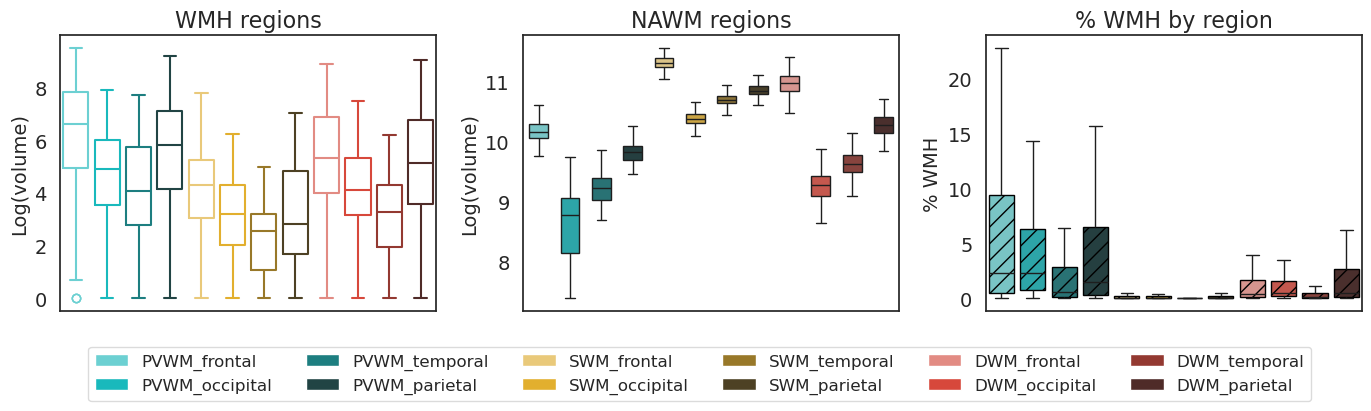

In [180]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # Import mpatches for creating custom legend handles
import os
# === Parameters ===
nawm_regions = [
    'NAWM_PVWM_frontal', 'NAWM_PVWM_occipital', 'NAWM_PVWM_temporal', 'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal', 'NAWM_SWM_occipital', 'NAWM_SWM_temporal', 'NAWM_SWM_parietal',
    'NAWM_DWM_frontal', 'NAWM_DWM_occipital', 'NAWM_DWM_temporal', 'NAWM_DWM_parietal',
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal', 'WMH_SWM_occipital', 'WMH_SWM_temporal', 'WMH_SWM_parietal',
    'WMH_DWM_frontal', 'WMH_DWM_occipital', 'WMH_DWM_temporal', 'WMH_DWM_parietal'
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# === Build full matrix ===
rows = []
for region in nawm_regions:
    region_df = create_region_df(region)
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics})
    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"⚠️ Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

# === Remove rows with any NaN in metrics ===
df_full = pd.concat(rows, ignore_index=True)

# Assuming df_full and final_matched_rows are available
df_full = df_full[df_full['PR'].isin(final_matched_rows['PR'])]

df_no_nan = df_full.dropna(subset=metrics).reset_index(drop=True)
print(f"Number of rows before dropping NaNs: {len(df_full)}")
print(f"Number of rows after dropping NaNs: {len(df_no_nan)}")

# === Standardize metrics ===
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(df_no_nan[metrics])

df_scaled = df_no_nan.copy()
df_scaled[metrics] = metrics_scaled

# === Run PCA ===
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[metrics])

df_scaled['PC1'] = pca_result[:, 0]
df_scaled['PC2'] = pca_result[:, 1]

# === Add "Type" column: PVWM / SWM / DWM ===
def extract_type(region_name):
    if 'PVWM' in region_name:
        return 'PVWM'
    elif 'SWM' in region_name:
        return 'SWM'
    elif 'DWM' in region_name:
        return 'DWM'
    else:
        return 'Other'

df_scaled['Type'] = df_scaled['Region'].apply(extract_type)

# === Prepare base region names ===
df_scaled['BaseRegion'] = df_scaled['Region'].str.replace('WMH_', '', regex=False)
df_scaled['BaseRegion'] = df_scaled['BaseRegion'].str.replace('NAWM_', '', regex=False)

# Assign color per BaseRegion
base_regions_unique = df_scaled['BaseRegion'].unique()
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(base_regions_unique)}
df_scaled['WMH_NAWM'] = df_scaled['Region'].apply(lambda x: 'WMH' if 'WMH' in x else 'NAWM')

# Assuming df_scaled contains the merged data with columns 'MT', 'Voxel_Count', and other metrics
df_scaled_voxels = pd.merge(df_voxel_counts, df_scaled, how='inner', left_on=['PR', 'Mask_Type'], right_on=['PR', 'Region'])
df_scaled_voxels_ordered = df_scaled_voxels.copy()

# Define the custom order for Mask_Type
order_regions = [
    'NAWM_PVWM_frontal', 'NAWM_PVWM_occipital', 'NAWM_PVWM_temporal', 'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal', 'NAWM_SWM_occipital', 'NAWM_SWM_temporal', 'NAWM_SWM_parietal',
    'NAWM_DWM_frontal', 'NAWM_DWM_occipital', 'NAWM_DWM_temporal', 'NAWM_DWM_parietal',
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal', 'WMH_SWM_occipital', 'WMH_SWM_temporal', 'WMH_SWM_parietal',
    'WMH_DWM_frontal', 'WMH_DWM_occipital', 'WMH_DWM_temporal', 'WMH_DWM_parietal'
]

# Reorder the 'Mask_Type' column based on the custom order
df_scaled_voxels_ordered['Mask_Type'] = pd.Categorical(df_scaled_voxels_ordered['Mask_Type'], categories=order_regions, ordered=True)
df_scaled_voxels_ordered = df_scaled_voxels_ordered.sort_values(by='Mask_Type')

# Apply log transformation to 'Voxel_Count' to calculate log volume
df_scaled_voxels_ordered['Log_Voxel_Count'] = np.log(df_scaled_voxels_ordered['Voxel_Count'])

# Split the data into NAWM and WMH for customized plotting
df_nawm = df_scaled_voxels_ordered[df_scaled_voxels_ordered['Mask_Type'].str.contains('NAWM')]
df_wmh = df_scaled_voxels_ordered[df_scaled_voxels_ordered['Mask_Type'].str.contains('WMH')]

df_scaled_voxels_NAWM = df_scaled_voxels[df_scaled_voxels['WMH_NAWM'] == 'NAWM'].copy()
df_scaled_voxels_WMH = df_scaled_voxels[df_scaled_voxels['WMH_NAWM'] == 'WMH'].copy()

# Merge df_scaled_voxels_WMH with df_scaled_voxels_NAWM based on 'PR' and 'Region'
df_scaled_voxels_NAWM_WMH = pd.merge(df_scaled_voxels_NAWM, df_scaled_voxels_WMH, how='left', on=['PR', 'BaseRegion'], suffixes=('_NAWM', '_WMH'))

# Calculate the percentage of Voxel_Count in WMH relative to NAWM
df_scaled_voxels_NAWM_WMH['Percent_WMH'] = (df_scaled_voxels_NAWM_WMH['Voxel_Count_WMH'] / (df_scaled_voxels_NAWM_WMH['Voxel_Count_WMH'] + df_scaled_voxels_NAWM_WMH['Voxel_Count_NAWM'])) * 100

base_region_order_wmh = df_wmh['BaseRegion'].unique()
df_scaled_voxels_NAWM_WMH['BaseRegion'] = pd.Categorical(df_scaled_voxels_NAWM_WMH['BaseRegion'], categories=base_region_order_wmh, ordered=True)
df_scaled_voxels_NAWM_WMH = df_scaled_voxels_NAWM_WMH.sort_values(by='BaseRegion')


# Create a color mapping for BaseRegion
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(df_scaled_voxels_ordered['BaseRegion'].unique())}

# Create subplots with separate y-axes
fig, (ax2, ax1, ax3) = plt.subplots(1, 3, figsize=(14, 3.5))

# Plotting NAWM regions on the first axis (left boxplot)
sns.boxplot(data=df_nawm, x='BaseRegion', y='Log_Voxel_Count', 
            hue='BaseRegion', palette=base_region_colors, showfliers=False, width=0.6, ax=ax1)

ax1.set_title('NAWM regions', fontsize=16)
ax1.set_xlabel(None)
ax1.set_ylabel('Log(volume)', fontsize=14)
ax1.tick_params(axis='x', rotation=90)

# Plotting WMH regions on the second axis (right boxplot)
sns.boxplot(data=df_wmh, x='BaseRegion', y='Log_Voxel_Count', 
             hue='BaseRegion', palette=base_region_colors, fill=False, ax=ax2)

ax2.set_title('WMH regions', fontsize=16)
ax2.set_xlabel(None)
ax2.set_ylabel('Log(volume)', fontsize=14)
ax2.tick_params(axis='x', rotation=90)

# Plotting WMH regions on the second axis (right boxplot)
sns.boxplot(data=df_scaled_voxels_NAWM_WMH, x='BaseRegion', y='Percent_WMH', 
            hue='BaseRegion', palette=base_region_colors, ax=ax3,
            showfliers=False)

# Customizing edgecolors for each BaseRegion
for i, patch in enumerate(ax3.patches):
    # Get the color for the corresponding BaseRegion from base_region_color_map
    region = df_scaled_voxels_NAWM_WMH['BaseRegion'].unique()[i]
    color = base_region_colors[region]
    
    # Apply the edgecolor and hatch pattern for each box
    patch.set_edgecolor('black')
    patch.set_linewidth(1)
    patch.set_hatch('//')  # Adding stripes
    
# Set labels and title
ax3.set_xlabel(None)
ax3.set_ylabel('% WMH', fontsize=14)
ax3.set_title('% WMH by region', fontsize=16)

# Remove tick labels
ax1.set_xticklabels([])  # Removes the tick labels for x-axis
ax2.set_xticklabels([])  # Removes the tick labels for x-axis
ax3.set_xticklabels([])  # Removes the tick labels for x-axis

for ax in (ax1, ax2, ax3):
    ax.grid(False)
    ax.set_axisbelow(False)
    ax.set_facecolor('white')

# Custom legend handles (remove rectangle and caption)
nawm_patch = mpatches.Patch(color='gray', label='NAWM', linewidth=1)  # Solid box for NAWM with the first color
wmh_patch = mpatches.Patch(edgecolor='gray', facecolor='none', label='WMH', linewidth=1)  # Edge-only for WMH with increased edge size
percent_patch = mpatches.Patch(facecolor='white', edgecolor='gray', label='% WMH', linewidth=1, hatch='//')

# Create a color legend on the left side
color_patches = [mpatches.Patch(facecolor=color, label=region) for region, color in base_region_colors.items()]

plt.tight_layout()
ax2.legend(handles=color_patches, loc='upper center', bbox_to_anchor=(1.7, -0.1), 
           ncol=6, frameon=True, facecolor='white', edgecolor='lightgrey', fontsize=12)


# Adjust layout to ensure there's no overlap between the legend and the boxplots
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})

# Save the plot
plot_path = os.path.join(notebook_dir, f'Figures_new/Region_volume_boxplots.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Region_volume_boxplots.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)

# Show the plot
plt.show()

# Place the custom legend for the color codes on the left side of the plot


In [185]:
from scipy.stats import wilcoxon, norm, rankdata

def region_pairwise_paired(df, value_col, subject_col='PR', region_col='BaseRegion',
                           order=None, min_pairs=2, fdr_method='fdr_bh',
                           zero_method='wilcox', use_correction=True):
    """
    Pairwise region tests using paired Wilcoxon.
    - Pairs = intersection of subjects across regions.
    - zero_method: 'wilcox' (drop zero diffs) or 'pratt' (include zeros).
    - Always uses normal approximation (mode='approx') to avoid warnings with zeros/ties.
    """
    regions = list(order) if order is not None else list(df[region_col].dropna().unique())
    results = []
    split = {r: g[[subject_col, value_col]].dropna() for r, g in df.groupby(region_col)}

    for a, b in combinations(regions, 2):
        ga = split.get(a, pd.DataFrame(columns=[subject_col, value_col]))
        gb = split.get(b, pd.DataFrame(columns=[subject_col, value_col]))
        if ga.empty or gb.empty:
            continue

        paired = pd.merge(ga, gb, on=subject_col, suffixes=('_A', '_B')).dropna()
        if paired.empty:
            continue

        xa = paired[f"{value_col}_A"].values
        xb = paired[f"{value_col}_B"].values
        diffs = xb - xa

        # Non-zero diffs used by Wilcoxon with zero_method='wilcox'
        nz_mask = diffs != 0
        n_total = diffs.size
        n_used = int(nz_mask.sum()) if zero_method == 'wilcox' else int(n_total)
        if n_used < min_pairs:
            continue

        try:
            stat, p = wilcoxon(xa, xb,
                               alternative='two-sided',
                               zero_method=zero_method,      # 'wilcox' or 'pratt'
                               correction=use_correction,    # continuity correction
                               mode='approx')                # avoid exact/tie warnings
        except ValueError:
            p = 1.0
            stat = np.nan

        # Effect sizes
        diffs_used = diffs[nz_mask] if zero_method == 'wilcox' else diffs
        sd_diff = diffs_used.std(ddof=1)
        dz = diffs_used.mean() / sd_diff if sd_diff > 0 else np.nan

        if diffs_used.size > 0:
            ranks = rankdata(np.abs(diffs_used))
            signed_ranks = np.where(diffs_used > 0, ranks, -ranks)
            W_signed = signed_ranks.sum()
            p_for_z = max(float(p), np.finfo(float).tiny)
            Z = np.sign(W_signed) * norm.isf(p_for_z / 2.0)
            r = Z / np.sqrt(n_used)
        else:
            r = np.nan

        results.append({
            'A': a, 'B': b,
            'n_pairs': int(n_total),
            'n_used': n_used,                 # non-zero pairs if 'wilcox'
            'W_stat': float(stat) if np.isfinite(stat) else np.nan,
            'p': p,
            'dz': dz,
            'r_wilcoxon': r
        })

    res_df = pd.DataFrame(results)
    if res_df.empty:
        return res_df, pd.DataFrame(index=regions, columns=regions, dtype=float)

    _, p_adj, _, _ = multipletests(res_df['p'].values, method=fdr_method)
    res_df['p_FDR'] = p_adj

    mat = pd.DataFrame(np.nan, index=regions, columns=regions, dtype=float)
    for _, row in res_df.iterrows():
        mat.loc[row['A'], row['B']] = row['p_FDR']
        mat.loc[row['B'], row['A']] = row['p_FDR']
    np.fill_diagonal(mat.values, 0.0)

    return res_df.sort_values(['A', 'B']), mat


from itertools import combinations
from scipy.stats import wilcoxon, norm, rankdata
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

# ---------- Paired Wilcoxon for region pairs ----------
def region_pairwise_paired(df, value_col, subject_col='PR', region_col='BaseRegion',
                           order=None, min_pairs=2, fdr_method='fdr_bh',
                           zero_method='wilcox', use_correction=True):
    """
    Pairwise region tests using paired Wilcoxon.
    - Pairs: subjects in intersection of two regions (by subject_col).
    - zero_method: 'wilcox' drops zero-diffs; 'pratt' includes zeros.
    - mode='approx' to handle zeros/ties without warnings.
    Returns (long_df, p_adj_matrix).
    """
    regions = list(order) if order is not None else list(df[region_col].dropna().unique())
    results = []
    split = {r: g[[subject_col, value_col]].dropna() for r, g in df.groupby(region_col)}

    for a, b in combinations(regions, 2):
        ga = split.get(a, pd.DataFrame(columns=[subject_col, value_col]))
        gb = split.get(b, pd.DataFrame(columns=[subject_col, value_col]))
        if ga.empty or gb.empty:
            continue

        paired = pd.merge(ga, gb, on=subject_col, suffixes=('_A', '_B')).dropna()
        if paired.empty:
            continue

        xa = paired[f"{value_col}_A"].values
        xb = paired[f"{value_col}_B"].values
        diffs = xb - xa

        nz_mask = (diffs != 0)
        n_total = diffs.size
        n_used  = int(nz_mask.sum()) if zero_method == 'wilcox' else int(n_total)
        if n_used < min_pairs:
            continue

        try:
            W_stat, p = wilcoxon(
                xa, xb, alternative='two-sided',
                zero_method=zero_method,      # 'wilcox' or 'pratt'
                correction=use_correction,    # continuity correction
                mode='approx'                 # avoid exact/tie warnings
            )
        except ValueError:
            W_stat, p = np.nan, 1.0

        diffs_used = diffs[nz_mask] if zero_method == 'wilcox' else diffs
        sd_diff = diffs_used.std(ddof=1)
        dz = diffs_used.mean() / sd_diff if sd_diff > 0 else np.nan

        if diffs_used.size > 0:
            ranks = rankdata(np.abs(diffs_used))
            signed_ranks = np.where(diffs_used > 0, ranks, -ranks)
            W_signed = signed_ranks.sum()
            p_for_z = max(float(p), np.finfo(float).tiny)
            Z = np.sign(W_signed) * norm.isf(p_for_z / 2.0)
            r = Z / np.sqrt(n_used)
        else:
            r = np.nan

        results.append({
            'A': a, 'B': b,
            'n_pairs': int(n_total),
            'n_used': n_used,
            'W_stat': float(W_stat) if np.isfinite(W_stat) else np.nan,
            'p': p,
            'dz': dz,
            'r_wilcoxon': r
        })

    res_df = pd.DataFrame(results)
    if res_df.empty:
        return res_df, pd.DataFrame(index=regions, columns=regions, dtype=float)

    _, p_adj, _, _ = multipletests(res_df['p'].values, method=fdr_method)
    res_df['p_FDR'] = p_adj

    mat = pd.DataFrame(np.nan, index=regions, columns=regions, dtype=float)
    for _, row in res_df.iterrows():
        mat.loc[row['A'], row['B']] = row['p_FDR']
        mat.loc[row['B'], row['A']] = row['p_FDR']
    np.fill_diagonal(mat.values, 0.0)
    return res_df.sort_values(['A','B']), mat

# ---------- Orders (reuse your plotting order if present) ----------
order_nawm = list(df_nawm['BaseRegion'].cat.categories) if hasattr(df_nawm['BaseRegion'], 'cat') else list(df_nawm['BaseRegion'].unique())
order_wmh  = list(df_wmh['BaseRegion'].cat.categories)  if hasattr(df_wmh['BaseRegion'],  'cat') else list(df_wmh['BaseRegion'].unique())
order_pct  = list(df_scaled_voxels_NAWM_WMH['BaseRegion'].cat.categories) if hasattr(df_scaled_voxels_NAWM_WMH['BaseRegion'],'cat') else list(df_scaled_voxels_NAWM_WMH['BaseRegion'].unique())

# ---------- Run paired Wilcoxon for the three families ----------
pw_wmh_long, pw_wmh_mat = region_pairwise_paired(
    df_wmh, value_col='Log_Voxel_Count',
    subject_col='PR', region_col='BaseRegion',
    order=order_wmh,
    zero_method='wilcox',  # classic Wilcoxon: drop zero diffs
    use_correction=True
)
print("\n--- WMH: pairwise Wilcoxon (paired) with FDR ---")
if not pw_wmh_long.empty:
    print(pw_wmh_long[['A','B','n_pairs','n_used','W_stat','p','p_FDR','dz','r_wilcoxon']]
          .round({'p':4,'p_FDR':4,'dz':3,'r_wilcoxon':3})
          .to_string(index=False))
else:
    print("(no valid paired region comparisons)")

pw_nawm_long, pw_nawm_mat = region_pairwise_paired(
    df_nawm, value_col='Log_Voxel_Count',
    subject_col='PR', region_col='BaseRegion',
    order=order_nawm,
    zero_method='wilcox',
    use_correction=True
)
print("\n--- NAWM: pairwise Wilcoxon (paired) with FDR ---")
if not pw_nawm_long.empty:
    print(pw_nawm_long[['A','B','n_pairs','n_used','W_stat','p','p_FDR','dz','r_wilcoxon']]
          .round({'p':4,'p_FDR':4,'dz':3,'r_wilcoxon':3})
          .to_string(index=False))
else:
    print("(no valid paired region comparisons)")

pw_pct_long, pw_pct_mat = region_pairwise_paired(
    df_scaled_voxels_NAWM_WMH, value_col='Percent_WMH',
    subject_col='PR', region_col='BaseRegion',
    order=order_pct,
    zero_method='wilcox',
    use_correction=True
)
print("\n--- %WMH: pairwise Wilcoxon (paired) with FDR ---")
if not pw_pct_long.empty:
    print(pw_pct_long[['A','B','n_pairs','n_used','W_stat','p','p_FDR','dz','r_wilcoxon']]
          .round({'p':4,'p_FDR':4,'dz':3,'r_wilcoxon':3})
          .to_string(index=False))
else:
    print("(no valid paired region comparisons)")

# ---------- Summary of main differences ----------
alpha = 0.05

def _sig_pairs(df):
    if df is None or df.empty or 'p_FDR' not in df.columns:
        return set()
    tmp = df.copy()
    tmp['pair_key'] = tmp.apply(lambda r: ' vs '.join(sorted([str(r['A']), str(r['B'])])), axis=1)
    return set(tmp.loc[tmp['p_FDR'] < alpha, 'pair_key'])

sig_WMH  = _sig_pairs(pw_wmh_long)
sig_NAWM = _sig_pairs(pw_nawm_long)
sig_PCT  = _sig_pairs(pw_pct_long)

def _print_list(title, items):
    print(f"\n{title}")
    if not items:
        print("  (none)")
    else:
        for s in sorted(items):
            print("  -", s)

_print_list("Significant pairs (FDR < 0.05) — WMH log-volume",  sig_WMH)
_print_list("Significant pairs (FDR < 0.05) — NAWM log-volume", sig_NAWM)
_print_list("Significant pairs (FDR < 0.05) — %WMH",            sig_PCT)

# Overlaps & exceptions (esp. WMH vs %WMH)
both_WMH_PCT = sig_WMH & sig_PCT
wmh_only = sig_WMH - sig_PCT
pct_only = sig_PCT - sig_WMH

_print_list("Pairs significant in BOTH WMH and %WMH", both_WMH_PCT)
_print_list("EXCEPTIONS — Significant in WMH but NOT in %WMH", wmh_only)
_print_list("EXCEPTIONS — Significant in %WMH but NOT in WMH", pct_only)

# Optional: build a compact merged table of FDR p and effect sizes per pair
def _compact(df, label):
    if df is None or df.empty: 
        return pd.DataFrame(columns=['pair_key', f'p_FDR_{label}', f'dz_{label}', f'r_{label}', f'n_pairs_{label}', f'n_used_{label}'])
    x = df.copy()
    x['pair_key'] = x.apply(lambda r: ' vs '.join(sorted([str(r['A']), str(r['B'])])), axis=1)
    return x[['pair_key','p_FDR','dz','r_wilcoxon','n_pairs','n_used']].drop_duplicates('pair_key') \
            .rename(columns={'p_FDR':f'p_FDR_{label}','dz':f'dz_{label}','r_wilcoxon':f'r_{label}',
                             'n_pairs':f'n_pairs_{label}','n_used':f'n_used_{label}'})

summary_pairs = _compact(pw_wmh_long, 'WMH') \
    .merge(_compact(pw_nawm_long, 'NAWM'), on='pair_key', how='outer') \
    .merge(_compact(pw_pct_long, 'Pct'),  on='pair_key', how='outer')

print("\n=== Pairwise summary table (FDR p, effect sizes) ===")
if not summary_pairs.empty:
    print(summary_pairs
          .sort_values('pair_key')
          .round({c:3 for c in summary_pairs.columns if c.startswith(('p_FDR','dz','r_'))})
          .to_string(index=False))
else:
    print("(no pairs to summarize)")



--- WMH: pairwise Wilcoxon (paired) with FDR ---
             A              B  n_pairs  n_used  W_stat      p  p_FDR     dz  r_wilcoxon
   DWM_frontal  DWM_occipital       88      88   481.5 0.0000 0.0000 -0.825      -0.655
   DWM_frontal   DWM_parietal      118     118  2345.0 0.0018 0.0020 -0.280      -0.288
   DWM_frontal   DWM_temporal       64      63     3.0 0.0000 0.0000 -2.061      -0.866
 DWM_occipital   DWM_parietal       86      86   620.0 0.0000 0.0000  0.679       0.580
 DWM_occipital   DWM_temporal       54      54   358.0 0.0009 0.0011 -0.463      -0.450
  DWM_temporal   DWM_parietal       63      63     8.0 0.0000 0.0000  2.074       0.862
  PVWM_frontal    DWM_frontal      128     127  1064.0 0.0000 0.0000 -0.790      -0.640
  PVWM_frontal  DWM_occipital       96      96   254.0 0.0000 0.0000 -1.265      -0.773
  PVWM_frontal   DWM_parietal      120     120   783.5 0.0000 0.0000 -0.816      -0.680
  PVWM_frontal   DWM_temporal       64      64     0.0 0.0000 0.0000 -

### Compute mean %WMH per region

In [36]:
# Compute mean Percent_WMH per BaseRegion
mean_percent_wmh = (
    df_scaled_voxels_NAWM_WMH
    .groupby('BaseRegion')['Percent_WMH']
    .mean()
    .sort_values()
)

# Print nicely
print("🔹 Mean Percent WMH per region:")
for region, val in mean_percent_wmh.items():
    print(f"   {region}: {val:.2f}%")


🔹 Mean Percent WMH per region:
   SWM_temporal: 0.05%
   SWM_parietal: 0.18%
   SWM_occipital: 0.20%
   SWM_frontal: 0.25%
   DWM_temporal: 0.43%
   DWM_occipital: 1.38%
   DWM_frontal: 1.45%
   PVWM_temporal: 2.11%
   DWM_parietal: 2.60%
   PVWM_parietal: 4.66%
   PVWM_occipital: 4.68%
   PVWM_frontal: 5.21%


### Calculate mean log WMH and NAMW per region

In [39]:
# Compute mean and SD of Log_Voxel_Count per region
wmh_log_vol_stats = (
    df_wmh
    .groupby('BaseRegion')['Log_Voxel_Count']
    .agg(['mean', 'std'])
    .sort_values('mean')
)

# Print the results
print("🔹 Mean and SD of WMH log(volume) per region:")
for region, row in wmh_log_vol_stats.iterrows():
    print(f"   {region}: mean = {row['mean']:.3f}, SD = {row['std']:.3f}")

# Compute mean and SD of Log_Voxel_Count per region
wmh_log_vol_stats = (
    df_nawm
    .groupby('BaseRegion')['Log_Voxel_Count']
    .agg(['mean', 'std'])
    .sort_values('mean')
)

# Print the results
print("🔹 Mean and SD of WMH log(volume) per region:")
for region, row in wmh_log_vol_stats.iterrows():
    print(f"   {region}: mean = {row['mean']:.3f}, SD = {row['std']:.3f}")


🔹 Mean and SD of WMH log(volume) per region:
   SWM_temporal: mean = 2.186, SD = 1.380
   DWM_temporal: mean = 2.919, SD = 1.694
   SWM_parietal: mean = 2.973, SD = 1.860
   SWM_occipital: mean = 3.131, SD = 1.640
   DWM_occipital: mean = 3.977, SD = 1.668
   SWM_frontal: mean = 4.014, SD = 1.787
   PVWM_temporal: mean = 4.054, SD = 1.900
   PVWM_occipital: mean = 4.599, SD = 1.824
   DWM_parietal: mean = 4.870, SD = 2.141
   DWM_frontal: mean = 5.114, SD = 2.080
   PVWM_parietal: mean = 5.494, SD = 2.019
   PVWM_frontal: mean = 6.041, SD = 2.149
🔹 Mean and SD of WMH log(volume) per region:
   PVWM_occipital: mean = 8.640, SD = 0.539
   PVWM_temporal: mean = 9.228, SD = 0.254
   DWM_occipital: mean = 9.260, SD = 0.266
   DWM_temporal: mean = 9.629, SD = 0.230
   PVWM_parietal: mean = 9.824, SD = 0.170
   PVWM_frontal: mean = 10.182, SD = 0.185
   DWM_parietal: mean = 10.282, SD = 0.203
   SWM_occipital: mean = 10.385, SD = 0.116
   SWM_temporal: mean = 10.708, SD = 0.108
   SWM_parieta

### Plot WMH and NAWM metrics vs WMH vol

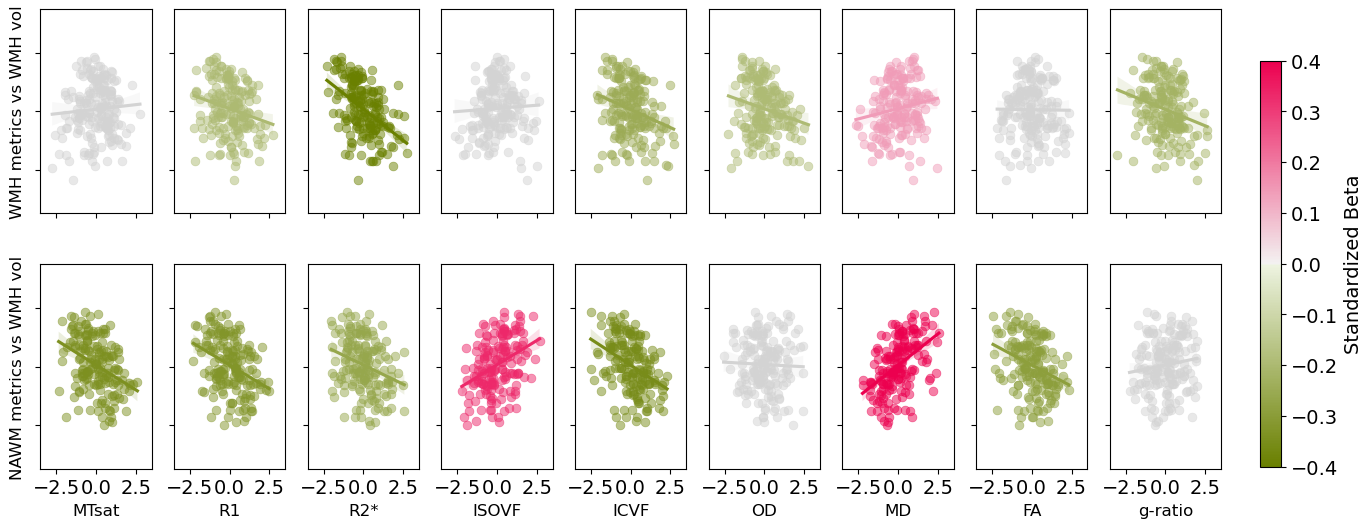

In [42]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import zscore

# =========================
# Expected in memory:
# - create_region_df(region: str) -> DataFrame with columns 'PR' and 'Mean_Metrics_In_*'
# - final_matched_rows (with column 'PR')
# - df_voxel_counts with columns: ['PR','Mask_Type','Voxel_Count'] where Mask_Type in {'WMH','NAWM'}
# =========================

# --------- Config (ORDER, LAYOUT, COLORS) ---------
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_display = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
regions_order = ['WMH', 'NAWM']   # rows: top WMH, bottom NAWM

# Fixed diverging colormap centered at 0 with fixed range [-0.4, 0.4]
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
fixed_norm = mcolors.Normalize(vmin=-0.4, vmax=0.4)

# --------- 0) Build base matrix (raw, unscaled) ---------
rows = []
for region in ['NAWM', 'WMH']:
    df_r = create_region_df(region).copy()
    df_r.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics}, inplace=True)
    df_r['Region'] = region
    present = [c for c in metrics if c in df_r.columns]
    missing = sorted(set(metrics) - set(present))
    if missing:
        print(f"⚠️ Missing metrics in {region}: {missing}")
    rows.append(df_r[['PR', 'Region'] + present])

df_all = pd.concat(rows, ignore_index=True)
df_all = df_all[df_all['PR'].isin(final_matched_rows['PR'])].copy()
present_metrics = [c for c in metrics if c in df_all.columns]
df_all = df_all.dropna(subset=present_metrics).reset_index(drop=True)

# --------- 1) Add WMH voxel counts (for z-log volume) ---------
wmh_counts_only = (
    df_voxel_counts.loc[df_voxel_counts['Mask_Type'] == 'WMH', ['PR', 'Voxel_Count']]
    .groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'WMH_Voxel_Count'})
)
df_all = pd.merge(df_all, wmh_counts_only, on='PR', how='inner')
# Guard against non-positive counts before log
df_all['WMH_Voxel_Count'] = df_all['WMH_Voxel_Count'].clip(lower=1)
df_all['Log_Voxel_Count'] = np.log(df_all['WMH_Voxel_Count'])

# Precompute z-Log volume per region (used for WMH y and outlier detection for WMH row)
df_all['zLogVol'] = df_all.groupby('Region')['Log_Voxel_Count'] \
                          .transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else np.nan))

# --------- 1b) Compute Percent WMH per PR: WMH / (WMH+NAWM) * 100 ---------
total_counts = (
    df_voxel_counts.groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'Total_Voxel_Count'})
)
wmh_counts = (
    df_voxel_counts[df_voxel_counts['Mask_Type'] == 'WMH']
    .groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'WMH_Voxel_Count_forPct'})
)

pct = pd.merge(total_counts, wmh_counts, on='PR', how='left')
pct['WMH_Voxel_Count_forPct'] = pct['WMH_Voxel_Count_forPct'].fillna(0)
# Avoid division by zero
pct['Pct_WMH'] = np.where(
    pct['Total_Voxel_Count'] > 0,
    100.0 * pct['WMH_Voxel_Count_forPct'] / pct['Total_Voxel_Count'],
    np.nan
)

# Log-transform percent (convert to proportion first; clip to avoid log(0))
pct['LogPct_WMH'] = np.log(
    np.clip(pct['Pct_WMH'] / 100.0, 1e-6, 1.0)
)

# Merge %WMH to df_all and z-score across PRs (used for NAWM y and its outliers)
df_all = pd.merge(df_all, pct[['PR', 'Pct_WMH', 'LogPct_WMH']], on='PR', how='left')

# Z-score raw percent
df_all['zPct_WMH'] = (df_all['Pct_WMH'] - df_all['Pct_WMH'].mean()) / (df_all['Pct_WMH'].std() if df_all['Pct_WMH'].std() > 0 else np.nan)

# Z-score log-percent
df_all['zLogPct_WMH'] = (df_all['LogPct_WMH'] - df_all['LogPct_WMH'].mean()) / (df_all['LogPct_WMH'].std() if df_all['LogPct_WMH'].std() > 0 else np.nan)

# --------- 2) Per-(region, metric) outlier removal + regression ---------
betas = {r: {} for r in regions_order}
pvals  = {r: {} for r in regions_order}
data_cache = {r: {} for r in regions_order}  # (x_std_for_plot, y_z_for_plot)

for region in regions_order:
    sub = df_all.loc[df_all['Region'] == region].copy()

    # Choose y differently for WMH vs NAWM
    if region == 'WMH':
        y_raw = sub['zLogVol'].to_numpy(dtype=float)
    else:  # NAWM row uses z-scored Pct_WMH
        y_raw = sub['zLogVol'].to_numpy(dtype=float)
    # Outliers in y by region (same for all metrics within region)
    y_non_out = np.isfinite(y_raw) & (np.abs(y_raw) < 2.5)

    for metric in metrics:
        if metric not in sub.columns:
            betas[region][metric] = np.nan
            pvals[region][metric]  = np.nan
            data_cache[region][metric] = (np.array([]), np.array([]))
            continue

        x_raw = sub[metric].to_numpy(dtype=float)

        # Per-metric outliers within region (z within region)
        x_mu = np.nanmean(x_raw)
        x_sd = np.nanstd(x_raw)
        xz = (x_raw - x_mu) / (x_sd if x_sd > 0 else np.nan)
        x_non_out = np.isfinite(xz) & (np.abs(xz) < 2.5)

        # Combine masks
        keep = y_non_out & x_non_out & np.isfinite(x_raw)
        x_kept = x_raw[keep]
        y_kept = y_raw[keep]

        if x_kept.size < 5:
            betas[region][metric] = np.nan
            pvals[region][metric]  = np.nan
            data_cache[region][metric] = (x_kept, y_kept)
            continue

        # Standardize metric on the NON-outlier subset (for comparable β)
        mu = np.mean(x_kept)
        sd = np.std(x_kept, ddof=0)
        if not np.isfinite(sd) or sd == 0:
            betas[region][metric] = np.nan
            pvals[region][metric]  = np.nan
            data_cache[region][metric] = (np.zeros_like(x_kept), y_kept)
            continue

        x_std = (x_kept - mu) / sd

        # OLS: y (z-LogVol for WMH; z-%WMH for NAWM) ~ standardized metric (with intercept)
        X = sm.add_constant(x_std)
        res = sm.OLS(y_kept, X).fit()

        betas[region][metric] = float(res.params[1])
        pvals[region][metric]  = float(res.pvalues[1])
        data_cache[region][metric] = (x_std, y_kept)

# --------- 3) FDR across both rows × all metrics ---------
p_WMH = [pvals['WMH'].get(m, np.nan) for m in metrics]
p_NAWM = [pvals['NAWM'].get(m, np.nan) for m in metrics]
all_p = np.array(p_WMH + p_NAWM, dtype=float)

if np.isfinite(all_p).any():
    p_for_fdr = np.where(np.isfinite(all_p), all_p, 1.0)
    _, p_fdr_all, _, _ = multipletests(p_for_fdr, method='fdr_bh')
else:
    p_fdr_all = np.full_like(all_p, np.nan, dtype=float)

p_fdr_WMH  = p_fdr_all[:len(metrics)]
p_fdr_NAWM = p_fdr_all[len(metrics):]

# --------- 4) Plot with the layout/style ---------
fig, axes = plt.subplots(2, len(metrics), figsize=(14, 5.8), sharex=True, sharey=True)

for j, metric in enumerate(metrics):
    # ---------- WMH (row 0): metric vs z-log WMH volume ----------
    ax = axes[0, j]
    x, y = data_cache['WMH'][metric]
    beta = betas['WMH'].get(metric, np.nan)
    pfdr = p_fdr_WMH[j] if j < len(p_fdr_WMH) else np.nan
    color = cmap(fixed_norm(beta)) if (np.isfinite(beta) and np.isfinite(pfdr) and pfdr < 0.05) else 'lightgray'

    if x.size > 0:
        sns.scatterplot(x=x, y=y, ax=ax, color=color, s=40, alpha=0.5, edgecolor=None)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, line_kws={'color': color})

    if j == 0:
        ax.set_ylabel('WMH metrics vs WMH vol', fontsize=12)
    else:
        ax.set_ylabel('')
    ax.set_xlabel(metrics_display[j], fontsize=12)
    ax.set_title(None)

    # ---------- NAWM (row 1): metric vs z-%WMH ----------
    ax = axes[1, j]
    x, y = data_cache['NAWM'][metric]
    beta = betas['NAWM'].get(metric, np.nan)
    pfdr = p_fdr_NAWM[j] if j < len(p_fdr_NAWM) else np.nan
    color = cmap(fixed_norm(beta)) if (np.isfinite(beta) and np.isfinite(pfdr) and pfdr < 0.05) else 'lightgray'

    if x.size > 0:
        sns.scatterplot(x=x, y=y, ax=ax, color=color, s=40, alpha=0.5, edgecolor=None)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, line_kws={'color': color})

    if j == 0:
        ax.set_ylabel('NAWM metrics vs WMH vol', fontsize=12)
    else:
        ax.set_ylabel('')
    ax.set_xlabel(metrics_display[j], fontsize=12)
    ax.set_title(None)

# Shared axis ranges & cosmetics
for ax in axes.flatten():
    ax.set_xlim([-3.5, 3.5])  # x = standardized metric (per (region,metric), non-outlier)
    ax.set_ylim([-3.5, 3.5])  # y = z-Log WMH volume (row 0) or z-%WMH (row 1)
    ax.grid(False)

# Remove y-axis labels/ticks for all but the first column
for i in range(2):
    for j in range(1, len(metrics)):
        axes[i, j].set_ylabel('')
        axes[i, j].set_yticklabels([])

# --- Reserve right margin and place colorbar there ---
plt.tight_layout(rect=[0.02, 0.02, 0.92, 0.98])   # shrink plotting area to 92% width

sm_map = plt.cm.ScalarMappable(cmap=cmap, norm=fixed_norm)
sm_map.set_array([])

# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(sm_map, cax=cbar_ax, orientation='vertical', label='Standardized Beta')

# Spacing tweaks
plt.subplots_adjust(wspace=0.2, hspace=0.25)

# Font & save settings
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42
})

# Optional save (guard if notebook_dir not defined)
try:
    plot_dir = os.path.join(notebook_dir, 'Figures_new')
    os.makedirs(plot_dir, exist_ok=True)
    plot_path = os.path.join(plot_dir, 'WMH_volume_vs_metric.png')
    plot_path_svg = os.path.join(plot_dir, 'WMH_volume_vs_metric.svg')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
except NameError:
    pass  # notebook_dir not defined; skip saving

plt.show()


### Plot WMH and NAWM metrics vs WMH or %WMH

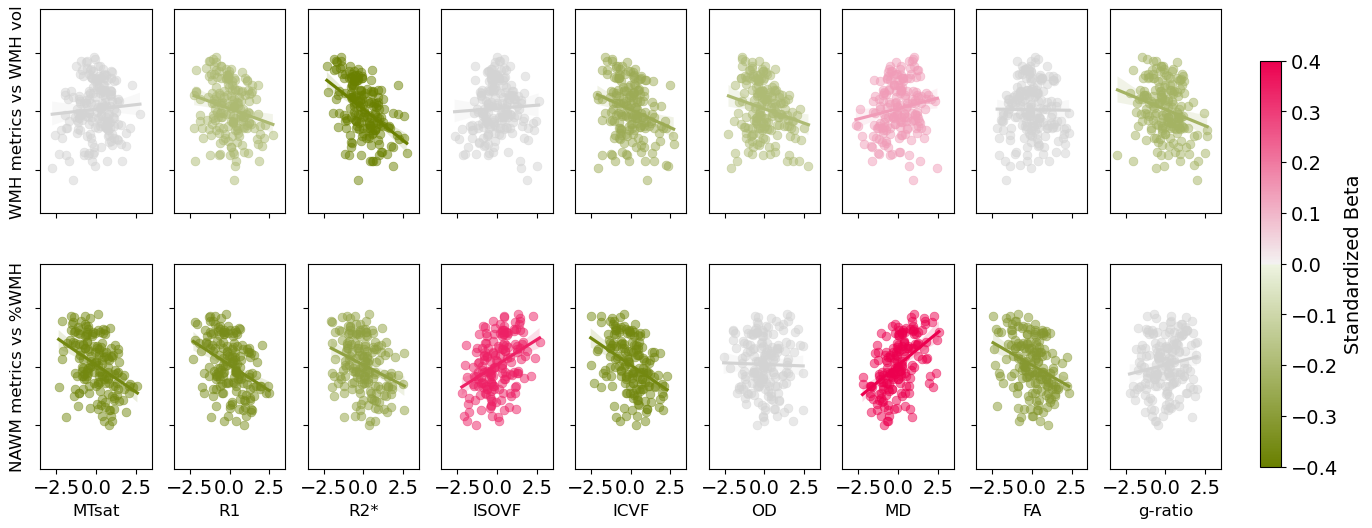

In [41]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import zscore

# =========================
# Expected in memory:
# - create_region_df(region: str) -> DataFrame with columns 'PR' and 'Mean_Metrics_In_*'
# - final_matched_rows (with column 'PR')
# - df_voxel_counts with columns: ['PR','Mask_Type','Voxel_Count'] where Mask_Type in {'WMH','NAWM'}
# =========================

# --------- Config (ORDER, LAYOUT, COLORS) ---------
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_display = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
regions_order = ['WMH', 'NAWM']   # rows: top WMH, bottom NAWM

# Fixed diverging colormap centered at 0 with fixed range [-0.4, 0.4]
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
fixed_norm = mcolors.Normalize(vmin=-0.4, vmax=0.4)

# --------- 0) Build base matrix (raw, unscaled) ---------
rows = []
for region in ['NAWM', 'WMH']:
    df_r = create_region_df(region).copy()
    df_r.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics}, inplace=True)
    df_r['Region'] = region
    present = [c for c in metrics if c in df_r.columns]
    missing = sorted(set(metrics) - set(present))
    if missing:
        print(f"⚠️ Missing metrics in {region}: {missing}")
    rows.append(df_r[['PR', 'Region'] + present])

df_all = pd.concat(rows, ignore_index=True)
df_all = df_all[df_all['PR'].isin(final_matched_rows['PR'])].copy()
present_metrics = [c for c in metrics if c in df_all.columns]
df_all = df_all.dropna(subset=present_metrics).reset_index(drop=True)

# --------- 1) Add WMH voxel counts (for z-log volume) ---------
wmh_counts_only = (
    df_voxel_counts.loc[df_voxel_counts['Mask_Type'] == 'WMH', ['PR', 'Voxel_Count']]
    .groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'WMH_Voxel_Count'})
)
df_all = pd.merge(df_all, wmh_counts_only, on='PR', how='inner')
# Guard against non-positive counts before log
df_all['WMH_Voxel_Count'] = df_all['WMH_Voxel_Count'].clip(lower=1)
df_all['Log_Voxel_Count'] = np.log(df_all['WMH_Voxel_Count'])

# Precompute z-Log volume per region (used for WMH y and outlier detection for WMH row)
df_all['zLogVol'] = df_all.groupby('Region')['Log_Voxel_Count'] \
                          .transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else np.nan))

# --------- 1b) Compute Percent WMH per PR: WMH / (WMH+NAWM) * 100 ---------
total_counts = (
    df_voxel_counts.groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'Total_Voxel_Count'})
)
wmh_counts = (
    df_voxel_counts[df_voxel_counts['Mask_Type'] == 'WMH']
    .groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'WMH_Voxel_Count_forPct'})
)

pct = pd.merge(total_counts, wmh_counts, on='PR', how='left')
pct['WMH_Voxel_Count_forPct'] = pct['WMH_Voxel_Count_forPct'].fillna(0)
# Avoid division by zero
pct['Pct_WMH'] = np.where(
    pct['Total_Voxel_Count'] > 0,
    100.0 * pct['WMH_Voxel_Count_forPct'] / pct['Total_Voxel_Count'],
    np.nan
)

# Log-transform percent (convert to proportion first; clip to avoid log(0))
pct['LogPct_WMH'] = np.log(
    np.clip(pct['Pct_WMH'] / 100.0, 1e-6, 1.0)
)

# Merge %WMH to df_all and z-score across PRs (used for NAWM y and its outliers)
df_all = pd.merge(df_all, pct[['PR', 'Pct_WMH', 'LogPct_WMH']], on='PR', how='left')

# Z-score raw percent
df_all['zPct_WMH'] = (df_all['Pct_WMH'] - df_all['Pct_WMH'].mean()) / (df_all['Pct_WMH'].std() if df_all['Pct_WMH'].std() > 0 else np.nan)

# Z-score log-percent
df_all['zLogPct_WMH'] = (df_all['LogPct_WMH'] - df_all['LogPct_WMH'].mean()) / (df_all['LogPct_WMH'].std() if df_all['LogPct_WMH'].std() > 0 else np.nan)

# --------- 2) Per-(region, metric) outlier removal + regression ---------
betas = {r: {} for r in regions_order}
pvals  = {r: {} for r in regions_order}
data_cache = {r: {} for r in regions_order}  # (x_std_for_plot, y_z_for_plot)

for region in regions_order:
    sub = df_all.loc[df_all['Region'] == region].copy()

    # Choose y differently for WMH vs NAWM
    if region == 'WMH':
        y_raw = sub['zLogVol'].to_numpy(dtype=float)
    else:  # NAWM row uses z-scored Pct_WMH
        y_raw = sub['zLogPct_WMH'].to_numpy(dtype=float)
    # Outliers in y by region (same for all metrics within region)
    y_non_out = np.isfinite(y_raw) & (np.abs(y_raw) < 2.5)

    for metric in metrics:
        if metric not in sub.columns:
            betas[region][metric] = np.nan
            pvals[region][metric]  = np.nan
            data_cache[region][metric] = (np.array([]), np.array([]))
            continue

        x_raw = sub[metric].to_numpy(dtype=float)

        # Per-metric outliers within region (z within region)
        x_mu = np.nanmean(x_raw)
        x_sd = np.nanstd(x_raw)
        xz = (x_raw - x_mu) / (x_sd if x_sd > 0 else np.nan)
        x_non_out = np.isfinite(xz) & (np.abs(xz) < 2.5)

        # Combine masks
        keep = y_non_out & x_non_out & np.isfinite(x_raw)
        x_kept = x_raw[keep]
        y_kept = y_raw[keep]

        if x_kept.size < 5:
            betas[region][metric] = np.nan
            pvals[region][metric]  = np.nan
            data_cache[region][metric] = (x_kept, y_kept)
            continue

        # Standardize metric on the NON-outlier subset (for comparable β)
        mu = np.mean(x_kept)
        sd = np.std(x_kept, ddof=0)
        if not np.isfinite(sd) or sd == 0:
            betas[region][metric] = np.nan
            pvals[region][metric]  = np.nan
            data_cache[region][metric] = (np.zeros_like(x_kept), y_kept)
            continue

        x_std = (x_kept - mu) / sd

        # OLS: y (z-LogVol for WMH; z-%WMH for NAWM) ~ standardized metric (with intercept)
        X = sm.add_constant(x_std)
        res = sm.OLS(y_kept, X).fit()

        betas[region][metric] = float(res.params[1])
        pvals[region][metric]  = float(res.pvalues[1])
        data_cache[region][metric] = (x_std, y_kept)

# --------- 3) FDR across both rows × all metrics ---------
p_WMH = [pvals['WMH'].get(m, np.nan) for m in metrics]
p_NAWM = [pvals['NAWM'].get(m, np.nan) for m in metrics]
all_p = np.array(p_WMH + p_NAWM, dtype=float)

if np.isfinite(all_p).any():
    p_for_fdr = np.where(np.isfinite(all_p), all_p, 1.0)
    _, p_fdr_all, _, _ = multipletests(p_for_fdr, method='fdr_bh')
else:
    p_fdr_all = np.full_like(all_p, np.nan, dtype=float)

p_fdr_WMH  = p_fdr_all[:len(metrics)]
p_fdr_NAWM = p_fdr_all[len(metrics):]

# --------- 4) Plot with the layout/style ---------
fig, axes = plt.subplots(2, len(metrics), figsize=(14, 5.8), sharex=True, sharey=True)

for j, metric in enumerate(metrics):
    # ---------- WMH (row 0): metric vs z-log WMH volume ----------
    ax = axes[0, j]
    x, y = data_cache['WMH'][metric]
    beta = betas['WMH'].get(metric, np.nan)
    pfdr = p_fdr_WMH[j] if j < len(p_fdr_WMH) else np.nan
    color = cmap(fixed_norm(beta)) if (np.isfinite(beta) and np.isfinite(pfdr) and pfdr < 0.05) else 'lightgray'

    if x.size > 0:
        sns.scatterplot(x=x, y=y, ax=ax, color=color, s=40, alpha=0.5, edgecolor=None)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, line_kws={'color': color})

    if j == 0:
        ax.set_ylabel('WMH metrics vs WMH vol', fontsize=12)
    else:
        ax.set_ylabel('')
    ax.set_xlabel(metrics_display[j], fontsize=12)
    ax.set_title(None)

    # ---------- NAWM (row 1): metric vs z-%WMH ----------
    ax = axes[1, j]
    x, y = data_cache['NAWM'][metric]
    beta = betas['NAWM'].get(metric, np.nan)
    pfdr = p_fdr_NAWM[j] if j < len(p_fdr_NAWM) else np.nan
    color = cmap(fixed_norm(beta)) if (np.isfinite(beta) and np.isfinite(pfdr) and pfdr < 0.05) else 'lightgray'

    if x.size > 0:
        sns.scatterplot(x=x, y=y, ax=ax, color=color, s=40, alpha=0.5, edgecolor=None)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, line_kws={'color': color})

    if j == 0:
        ax.set_ylabel('NAWM metrics vs %WMH', fontsize=12)
    else:
        ax.set_ylabel('')
    ax.set_xlabel(metrics_display[j], fontsize=12)
    ax.set_title(None)

# Shared axis ranges & cosmetics
for ax in axes.flatten():
    ax.set_xlim([-3.5, 3.5])  # x = standardized metric (per (region,metric), non-outlier)
    ax.set_ylim([-3.5, 3.5])  # y = z-Log WMH volume (row 0) or z-%WMH (row 1)
    ax.grid(False)

# Remove y-axis labels/ticks for all but the first column
for i in range(2):
    for j in range(1, len(metrics)):
        axes[i, j].set_ylabel('')
        axes[i, j].set_yticklabels([])

# --- Reserve right margin and place colorbar there ---
plt.tight_layout(rect=[0.02, 0.02, 0.92, 0.98])   # shrink plotting area to 92% width

sm_map = plt.cm.ScalarMappable(cmap=cmap, norm=fixed_norm)
sm_map.set_array([])

# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(sm_map, cax=cbar_ax, orientation='vertical', label='Standardized Beta')

# Spacing tweaks
plt.subplots_adjust(wspace=0.2, hspace=0.25)

# Font & save settings
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42
})

# Optional save (guard if notebook_dir not defined)
try:
    plot_dir = os.path.join(notebook_dir, 'Figures_new')
    os.makedirs(plot_dir, exist_ok=True)
    plot_path = os.path.join(plot_dir, 'WMH_volume_percent_vs_metric.png')
    plot_path_svg = os.path.join(plot_dir, 'WMH_volume_percent_vs_metric.svg')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
except NameError:
    pass  # notebook_dir not defined; skip saving

plt.show()


### Barplot relationship vol WMH and metrics

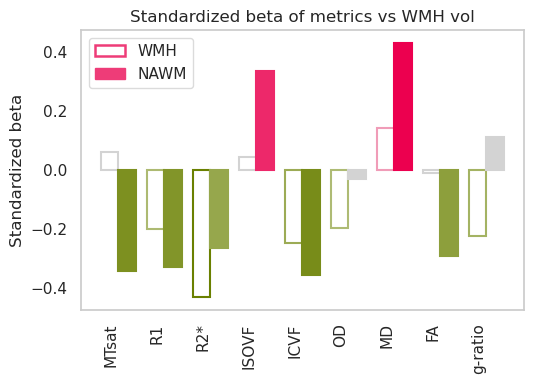

In [44]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

# --- Arrays from your results ---
beta_wmh  = np.array([betas['WMH'].get(m, np.nan)  for m in metrics])
beta_nawm = np.array([betas['NAWM'].get(m, np.nan) for m in metrics])
p_wmh     = np.array([p_fdr_WMH[i]  if i < len(metrics) else np.nan for i in range(len(metrics))])
p_nawm    = np.array([p_fdr_NAWM[i] if i < len(metrics) else np.nan for i in range(len(metrics))])

# Replace NaNs with 0 just for plotting height; significance still uses original NaNs
beta_wmh_plot  = np.nan_to_num(beta_wmh,  nan=0.0)
beta_nawm_plot = np.nan_to_num(beta_nawm, nan=0.0)

# --- Colormap & range (same as before) ---
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
fixed_norm = mcolors.Normalize(vmin=-0.4, vmax=0.4)

# --- Figure ---
plt.figure(figsize=(5.5, 4))
sns.set(style="whitegrid")
ax = plt.gca()

x = np.arange(len(metrics_display))
width = 0.38

# Draw bars explicitly so positions are deterministic
bars_wmh  = ax.bar(x - width/2, beta_wmh_plot,  width, label='WMH')
bars_nawm = ax.bar(x + width/2, beta_nawm_plot, width, label='NAWM')

# Color WMH bars (white fill + colored edge if significant; else grey)
# --- Color WMH bars (left bars) ---
# --- Color WMH bars (left bars) ---
for j, b in enumerate(bars_wmh):
    beta, p = beta_wmh[j], p_wmh[j]
    if np.isfinite(beta) and np.isfinite(p) and p < 0.05:
        col = cmap(fixed_norm(beta))
        b.set_facecolor('white')    # WMH always white fill
        b.set_edgecolor(col)        # edge colored by beta
        b.set_linewidth(1.5)
    else:
        b.set_facecolor('white')    # unsignificant → unfilled white
        b.set_edgecolor('lightgray')
        b.set_linewidth(1.5)

# --- Color NAWM bars (right bars) ---
for j, b in enumerate(bars_nawm):
    beta, p = beta_nawm[j], p_nawm[j]
    if np.isfinite(beta) and np.isfinite(p) and p < 0.05:
        col = cmap(fixed_norm(beta))
        b.set_facecolor(col)        # significant → filled with color
        b.set_edgecolor(col)
        b.set_linewidth(1.5)
    else:
        b.set_facecolor('lightgray')  # unsignificant → filled in gray
        b.set_edgecolor('lightgray')
        b.set_linewidth(1.5)



# Cosmetics
ax.set_title('Standardized beta of metrics vs WMH vol')
ax.set_ylabel('Standardized beta')
ax.set_xlabel(None)
ax.set_xticks(x)
ax.set_xticklabels(metrics_display, rotation=90, ha='right')
ax.grid(False)

# Optional: match y-limits to color range
# ax.set_ylim(-0.4, 0.4)

# Legend: WMH edge-only, NAWM filled
example_color = cmap(fixed_norm(0.3))
legend_handles = [
    mpatches.Patch(facecolor='none', edgecolor=example_color, label='WMH', linewidth=1.8),
    mpatches.Patch(facecolor=example_color, edgecolor=example_color, label='NAWM', linewidth=1.0),
]
ax.legend(handles=legend_handles, loc='upper left', frameon=True,
          facecolor='white', edgecolor='lightgrey')

plt.tight_layout()

# Optional save
try:
    outdir = os.path.join(notebook_dir, 'Figures_new')
    os.makedirs(outdir, exist_ok=True)
    plt.savefig(os.path.join(outdir, 'Effect_size_volume_metrics.png'),
                bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(outdir, 'Effect_size_volume_metrics.svg'),
                format='svg', bbox_inches='tight', transparent=True, dpi=300)
except NameError:
    pass

plt.show()


### Create csv with beta and pvalues of relationships

In [45]:
import pandas as pd

# Build summary table
summary_rows = []
for j, metric in enumerate(metrics):
    summary_rows.append({
        "Metric": metrics_display[j],
        "Beta_WMH": betas['WMH'].get(metric, np.nan),
        "pFDR_WMH": p_fdr_WMH[j] if j < len(p_fdr_WMH) else np.nan,
        "Beta_NAWM": betas['NAWM'].get(metric, np.nan),
        "pFDR_NAWM": p_fdr_NAWM[j] if j < len(p_fdr_NAWM) else np.nan,
    })

df_summary = pd.DataFrame(summary_rows)

# Round for display
print("\n=== Standardized betas and FDR-corrected p-values ===")
print(df_summary.round(4).to_string(index=False))

# Optional: save to CSV
try:
    outdir = os.path.join(notebook_dir, 'Tables')
    os.makedirs(outdir, exist_ok=True)
    df_summary.to_csv(os.path.join(outdir, "betas_WMH_NAWM_logVol_FDR_results.csv"), index=False)
except NameError:
    pass



=== Standardized betas and FDR-corrected p-values ===
 Metric  Beta_WMH  pFDR_WMH  Beta_NAWM  pFDR_NAWM
  MTsat    0.0624    0.4305    -0.3415     0.0000
     R1   -0.1985    0.0039    -0.3270     0.0000
    R2*   -0.4301    0.0000    -0.2639     0.0002
  ISOVF    0.0430    0.5782     0.3339     0.0000
   ICVF   -0.2470    0.0005    -0.3560     0.0000
     OD   -0.1964    0.0039    -0.0315     0.6870
     MD    0.1424    0.0432     0.4298     0.0000
     FA   -0.0085    0.9000    -0.2907     0.0000
g-ratio   -0.2233    0.0014     0.1132     0.1315


### Heatmap relationship vol WMH and metrics per region

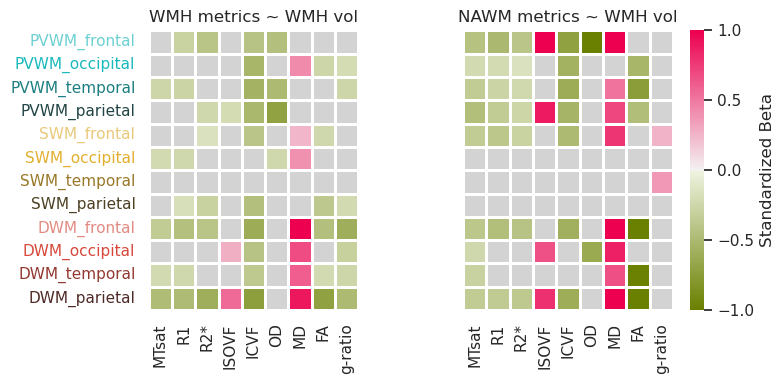

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler



# Assuming df_scaled_voxels contains the merged data with columns 'MT', 'Voxel_Count', and other metrics
df_scaled_voxels = pd.merge(df_voxel_counts, df_scaled, how='inner', left_on=['PR', 'Mask_Type'], right_on=['PR', 'Region'])

# --- WMH Analysis ---
# Filter for WMH
df_scaled_voxels_WMH = df_scaled_voxels[df_scaled_voxels['WMH_NAWM'] == 'WMH'].copy()

regions = df_scaled_voxels_WMH['BaseRegion'].unique()

# Apply log transformation to 'Voxel_Count'
df_scaled_voxels_WMH.loc[:, 'Log_Voxel_Count'] = np.log(df_scaled_voxels_WMH['Voxel_Count'])

# --- Metric-Wise Standardization across All Regions ---
# Standardize 'Log_Voxel_Count' across all regions
scaler = StandardScaler()
df_scaled_voxels_WMH['Log_Voxel_Count_std'] = scaler.fit_transform(df_scaled_voxels_WMH[['Log_Voxel_Count']])

# Initialize lists to store p-values and standardized betas for each region and metric
p_values_WMH = []
standardized_betas_WMH = []

# Define metrics for WMH heatmap
metrics_WMH = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']  # Use 'MT'
metrics_display = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']  # Display 'MTsat'

# --- Metric-Wise Standardization across All Regions ---
# Standardize the metrics across all regions (not region-wise)
scaler = StandardScaler()
df_scaled_voxels_WMH[metrics_WMH] = scaler.fit_transform(df_scaled_voxels_WMH[metrics_WMH])

# Loop through each region for rows and each metric for columns
for region in regions:
    region_p_values = []  # To store p-values for each region
    region_betas = []  # To store standardized betas for each region
    
    for metric in metrics_WMH:
        # Get the data for the current region
        data_region = df_scaled_voxels_WMH[df_scaled_voxels_WMH['BaseRegion'] == region]
        
        # Prepare data for linear model
        X = data_region[metric].values.reshape(-1, 1)  # Independent variable
        X = sm.add_constant(X)  # Add constant term for intercept
        y = data_region['Log_Voxel_Count_std']  # Dependent variable
        
        # Fit linear model (OLS)
        model = sm.OLS(y, X)
        results = model.fit()
        
        # Access the coefficient for the metric (standardized beta)
        metric_key = f'x1'
        beta = results.params[metric_key]
        
        p_value = results.pvalues[metric_key]
        
        # Store standardized beta and p-value
        region_betas.append(beta)
        region_p_values.append(p_value)

    # Append the region's p-values and betas to the lists
    standardized_betas_WMH.append(region_betas)
    p_values_WMH.append(region_p_values)

# Convert the lists to DataFrames for easy manipulation
betas_df_WMH = pd.DataFrame(standardized_betas_WMH, columns=metrics_display, index=regions)
p_values_df_WMH = pd.DataFrame(p_values_WMH, columns=metrics_display, index=regions)

# --- Reorder the regions based on order_regions ---
order_regions = [
    'PVWM_frontal', 'PVWM_occipital', 'PVWM_temporal', 'PVWM_parietal',
    'SWM_frontal', 'SWM_occipital', 'SWM_temporal', 'SWM_parietal',
    'DWM_frontal', 'DWM_occipital', 'DWM_temporal', 'DWM_parietal'
]

betas_df_WMH = betas_df_WMH.loc[order_regions]
p_values_df_WMH = p_values_df_WMH.loc[order_regions]

# Apply FDR correction to the p-values DataFrame
_, corrected_p_values_WMH, _, _ = multipletests(p_values_df_WMH.values.flatten(), method='fdr_bh')

# Reshape corrected p-values to match the p-values DataFrame shape
corrected_p_values_matrix_WMH = np.reshape(corrected_p_values_WMH, p_values_df_WMH.shape)

# Create a mask for non-significant results (p-value >= 0.05)
mask_WMH = corrected_p_values_matrix_WMH >= 0.05

# --- NAWM Analysis ---
# Filter for NAWM
df_scaled_voxels_NAWM = df_scaled_voxels[df_scaled_voxels['WMH_NAWM'] == 'NAWM'].copy()

# Merge the NAWM and WMH datasets on 'PR' and 'BaseRegion' to align the data
df_scaled_voxels_combined = pd.merge(df_scaled_voxels_NAWM, df_scaled_voxels_WMH, 
                                     on=['PR', 'BaseRegion'], suffixes=('_NAWM', '_WMH'))

# Calculate the percentage of WMH voxels among WMH + NAWM voxels for each region
df_scaled_voxels_combined['WMH_Percentage'] = (df_scaled_voxels_combined['Voxel_Count_WMH'] / (
    df_scaled_voxels_combined['Voxel_Count_WMH'] + df_scaled_voxels_combined['Voxel_Count_NAWM']
)) * 100

# --- Metric-Wise Standardization across All Regions ---
# Standardize 'WMH_Percentage' across all regions
scaler = StandardScaler()
df_scaled_voxels_combined['WMH_Percentage_std'] = scaler.fit_transform(df_scaled_voxels_combined[['WMH_Percentage']])

# Apply log transformation to 'Voxel_Count' for NAWM
df_scaled_voxels_NAWM.loc[:, 'Log_Voxel_Count'] = np.log(df_scaled_voxels_NAWM['Voxel_Count'])

# Initialize lists to store p-values and standardized betas for each region and metric
p_values_NAWM = []
standardized_betas_NAWM = []

# Standardize the variables for 'Log_Voxel_Count' (NAWM)
scaler = StandardScaler()
df_scaled_voxels_NAWM.loc[:, 'Log_Voxel_Count_std'] = scaler.fit_transform(df_scaled_voxels_NAWM[['Log_Voxel_Count']])

# Define metrics for NAWM heatmap
metrics_NAWM = ['MT_NAWM', 'R1_NAWM', 'R2*_NAWM', 'ISOVF_NAWM', 'ICVF_NAWM', 'OD_NAWM', 'MD_NAWM', 'FA_NAWM', 'g-ratio_NAWM']  # Use 'MT'

# --- Metric-Wise Standardization across All Regions ---
# Standardize the metrics across all regions (not region-wise)
df_scaled_voxels_combined[metrics_NAWM] = scaler.fit_transform(df_scaled_voxels_combined[metrics_NAWM])

# Loop through each region for rows and each metric for columns
for region in regions:
    region_p_values = []  # To store p-values for each region
    region_betas = []  # To store standardized betas for each region
    
    for metric in metrics_NAWM:
        # Get the data for the current region
        data_region = df_scaled_voxels_combined[df_scaled_voxels_combined['BaseRegion'] == region]
        
        # Prepare data for linear model
        X = data_region[metric].values.reshape(-1, 1)  # Independent variable
        X = sm.add_constant(X)  # Add constant term for intercept
        y = data_region['WMH_Percentage_std']  # Dependent variable for NAWM (standardized percentage of WMH)
        y = data_region['Log_Voxel_Count_std']  # Dependent variable for NAWM (standardized percentage of WMH)
        
        # Fit linear model (OLS)
        model = sm.OLS(y, X)
        results = model.fit()
        
        # Access the coefficient for the metric (standardized beta)
        metric_key = f'x1'
        beta = results.params[metric_key]
        
        p_value = results.pvalues[metric_key]
        
        # Store standardized beta and p-value
        region_betas.append(beta)
        region_p_values.append(p_value)

    # Append the region's p-values and betas to the lists
    standardized_betas_NAWM.append(region_betas)
    p_values_NAWM.append(region_p_values)

# Convert the lists to DataFrames for easy manipulation
betas_df_NAWM = pd.DataFrame(standardized_betas_NAWM, columns=metrics_display, index=regions)
p_values_df_NAWM = pd.DataFrame(p_values_NAWM, columns=metrics_display, index=regions)

betas_df_NAWM = betas_df_NAWM.loc[order_regions]
p_values_df_NAWM = p_values_df_NAWM.loc[order_regions]

# Apply FDR correction to the p-values DataFrame
_, corrected_p_values_NAWM, _, _ = multipletests(p_values_df_NAWM.values.flatten(), method='fdr_bh')

# Reshape corrected p-values to match the p-values DataFrame shape
corrected_p_values_matrix_NAWM = np.reshape(corrected_p_values_NAWM, p_values_df_NAWM.shape)

# Create a mask for non-significant results (p-value >= 0.05)
mask_NAWM = corrected_p_values_matrix_NAWM >= 0.05

# --- Plotting both heatmaps side by side ---
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4), sharex=True, sharey=True)

# Remove underscores from region names for display purposes
regions_display = [region.replace('_', ' ') for region in order_regions]  # Replace underscores with spaces

# Plot the WMH heatmap
sns.heatmap(betas_df_WMH, annot=False, cmap=diverging_cmap, fmt=".2f", 
            xticklabels=metrics_display, yticklabels=regions_display, cbar=False,
            cbar_kws={'label': 'Standardized Beta'}, center=0, vmin=-1, vmax=1,mask=mask_WMH, ax=axes[0],
            square=True, linewidths=1, linecolor='white')

sns.heatmap(betas_df_WMH, annot=False, cmap=light_gray_cmap, 
            mask=~mask_WMH, cbar=False, linewidths=1, linecolor='white', ax=axes[0])


# Color the region names using the defined palette
for i, region in enumerate(regions_display):
    axes[0].yaxis.get_ticklabels()[i].set_color(palette[i])  # Color region names

axes[0].set_title('WMH metrics ~ WMH vol')
axes[0].grid(False)

sns.heatmap(betas_df_NAWM, annot=False, cmap=diverging_cmap, fmt=".2f", 
            xticklabels=metrics_display, yticklabels=regions_display, 
            cbar_kws={'label': 'Standardized Beta'}, center=0, vmin=-1, vmax=1,mask=mask_NAWM, ax=axes[1],
            square=True, linewidths=1, linecolor='white')

sns.heatmap(betas_df_NAWM, annot=False, cmap=light_gray_cmap, 
            mask=~mask_NAWM, cbar=False, linewidths=1, linecolor='white', ax=axes[1])

axes[1].set_title('NAWM metrics ~ WMH vol')
axes[1].grid(False)


# Cosmetics (rotation + colored y-ticks by lobe)
for ax in axes:
    ax.tick_params(axis='x', labelrotation=90, labelright=False)

axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Adjust layout and show the plots
plt.tight_layout()

# Adjust layout to ensure there's no overlap between the legend and the boxplots
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})

# Save the plot
plot_path = os.path.join(notebook_dir, f'Figures_new/Heatmap_metric_volume.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Heatmap_metric_volume.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)

plt.show()


### Heatmap relationship %WMH and metrics per region

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler



# Assuming df_scaled_voxels contains the merged data with columns 'MT', 'Voxel_Count', and other metrics
df_scaled_voxels = pd.merge(df_voxel_counts, df_scaled, how='inner', left_on=['PR', 'Mask_Type'], right_on=['PR', 'Region'])

# --- WMH Analysis ---
# Filter for WMH
df_scaled_voxels_WMH = df_scaled_voxels[df_scaled_voxels['WMH_NAWM'] == 'WMH'].copy()

regions = df_scaled_voxels_WMH['BaseRegion'].unique()

# Apply log transformation to 'Voxel_Count'
df_scaled_voxels_WMH.loc[:, 'Log_Voxel_Count'] = np.log(df_scaled_voxels_WMH['Voxel_Count'])

# --- Metric-Wise Standardization across All Regions ---
# Standardize 'Log_Voxel_Count' across all regions
scaler = StandardScaler()
df_scaled_voxels_WMH['Log_Voxel_Count_std'] = scaler.fit_transform(df_scaled_voxels_WMH[['Log_Voxel_Count']])

# Initialize lists to store p-values and standardized betas for each region and metric
p_values_WMH = []
standardized_betas_WMH = []

# Define metrics for WMH heatmap
metrics_WMH = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']  # Use 'MT'
metrics_display = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']  # Display 'MTsat'

# --- Metric-Wise Standardization across All Regions ---
# Standardize the metrics across all regions (not region-wise)
scaler = StandardScaler()
df_scaled_voxels_WMH[metrics_WMH] = scaler.fit_transform(df_scaled_voxels_WMH[metrics_WMH])

# Loop through each region for rows and each metric for columns
for region in regions:
    region_p_values = []  # To store p-values for each region
    region_betas = []  # To store standardized betas for each region
    
    for metric in metrics_WMH:
        # Get the data for the current region
        data_region = df_scaled_voxels_WMH[df_scaled_voxels_WMH['BaseRegion'] == region]
        
        # Prepare data for linear model
        X = data_region[metric].values.reshape(-1, 1)  # Independent variable
        X = sm.add_constant(X)  # Add constant term for intercept
        y = data_region['Log_Voxel_Count_std']  # Dependent variable
        
        # Fit linear model (OLS)
        model = sm.OLS(y, X)
        results = model.fit()
        
        # Access the coefficient for the metric (standardized beta)
        metric_key = f'x1'
        beta = results.params[metric_key]
        
        p_value = results.pvalues[metric_key]
        
        # Store standardized beta and p-value
        region_betas.append(beta)
        region_p_values.append(p_value)

    # Append the region's p-values and betas to the lists
    standardized_betas_WMH.append(region_betas)
    p_values_WMH.append(region_p_values)

# Convert the lists to DataFrames for easy manipulation
betas_df_WMH = pd.DataFrame(standardized_betas_WMH, columns=metrics_display, index=regions)
p_values_df_WMH = pd.DataFrame(p_values_WMH, columns=metrics_display, index=regions)

# --- Reorder the regions based on order_regions ---
order_regions = [
    'PVWM_frontal', 'PVWM_occipital', 'PVWM_temporal', 'PVWM_parietal',
    'SWM_frontal', 'SWM_occipital', 'SWM_temporal', 'SWM_parietal',
    'DWM_frontal', 'DWM_occipital', 'DWM_temporal', 'DWM_parietal'
]

betas_df_WMH = betas_df_WMH.loc[order_regions]
p_values_df_WMH = p_values_df_WMH.loc[order_regions]

# Apply FDR correction to the p-values DataFrame
_, corrected_p_values_WMH, _, _ = multipletests(p_values_df_WMH.values.flatten(), method='fdr_bh')

# Reshape corrected p-values to match the p-values DataFrame shape
corrected_p_values_matrix_WMH = np.reshape(corrected_p_values_WMH, p_values_df_WMH.shape)

# Create a mask for non-significant results (p-value >= 0.05)
mask_WMH = corrected_p_values_matrix_WMH >= 0.05

# --- NAWM Analysis ---
# Filter for NAWM
df_scaled_voxels_NAWM = df_scaled_voxels[df_scaled_voxels['WMH_NAWM'] == 'NAWM'].copy()

# Merge the NAWM and WMH datasets on 'PR' and 'BaseRegion' to align the data
df_scaled_voxels_combined = pd.merge(df_scaled_voxels_NAWM, df_scaled_voxels_WMH, 
                                     on=['PR', 'BaseRegion'], suffixes=('_NAWM', '_WMH'))

# Calculate the percentage of WMH voxels among WMH + NAWM voxels for each region
df_scaled_voxels_combined['WMH_Percentage'] = (df_scaled_voxels_combined['Voxel_Count_WMH'] / (
    df_scaled_voxels_combined['Voxel_Count_WMH'] + df_scaled_voxels_combined['Voxel_Count_NAWM']
)) * 100

# --- Metric-Wise Standardization across All Regions ---
# Standardize 'WMH_Percentage' across all regions
scaler = StandardScaler()
df_scaled_voxels_combined['WMH_Percentage_std'] = scaler.fit_transform(df_scaled_voxels_combined[['WMH_Percentage']])

# Apply log transformation to 'Voxel_Count' for NAWM
df_scaled_voxels_NAWM.loc[:, 'Log_Voxel_Count'] = np.log(df_scaled_voxels_NAWM['Voxel_Count'])

# Initialize lists to store p-values and standardized betas for each region and metric
p_values_NAWM = []
standardized_betas_NAWM = []

# Standardize the variables for 'Log_Voxel_Count' (NAWM)
scaler = StandardScaler()
df_scaled_voxels_NAWM.loc[:, 'Log_Voxel_Count_std'] = scaler.fit_transform(df_scaled_voxels_NAWM[['Log_Voxel_Count']])

# Define metrics for NAWM heatmap
metrics_NAWM = ['MT_NAWM', 'R1_NAWM', 'R2*_NAWM', 'ISOVF_NAWM', 'ICVF_NAWM', 'OD_NAWM', 'MD_NAWM', 'FA_NAWM', 'g-ratio_NAWM']  # Use 'MT'

# --- Metric-Wise Standardization across All Regions ---
# Standardize the metrics across all regions (not region-wise)
df_scaled_voxels_combined[metrics_NAWM] = scaler.fit_transform(df_scaled_voxels_combined[metrics_NAWM])

# Loop through each region for rows and each metric for columns
for region in regions:
    region_p_values = []  # To store p-values for each region
    region_betas = []  # To store standardized betas for each region
    
    for metric in metrics_NAWM:
        # Get the data for the current region
        data_region = df_scaled_voxels_combined[df_scaled_voxels_combined['BaseRegion'] == region]
        
        # Prepare data for linear model
        X = data_region[metric].values.reshape(-1, 1)  # Independent variable
        X = sm.add_constant(X)  # Add constant term for intercept
        y = data_region['WMH_Percentage_std']  # Dependent variable for NAWM (standardized percentage of WMH)
        
        # Fit linear model (OLS)
        model = sm.OLS(y, X)
        results = model.fit()
        
        # Access the coefficient for the metric (standardized beta)
        metric_key = f'x1'
        beta = results.params[metric_key]
        
        p_value = results.pvalues[metric_key]
        
        # Store standardized beta and p-value
        region_betas.append(beta)
        region_p_values.append(p_value)

    # Append the region's p-values and betas to the lists
    standardized_betas_NAWM.append(region_betas)
    p_values_NAWM.append(region_p_values)

# Convert the lists to DataFrames for easy manipulation
betas_df_NAWM = pd.DataFrame(standardized_betas_NAWM, columns=metrics_display, index=regions)
p_values_df_NAWM = pd.DataFrame(p_values_NAWM, columns=metrics_display, index=regions)

betas_df_NAWM = betas_df_NAWM.loc[order_regions]
p_values_df_NAWM = p_values_df_NAWM.loc[order_regions]

# Apply FDR correction to the p-values DataFrame
_, corrected_p_values_NAWM, _, _ = multipletests(p_values_df_NAWM.values.flatten(), method='fdr_bh')

# Reshape corrected p-values to match the p-values DataFrame shape
corrected_p_values_matrix_NAWM = np.reshape(corrected_p_values_NAWM, p_values_df_NAWM.shape)

# Create a mask for non-significant results (p-value >= 0.05)
mask_NAWM = corrected_p_values_matrix_NAWM >= 0.05

# --- Plotting both heatmaps side by side ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

# Remove underscores from region names for display purposes
regions_display = [region.replace('_', ' ') for region in order_regions]  # Replace underscores with spaces

# Plot the WMH heatmap
sns.heatmap(betas_df_WMH, annot=False, cmap=diverging_cmap, fmt=".2f", 
            xticklabels=metrics_display, yticklabels=regions_display, cbar=False,
            cbar_kws={'label': 'Standardized Beta'}, center=0, vmin=-1, vmax=1,mask=mask_WMH, ax=axes[0],
            square=True, linewidths=1, linecolor='white')

sns.heatmap(betas_df_WMH, annot=False, cmap=light_gray_cmap, 
            mask=~mask_WMH, cbar=False, linewidths=1, linecolor='white', ax=axes[0])


# Color the region names using the defined palette
for i, region in enumerate(regions_display):
    axes[0].yaxis.get_ticklabels()[i].set_color(palette[i])  # Color region names

axes[0].set_title('WMH metrics ~ WMH vol')
axes[0].grid(False)

sns.heatmap(betas_df_NAWM, annot=False, cmap=diverging_cmap, fmt=".2f", 
            xticklabels=metrics_display, yticklabels=regions_display, 
            cbar_kws={'label': 'Standardized Beta'}, center=0, vmin=-1, vmax=1,mask=mask_NAWM, ax=axes[1],
            square=True, linewidths=1, linecolor='white')

sns.heatmap(betas_df_NAWM, annot=False, cmap=light_gray_cmap, 
            mask=~mask_NAWM, cbar=False, linewidths=1, linecolor='white', ax=axes[1])

axes[1].set_title('NAWM metrics ~ %WMH')
axes[1].grid(False)


# Cosmetics (rotation + colored y-ticks by lobe)
for ax in axes:
    ax.tick_params(axis='x', labelrotation=90, labelright=False)

axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Adjust layout and show the plots
plt.tight_layout()

# Adjust layout to ensure there's no overlap between the legend and the boxplots
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})

# Save the plot
plot_path = os.path.join(notebook_dir, f'Figures_new/Heatmap_metric_volume_percent.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Heatmap_metric_volume_percent.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)

plt.show()


### Find largest beta

In [54]:
# Flatten the betas DataFrame and keep track of region + metric
betas_flat = betas_df_NAWM.stack().reset_index()
betas_flat.columns = ['BaseRegion', 'Metric', 'Standardized Beta']

# Find row with largest positive beta
max_row = betas_flat.loc[betas_flat['Standardized Beta'].idxmax()]
# Find row with largest negative beta
min_row = betas_flat.loc[betas_flat['Standardized Beta'].idxmin()]

# Display
print("🔹 Largest positive standardized beta in NAWM:")
print(f"   Region: {max_row['BaseRegion']}, Metric: {max_row['Metric']}, Beta: +{max_row['Standardized Beta']:.3f}")

print("🔹 Largest negative standardized beta in NAWM:")
print(f"   Region: {min_row['BaseRegion']}, Metric: {min_row['Metric']}, Beta: {min_row['Standardized Beta']:.3f}")


🔹 Largest positive standardized beta in NAWM:
   Region: PVWM_frontal, Metric: MD, Beta: +1.230
🔹 Largest negative standardized beta in NAWM:
   Region: PVWM_frontal, Metric: OD, Beta: -1.526


## Fig 4 - PCA

### Run PCA

In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# === Parameters ===
nawm_regions = [
    'NAWM_PVWM_frontal', 'NAWM_PVWM_occipital', 'NAWM_PVWM_temporal', 'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal', 'NAWM_SWM_occipital', 'NAWM_SWM_temporal', 'NAWM_SWM_parietal',
    'NAWM_DWM_frontal', 'NAWM_DWM_occipital', 'NAWM_DWM_temporal', 'NAWM_DWM_parietal',
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal', 'WMH_SWM_occipital', 'WMH_SWM_temporal', 'WMH_SWM_parietal',
    'WMH_DWM_frontal', 'WMH_DWM_occipital', 'WMH_DWM_temporal', 'WMH_DWM_parietal'
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# === Build full matrix ===
rows = []
for region in nawm_regions:
    region_df = create_region_df(region)
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics})
    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"⚠️ Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

# === Remove rows with any NaN in metrics ===
df_full = pd.concat(rows, ignore_index=True)

# Assuming df_full and final_matched_rows are available
df_full = df_full[df_full['PR'].isin(final_matched_rows['PR'])]

df_no_nan = df_full.dropna(subset=metrics).reset_index(drop=True)
print(f"Number of rows before dropping NaNs: {len(df_full)}")
print(f"Number of rows after dropping NaNs: {len(df_no_nan)}")

# === Standardize metrics ===
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(df_no_nan[metrics])

df_scaled = df_no_nan.copy()
df_scaled[metrics] = metrics_scaled

# === Run PCA ===
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[metrics])

df_scaled['PC1'] = pca_result[:, 0]
df_scaled['PC2'] = pca_result[:, 1]

# Variance explained by PC1 and PC2
var_pc1 = pca.explained_variance_ratio_[0]
var_pc2 = pca.explained_variance_ratio_[1]

print(f"🔹 PC1 explains {var_pc1 * 100:.2f}% of the variance")
print(f"🔹 PC2 explains {var_pc2 * 100:.2f}% of the variance")

n_perm = 10000
null_var_pc1 = []

for _ in range(n_perm):
    # Shuffle rows within each metric (independently)
    shuffled = df_scaled[metrics].apply(np.random.permutation).values
    pca_null = PCA(n_components=2).fit(shuffled)
    null_var_pc1.append(pca_null.explained_variance_ratio_[0])

# Compute how extreme your PC1 variance is
p_perm_pc1 = (np.sum(null_var_pc1 >= var_pc1) + 1) / (n_perm + 1)
print(f"🔹 Permutation p-value for PC1 variance: {p_perm_pc1:.4f}")

null_var_pc2 = []

for _ in range(n_perm):
    # Shuffle rows within each metric (independently)
    shuffled = df_scaled[metrics].apply(np.random.permutation).values
    pca_null = PCA(n_components=2).fit(shuffled)
    null_var_pc2.append(pca_null.explained_variance_ratio_[1])

# Compute how extreme your PC1 variance is
p_perm_pc2 = (np.sum(null_var_pc2 >= var_pc2) + 1) / (n_perm + 1)
print(f"🔹 Permutation p-value for PC2 variance: {p_perm_pc2:.4f}")


Number of rows before dropping NaNs: 4704
Number of rows after dropping NaNs: 3687
🔹 PC1 explains 56.98% of the variance
🔹 PC2 explains 22.79% of the variance
🔹 Permutation p-value for PC1 variance: 0.0001
🔹 Permutation p-value for PC2 variance: 0.0001


### Plot input matrix

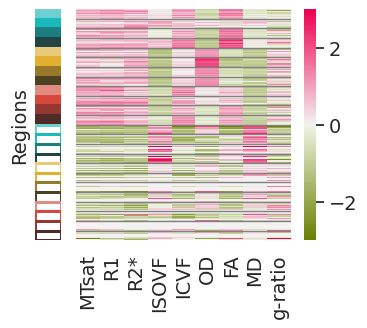

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl

# Define 3 main colors for the palette
main_colors = ['#19b9bc', '#e2af2e', '#d7483b']  # Blue, Green, Orange

# Create a palette with 4 shades for each main color, from light to dark with more contrast
palette_color = []
palette = []

for color in main_colors:
    # Generate both light and dark palettes for more contrast
    light_shades = sns.light_palette(color, n_colors=6)[3:4]  # Skip the first color to avoid white
    light_shades1 = sns.light_palette(color, n_colors=6)[5:6]  # Skip the first color to avoid white
    dark_shades = sns.dark_palette(color, n_colors=6)[3:4]  # Reverse the order of dark shades    
    dark_shades1 = sns.dark_palette(color, n_colors=6)[1:2]  
    # Combine the shades to get a better contrast (light + dark)
    palette_color += light_shades + light_shades1 + dark_shades + dark_shades1

# Create a palette of white (12 shades of white)
palette_white = [[1, 1, 1] for _ in range(12)]  # All entries are white [1, 1, 1] (RGB)
palette = palette_color + palette_color  # Repeat palette to make it larger

# Combine color and white palettes
palette_color_white = palette_color + palette_white

# Assuming df_full contains the data for all regions and metrics
# Extract WMH_NAWM, TissueType, and Lobe from the 'Region' column
df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0])  # Extract NAWM or WMH
df_full['TissueType'] = df_full['Region'].apply(lambda x: x.split('_')[1])  # Extract PVWM, DWM, SWM
df_full['Lobe'] = df_full['Region'].apply(lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown')  # Extract Lobe

# Reshape the data so we can have regions as columns and PRs as rows
heatmap_data = df_full.set_index('Region').T  # Transpose to have regions as columns and metrics as rows
heatmap_data = heatmap_data.T  # Re-transpose to keep PRs as rows and metrics as columns

# Only keep the numeric columns (metrics) for normalization
heatmap_data_numeric = heatmap_data.drop(columns=['PR', 'Lobe', 'WMH_NAWM', 'TissueType'])

# Z-score normalize the numeric columns (metrics)
scaler = StandardScaler()
heatmap_data_zscore = pd.DataFrame(scaler.fit_transform(heatmap_data_numeric), columns=heatmap_data_numeric.columns, index=heatmap_data.index)

# Optionally fill NaN values with 0 (or some other strategy)
heatmap_data_zscore = heatmap_data_zscore.fillna(0)

# Define the diverging color palette centered at 0
diverging_cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

# Get PCA loadings (assuming `pca` and `metrics` are predefined)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=metrics
)

loadings.index = loadings.index.str.replace("MT", "MTsat")

# Create subplots with 4 plots (1 color palette heatmap, 2 PCA loadings)
fig1, axes = plt.subplots(1, 2, figsize=(4, 3), gridspec_kw={'width_ratios': [0.1, 1]})

# Create the heatmap for the color palette (on the left)
palette_array = np.arange(0, len(palette_color_white), 1).reshape(1, -1)  # One row with many columns
sns.heatmap(palette_array.T, annot=False, cmap=palette_color_white, cbar=False, xticklabels=False, yticklabels=False, 
            linewidths=1, ax=axes[0], linecolor=palette)  # Color palette on the left
axes[0].set_ylabel("Regions")

# Create the heatmap for the Z-scored metrics (middle)
sns.heatmap(heatmap_data_zscore, annot=False, cmap=diverging_cmap, center=0, 
            yticklabels=False, xticklabels=True,  # No x or y axis labels
            vmin=-3, vmax=3, linewidths=0, cbar=True, ax=axes[1])
axes[1].set_xticklabels(loadings.index, rotation=90)

# Add thin black lines where the region changes
region_changes = heatmap_data_zscore.index.to_list()

# Find the positions where the region changes
region_change_indices = [0]  # Start at index 0 for the first region
for i in range(1, len(region_changes)):
    if region_changes[i] != region_changes[i-1]:  # Check if the region changes
        region_change_indices.append(i)  # Add the index where the region changes

# Add thin black lines where the region changes
for i in range(1, len(region_change_indices)):
    axes[1].axhline(region_change_indices[i] - 0.5, color='gray', linewidth=1)  # Add a line where the region changes

# Add labels for regions on the left side of the heatmap
axes[1].set_title(None)
axes[1].set_ylabel(None)

# Adjust layout to ensure there's no overlap
plt.subplots_adjust(wspace=0.1)  # Add some space between the first 2 subplots
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })
plot_path = os.path.join(notebook_dir, f'Figures_new/PC_loadings_region_1.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PC_loadings_region_1.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
#Show the plot
plt.show()


### Barplots PC1/PC2 loadings

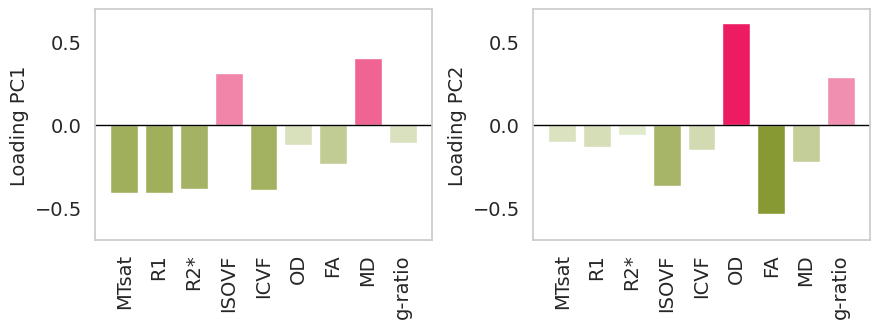

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl

# Assuming df_full contains the data for all regions and metrics
# Extract WMH_NAWM, TissueType, and Lobe from the 'Region' column
df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0])  # Extract NAWM or WMH
df_full['TissueType'] = df_full['Region'].apply(lambda x: x.split('_')[1])  # Extract PVWM, DWM, SWM
df_full['Lobe'] = df_full['Region'].apply(lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown')  # Extract Lobe

# Reshape the data so we can have regions as columns and PRs as rows
heatmap_data = df_full.set_index('Region').T  # Transpose to have regions as columns and metrics as rows
heatmap_data = heatmap_data.T  # Re-transpose to keep PRs as rows and metrics as columns

# Only keep the numeric columns (metrics) for normalization
heatmap_data_numeric = heatmap_data.drop(columns=['PR', 'Lobe', 'WMH_NAWM', 'TissueType'])

# Z-score normalize the numeric columns (metrics)
scaler = StandardScaler()
heatmap_data_zscore = pd.DataFrame(scaler.fit_transform(heatmap_data_numeric), columns=heatmap_data_numeric.columns, index=heatmap_data.index)

# Optionally fill NaN values with 0 (or some other strategy)
heatmap_data_zscore = heatmap_data_zscore.fillna(0)

# Define the diverging color palette centered at 0
diverging_cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

# Get PCA loadings (assuming `pca` and `metrics` are predefined)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=metrics
)

loadings.index = loadings.index.str.replace("MT", "MTsat")

# Create subplots with 4 plots (1 color palette heatmap, 2 PCA loadings)
fig, axes = plt.subplots(1, 2, figsize=(10, 3), gridspec_kw={'width_ratios': [1, 1]})
    
# PCA Loadings for PC1
for i, pc in enumerate(['PC1', 'PC2']):
    ax = axes[i]
    
    # Normalize loadings for colormap
    norm = mcolors.Normalize(vmin=-0.7, vmax=0.7)
    cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

    # Get colors based on loading value
    colors = [cmap(norm(val)) for val in loadings[pc]]

    # Create a vertical barplot (positive bars to the right, negative to the left)
    bars = ax.bar(loadings.index, loadings[pc], color=colors)

    # Optional: add vertical line at 0
    ax.axhline(0, color='black', linewidth=1)

    # Labeling and formatting
    ax.set_ylabel(f'Loading {pc}')
    ax.set_title('')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Adjust the bars such that the negative ones are at the left
    ax.set_ylim([-0.7, 0.7])  # Adjust y-axis limits to ensure full range from -1 to 1

    # Add this before setting the tick labels:
    ax.set_xticks(np.arange(len(loadings.index)))  # This sets the ticks at the correct positions
    ax.set_xticklabels(loadings.index, rotation=90)
    ax.grid(False)

# Adjust layout to ensure there's no overlap
plt.subplots_adjust(wspace=0.3)  # Add some space between the first 2 subplots
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })
plot_path = os.path.join(notebook_dir, f'Figures_new/PC_loadings_region_2.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PC_loadings_region_2.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
#Show the plot
plt.show()


In [51]:
# Square the loadings for PC1
sq_loadings_PC1 = loadings['PC1']**2

# Normalize contributions so they sum to 1
contributions_PC1 = sq_loadings_PC1 / sq_loadings_PC1.sum()

# Define metrics of interest
group_A = ['MTsat', 'R1', 'R2*']

# Compute variance contributions
group_A_contrib = contributions_PC1.loc[group_A].sum()
group_B_contrib = contributions_PC1.drop(group_A).sum()

print(f"PC1 variance explained by {group_A}: {group_A_contrib:.2%}")
print(f"PC1 variance explained by rest: {group_B_contrib:.2%}")


PC1 variance explained by ['MTsat', 'R1', 'R2*']: 49.61%
PC1 variance explained by rest: 50.39%


### Plot PC1 vs PC2 coloured by regions

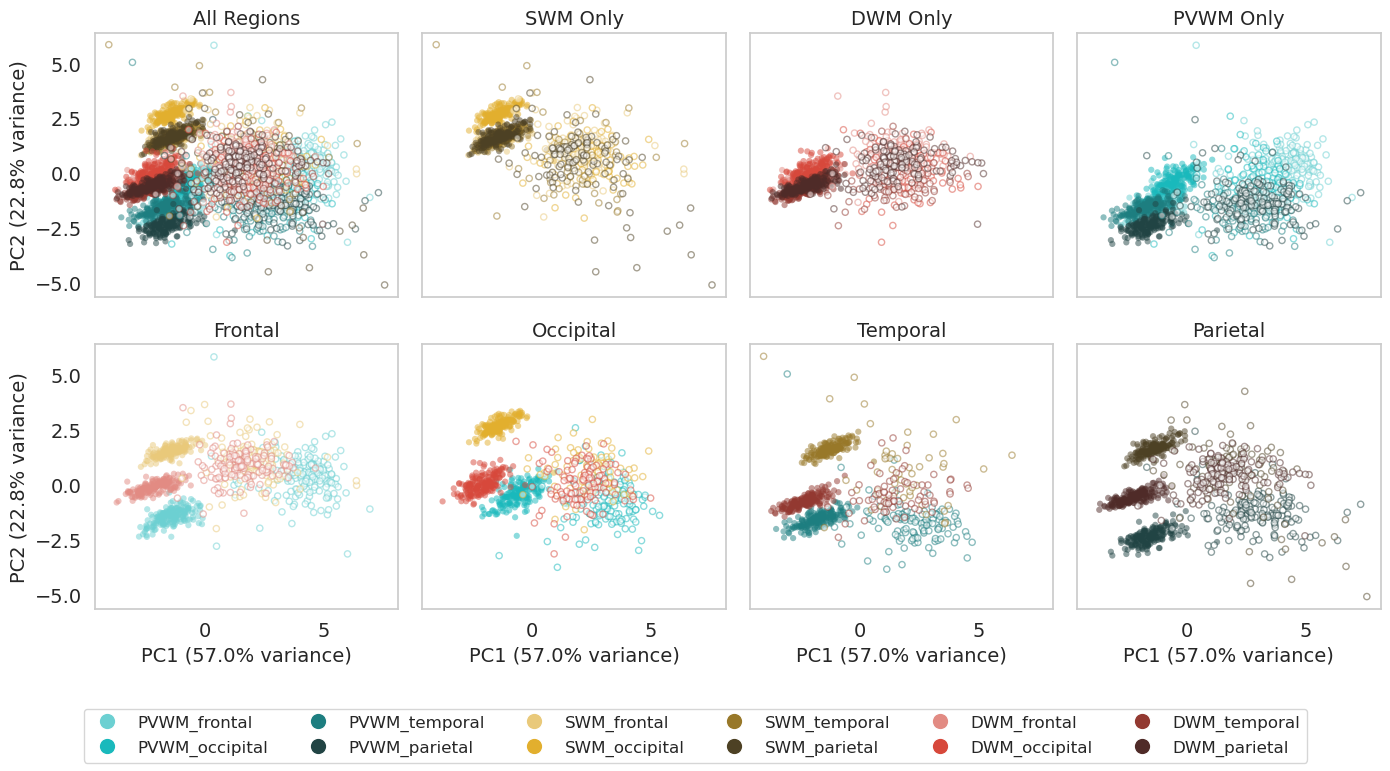

In [50]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D



# === Add "Type" column: PVWM / SWM / DWM ===
def extract_type(region_name):
    if 'PVWM' in region_name:
        return 'PVWM'
    elif 'SWM' in region_name:
        return 'SWM'
    elif 'DWM' in region_name:
        return 'DWM'
    else:
        return 'Other'

df_scaled['Type'] = df_scaled['Region'].apply(extract_type)

# === Prepare base region names ===
df_scaled['BaseRegion'] = df_scaled['Region'].str.replace('WMH_', '', regex=False)
df_scaled['BaseRegion'] = df_scaled['BaseRegion'].str.replace('NAWM_', '', regex=False)

# Assign color per BaseRegion
base_regions_unique = df_scaled['BaseRegion'].unique()
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(base_regions_unique)}
df_scaled['WMH_NAWM'] = df_scaled['Region'].apply(lambda x: 'WMH' if 'WMH' in x else 'NAWM')

# === Create 2 rows of 4 subplots ===
fig, axes = plt.subplots(2, 4, figsize=(14, 8), facecolor='white', sharex=True, sharey=True)

# === First row: All / SWM / DWM / PVWM ===
# 1. All regions
df_sub = df_scaled
ax = axes[0, 0]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           label='NAWM', alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           label='WMH', alpha=0.5, linewidths=1, s=20)
ax.set_title('All Regions')
ax.set_facecolor('white')
ax.grid(False)

# 2. SWM only
df_sub = df_scaled[df_scaled['Type'] == 'SWM']
ax = axes[0, 1]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('SWM Only')
ax.set_facecolor('white')
ax.grid(False)

# 3. DWM only
df_sub = df_scaled[df_scaled['Type'] == 'DWM']
ax = axes[0, 2]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('DWM Only')
ax.set_facecolor('white')
ax.grid(False)

# 4. PVWM only
df_sub = df_scaled[df_scaled['Type'] == 'PVWM']
ax = axes[0, 3]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('PVWM Only')
ax.set_facecolor('white')
ax.grid(False)

# === Second row: Frontal / Occipital / Parietal / Temporal ===
regions_order = ['frontal', 'occipital', 'temporal', 'parietal']
for ax, region in zip(axes[1], regions_order):
    df_sub = df_scaled[df_scaled['Region'].str.contains(region)]
    df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
    ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
               c=df_nawm['BaseRegion'].map(base_region_colors),
               alpha=0.5, edgecolors='none', s=20)
    df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
    ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
               facecolors='white',
               edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
               alpha=0.5, linewidths=1, s=20)
    ax.set_title(f'{region.capitalize()}')
    ax.set_facecolor('white')
    ax.grid(False)

# === Global labels ===
for ax in axes[:, 0]:
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
for ax in axes[1, :]:
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')

# Create legend handles for the regions
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=12, label=region)
           for region, color in base_region_colors.items()]

fig.legend(handles=handles, title='', loc='lower center', ncol=6, fontsize=12)

plt.tight_layout(rect=[0, 0.1, 1, 0.98])  # Leave space for suptitle and legend
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })
plot_path = os.path.join(notebook_dir, f'Figures_new/PC_loadings_scatterplot.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PC_loadings_scatterplot.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()


### Barplot PC1 and PC2 loading per region

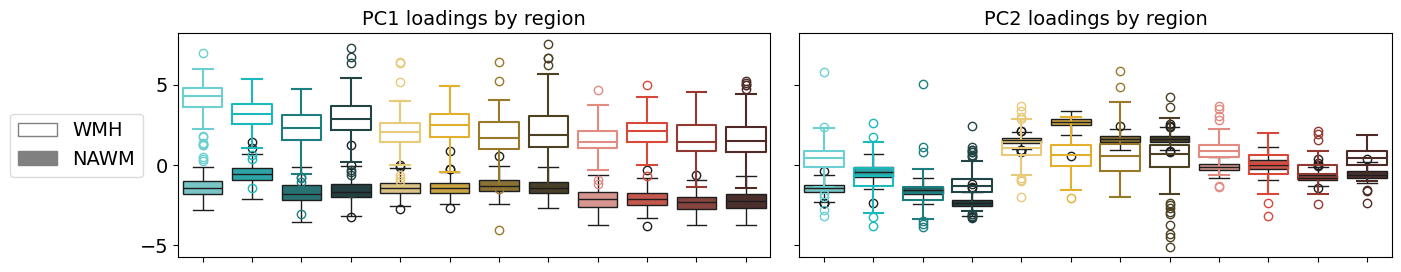

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Ensure all regions have colors assigned, including missing ones
all_regions = df_scaled['BaseRegion'].unique()  # Get all unique regions
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(all_regions)}

# Create a figure with 1 row and 2 columns for the side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)

# Plotting PC1 on the first axis
sns.boxplot(data=df_scaled[df_scaled['WMH_NAWM'] == 'NAWM'], x='BaseRegion', y='PC1', 
            hue='BaseRegion', palette=base_region_colors, showfliers=True, ax=axes[0])

sns.boxplot(data=df_scaled[df_scaled['WMH_NAWM'] == 'WMH'], x='BaseRegion', y='PC1', 
            hue='BaseRegion', palette=base_region_colors, showfliers=True, fill=False, ax=axes[0])

axes[0].set_title('PC1 loadings by region')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=90)

# Plotting PC2 on the second axis
sns.boxplot(data=df_scaled[df_scaled['WMH_NAWM'] == 'NAWM'], x='BaseRegion', y='PC2', 
            hue='BaseRegion', palette=base_region_colors, showfliers=True, ax=axes[1])

sns.boxplot(data=df_scaled[df_scaled['WMH_NAWM'] == 'WMH'], x='BaseRegion', y='PC2', 
            hue='BaseRegion', palette=base_region_colors, showfliers=True, fill=False, ax=axes[1])

axes[1].set_title('PC2 loadings by region')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=90)

# Hide x-axis labels on the second plot (PC2)
axes[0].set_xticklabels([])  # Removes the tick labels for x-axis
axes[1].set_xticklabels([])  # Removes the tick labels for x-axis
axes[0].grid(False)
axes[1].grid(False)

# Get the first color of the palette for the NAWM and WMH legend boxes
first_color = palette[2]  # First color from the palette

# Create custom legend handles
nawm_patch = mpatches.Patch(color='gray', label='NAWM', linewidth=1)  # Solid box for NAWM with the first color
wmh_patch = mpatches.Patch(edgecolor='gray', facecolor='none', label='WMH', linewidth=1)  # Edge-only for WMH with increased edge size

# Place the legend on the left side of the grid without overlapping the boxplots
axes[0].legend(handles=[wmh_patch, nawm_patch], loc='center left', bbox_to_anchor=(-0.3, 0.5), 
               frameon=True, facecolor='white', edgecolor='lightgrey', fontsize=14)

# Adjust layout to ensure there's no overlap between the legend and the boxplots
plt.tight_layout()  # Add padding between plots and the legend
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})

# Save the plot
plot_path = os.path.join(notebook_dir, f'Figures_new/PC_loadings_boxplots.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PC_loadings_boxplots.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)

# Show the plot
plt.show()


### Calculate stats on PC loadings

In [ ]:
# Compute overall mean PC1 for WMH and NAWM
mean_pc1_overall = (
    df_scaled
    .groupby('WMH_NAWM')['PC1']
    .mean()
    .round(3)
)

# Display results
print("🔹 Overall mean PC1:")
for wmh_nawm, mean_val in mean_pc1_overall.items():
    print(f"   {wmh_nawm}: {mean_val}")


🔹 Overall mean PC1:
   NAWM: -1.637
   WMH: 2.405


In [ ]:
from scipy.stats import mannwhitneyu

# Get PC1 values for WMH and NAWM
pc1_wmh = df_scaled[df_scaled['WMH_NAWM'] == 'WMH']['PC1']
pc1_nawm = df_scaled[df_scaled['WMH_NAWM'] == 'NAWM']['PC1']

# Mann-Whitney U test
stat, p_value = mannwhitneyu(pc1_wmh, pc1_nawm, alternative='two-sided')

print(f"🔹 Mann-Whitney U test PC1 WMH vs NAWM (all regions):")
print(f"   U = {stat:.0f}, p = {p_value:.4e}")


🔹 Mann-Whitney U test PC1 WMH vs NAWM (all regions):
   U = 3252654, p = 0.0000e+00


In [ ]:
from scipy.stats import kruskal

# Group PC2 values by Type
pc2_swm = df_scaled[df_scaled['Type'] == 'SWM']['PC2']
pc2_pvwm = df_scaled[df_scaled['Type'] == 'PVWM']['PC2']
pc2_dwm = df_scaled[df_scaled['Type'] == 'DWM']['PC2']

# Kruskal-Wallis test
stat, p_value = kruskal(pc2_swm, pc2_pvwm, pc2_dwm)

print(f"🔹 Kruskal-Wallis PC2 across SWM / PVWM / DWM:")
print(f"   H = {stat:.3f}, p = {p_value:.4e}")


🔹 Kruskal-Wallis PC2 across SWM / PVWM / DWM:
   H = 2104.381, p = 0.0000e+00


In [ ]:
# Group by Type and compute mean PC2
mean_pc2_by_type = (
    df_scaled
    .groupby('Type')['PC2']
    .mean()
    .round(3)
)

# Display results
print("🔹 Mean PC2 by Type:")
for t, mean_val in mean_pc2_by_type.items():
    print(f"   {t}: {mean_val}")


🔹 Mean PC2 by Type:
   DWM: -0.073
   PVWM: -1.138
   SWM: 1.472


### Plot centroid and distance between PCs

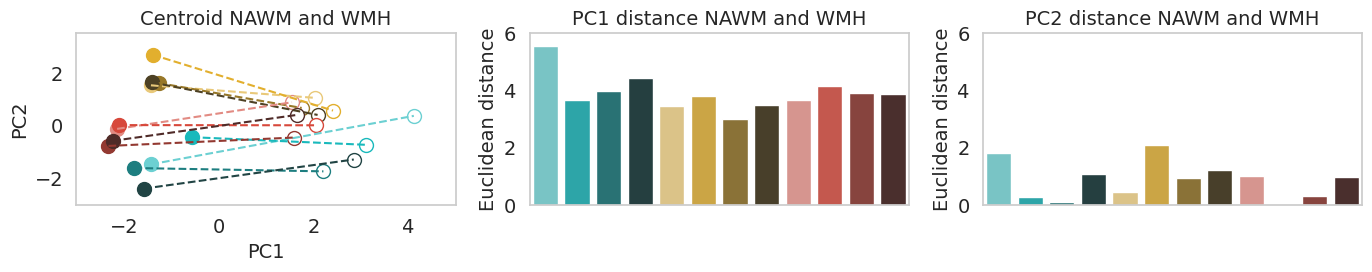

            Region            PC  Distance
0     PVWM_frontal  PC1 Distance  5.543533
1   PVWM_occipital  PC1 Distance  3.668750
2    PVWM_temporal  PC1 Distance  3.987532
3    PVWM_parietal  PC1 Distance  4.425154
4      SWM_frontal  PC1 Distance  3.453280
5    SWM_occipital  PC1 Distance  3.809061
6     SWM_temporal  PC1 Distance  3.019530
7     SWM_parietal  PC1 Distance  3.497961
8      DWM_frontal  PC1 Distance  3.689560
9    DWM_occipital  PC1 Distance  4.170142
10    DWM_temporal  PC1 Distance  3.910641
11    DWM_parietal  PC1 Distance  3.896215
12    PVWM_frontal  PC2 Distance  1.830418
13  PVWM_occipital  PC2 Distance  0.287735
14   PVWM_temporal  PC2 Distance  0.125833
15   PVWM_parietal  PC2 Distance  1.098594
16     SWM_frontal  PC2 Distance  0.473979
17   SWM_occipital  PC2 Distance  2.112154
18    SWM_temporal  PC2 Distance  0.941811
19    SWM_parietal  PC2 Distance  1.232363
20     DWM_frontal  PC2 Distance  1.006439
21   DWM_occipital  PC2 Distance  0.007308
22    DWM_t

In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare DataFrame with PC1, PC2 and Region
df_pca = df_scaled.copy()
df_pca['PC1'] = pca_result[:, 0]
df_pca['PC2'] = pca_result[:, 1]

# Function to calculate Euclidean distance between two points
def euclidean_distance(p1, p2):
    return np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)

# Initialize a list to store the distances for PC1 and PC2 separately
centroid_distances = []

# Get unique regions
regions = df_pca['BaseRegion'].unique()

base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(base_regions_unique)}
df_scaled['WMH_NAWM'] = df_scaled['Region'].apply(lambda x: 'WMH' if 'WMH' in x else 'NAWM')

# Loop over all regions to compute centroid distances for both PC1 and PC2
for region in regions:
    # Subset data for NAWM and WMH
    df_nawm = df_pca[(df_pca['WMH_NAWM'] == 'NAWM') & (df_pca['BaseRegion'] == region)]
    df_wmh = df_pca[(df_pca['WMH_NAWM'] == 'WMH') & (df_pca['BaseRegion'] == region)]
    
    # Calculate centroids for PC1 and PC2 (mean of PC1 and PC2)
    centroid_nawm_pc1 = df_nawm['PC1'].mean()
    centroid_nawm_pc2 = df_nawm['PC2'].mean()
    centroid_wmh_pc1 = df_wmh['PC1'].mean()
    centroid_wmh_pc2 = df_wmh['PC2'].mean()
    
    # Calculate Euclidean distance for PC1 and PC2
    distance_pc1 = np.abs(centroid_nawm_pc1 - centroid_wmh_pc1)  # Absolute distance between centroids for PC1
    distance_pc2 = np.abs(centroid_nawm_pc2 - centroid_wmh_pc2)  # Absolute distance between centroids for PC2
    
    # Store the distances
    centroid_distances.append({'Region': region, 'PC1 Distance': distance_pc1, 'PC2 Distance': distance_pc2})

# Convert the distances into a DataFrame for easy plotting
centroid_distances_df = pd.DataFrame(centroid_distances)

# Reshape the data for easier plotting (long format)
centroid_distances_long_df = pd.melt(centroid_distances_df, id_vars=['Region'], 
                                     value_vars=['PC1 Distance', 'PC2 Distance'], 
                                     var_name='PC', value_name='Distance')

# Define color palette for PC1
pc1_palette = base_region_colors

# Set up three subplots for PC1, PC2, and scatter plot
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=False)

# Plot PC1 distance in the first subplot
sns.barplot(data=centroid_distances_long_df[centroid_distances_long_df['PC'] == 'PC1 Distance'], 
            x='Region', y='Distance', hue='Region', palette=pc1_palette, ax=axes[1])

axes[1].set_title('PC1 distance NAWM and WMH')
axes[1].set_xlabel('')
axes[1].set_ylabel('Euclidean distance')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_ylim(0, 6)  # Adjust y-axis limit for PC1

# Plot PC2 distance in the second subplot (with stripes for PC2)
sns.barplot(data=centroid_distances_long_df[centroid_distances_long_df['PC'] == 'PC2 Distance'], 
            x='Region', y='Distance', hue='Region', palette=pc1_palette, ax=axes[2])

axes[2].set_title('PC2 distance NAWM and WMH')
axes[2].set_xlabel('')
axes[2].set_ylabel('Euclidean distance')
axes[2].tick_params(axis='x', rotation=90)
axes[2].set_ylim(0, 6 ) # Adjust y-axis limit for PC2

axes[1].set_xticklabels([])  # Removes the tick labels for x-axis
axes[2].set_xticklabels([])  # Removes the tick labels for x-axis

# Plot scatter plot with connecting lines for the third subplot
# Create a twin axis for the third plot to allow different y-axis

for region in regions:
    # Subset data for NAWM and WMH
    df_nawm = df_pca[(df_pca['WMH_NAWM'] == 'NAWM') & (df_pca['BaseRegion'] == region)]
    df_wmh = df_pca[(df_pca['WMH_NAWM'] == 'WMH') & (df_pca['BaseRegion'] == region)]
    
    # Calculate centroids for PC1 and PC2 (mean of PC1 and PC2)
    centroid_nawm_pc1 = df_nawm['PC1'].mean()
    centroid_nawm_pc2 = df_nawm['PC2'].mean()
    centroid_wmh_pc1 = df_wmh['PC1'].mean()
    centroid_wmh_pc2 = df_wmh['PC2'].mean()
    
    # Plot the NAWM and WMH centroids
    axes[0].scatter(centroid_nawm_pc1, centroid_nawm_pc2, color=base_region_colors[region], marker='o', s=100, label=f'{region} (NAWM)', alpha=1)
    axes[0].scatter(centroid_wmh_pc1, centroid_wmh_pc2, color=base_region_colors[region], marker='o', facecolors='white',
                    edgecolors=base_region_colors[region], linewidths=1, s=100, label=f'{region} (WMH)', alpha=1)
    
    # Plot a line connecting NAWM and WMH centroids
    axes[0].plot([centroid_nawm_pc1, centroid_wmh_pc1], [centroid_nawm_pc2, centroid_wmh_pc2], color=base_region_colors[region], linestyle='--', alpha=1)

# Customize the third subplot
axes[0].set_title('Centroid NAWM and WMH')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Set the same x and y limits for subplot 0
x_lim = [-3,5]
y_lim = [-3,3.5]
axes[0].set_xlim(x_lim)
axes[0].set_ylim(y_lim)

axes[0].grid(False)
axes[1].grid(False)
axes[2].grid(False)

# Adjust the layout
plt.tight_layout()
plt.grid(False)
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
plot_path = os.path.join(notebook_dir, f'Figures_new/PC_loadings_centroid.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PC_loadings_centroid.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()

print(centroid_distances_long_df)

## Fig 5 - Layer-wise analyses

### Create new palette

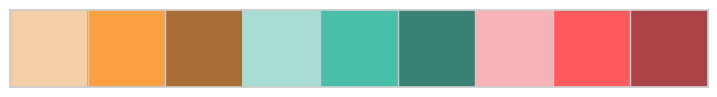

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define 3 main colors
main_colors = ['#fa9f42','#49beaa', '#ff5a5f']  # Blue, Green, Orange

# Create a palette with 4 shades for each main color, from light to dark with more contrast
palette_metrics = []

for color in main_colors:
    # Generate both light and dark palettes for more contrast
    light_shades = sns.light_palette(color, n_colors=6)[2:3]  # Skip the first color to avoid white
    light_shades1 = sns.light_palette(color, n_colors=6)[5:6]  # Skip the first color to avoid white
    dark_shades = sns.dark_palette(color, n_colors=6)[3:4]  # Reverse the order of dark shades    
    palette_metrics += light_shades + light_shades1 + dark_shades

# Display the palette
sns.palplot(palette_metrics)
plt.show()


### Plot layer wise metrics change

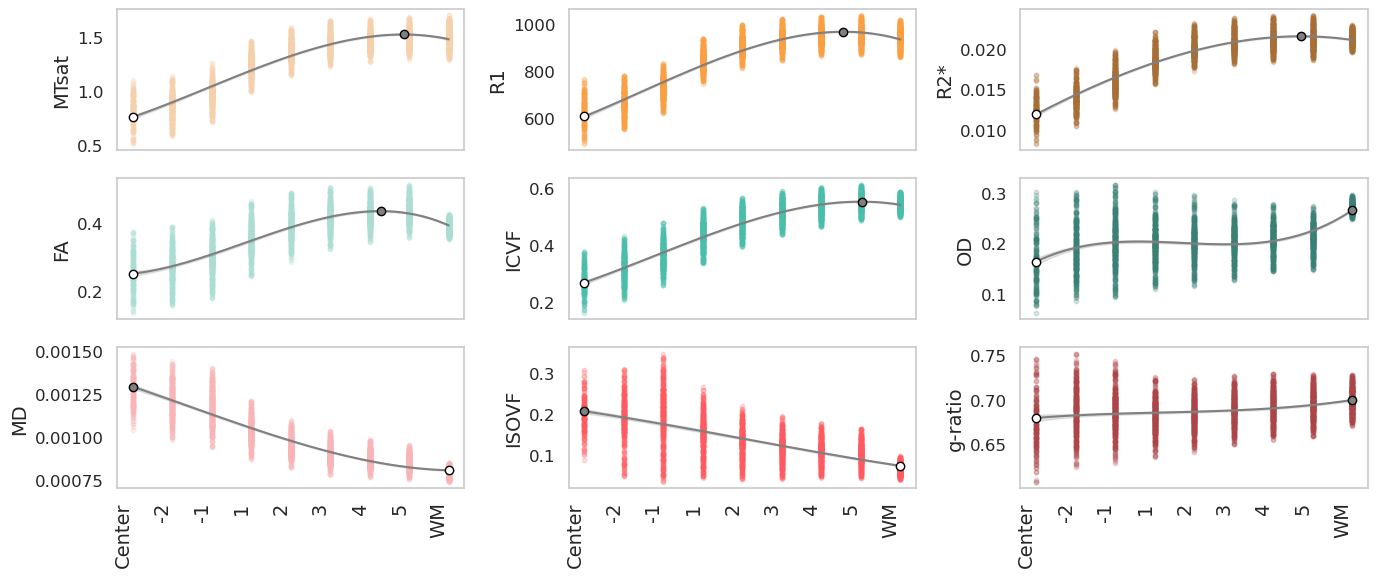

In [60]:
import os
import pickle
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Define groups (layers) and metrics to iterate over
groups_to_plot = {
    'Center': 'WMH_center',
    '-2': 'InnerLayer2',
    '-1': 'InnerLayer1',
    '1': 'Layer1',
    '2': 'Layer2',
    '3': 'Layer3',
    '4': 'Layer4',
    '5': 'Layer5',
    'WM': 'WM_left'
}

metrics_to_plot = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_to_plot2 = ['MT', 'R1', 'R2s', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']  # Updated 'R2*' to 'R2s'
metrics_to_display = ['MTsat', 'R1', 'R2*', 'FA', 'ICVF', 'OD', 'MD', 'ISOVF', 'g-ratio']  # Example metrics

groups_to_plot = ['WMH_center', 'InnerLayer2', 'InnerLayer1', 'Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5', 'WM_left']  # Layers to plot
groups_to_display = ['Center', '-2', '-1', '1', '2', '3', '4', '5', 'WM']  # Layers to plot

# Define colormap for diverging colors
diverging_cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# Nonlinear regression function (Polynomial with Confidence Intervals)
def polynomial_fit_with_ci(x, y, degree=3, n_bootstrap=1000, ci=95):
    poly = PolynomialFeatures(degree)
    x_poly = poly.fit_transform(x.reshape(-1, 1))  # Reshape x to 2D for fitting
    model = LinearRegression()
    model.fit(x_poly, y)
    
    # Generate fitted curve
    x_fit = np.linspace(min(x), max(x), 100).reshape(-1, 1)
    x_fit_poly = poly.transform(x_fit)
    y_fit = model.predict(x_fit_poly)

    # Bootstrap to calculate confidence intervals
    bootstrapped_preds = []
    for _ in range(n_bootstrap):
        # Resample the data with replacement
        x_resampled, y_resampled = resample(x, y)
        x_resampled_poly = poly.fit_transform(x_resampled.reshape(-1, 1))
        model.fit(x_resampled_poly, y_resampled)
        bootstrapped_preds.append(model.predict(x_fit_poly))  # Save predictions on x_fit

    # Convert to numpy array
    bootstrapped_preds = np.array(bootstrapped_preds)

    # Calculate the confidence intervals for the predicted values
    lower_bound = np.percentile(bootstrapped_preds, (100 - ci) / 2, axis=0)
    upper_bound = np.percentile(bootstrapped_preds, 100 - (100 - ci) / 2, axis=0)

    return x_fit, y_fit, lower_bound, upper_bound

# Your metric group map (defines the order you want)
metric_group_map = {
    'MT': 'Myelin-sensitive',
    'R1': 'Myelin-sensitive',
    'R2*': 'Myelin-sensitive',
    'FA': 'Axon-sensitive',
    'ICVF': 'Axon-sensitive',
    'OD': 'Axon-sensitive',
    'MD': 'Fluid-sensitive',
    'ISOVF': 'Fluid-sensitive',
    'g-ratio': 'Composite'
}

# Build palette
metric_order = list(metric_group_map.keys())
palette_metrics_match = {metric: color for metric, color in zip(metric_order, palette_metrics)}

def plot_cvr_metric_with_all_prs(combined_mean_metrics_data_cross_sectionnal, groups_to_plot, metrics_to_plot, degree=3):
    # Plotting settings
    fig, axes = plt.subplots(3, 3, figsize=(14, 6))  # 3x3 grid for plots
    axes = axes.flatten()  # Flatten axes for easier indexing

    # Create a numeric mapping for group labels
    group_label_map = {group_label: idx for idx, group_label in enumerate(groups_to_plot)}

    # Loop through metrics and plot the changes across layers for all PRs
    for i, metric in enumerate(metric_group_map.keys()):  # Only plot the first 9 metrics in the grid
        ax = axes[i]

        # Construct the key for combined_mean_metrics_data_cross_sectionnal using the metric
        metric_key = f'Mean_Metrics_In_{metric}'

        # Get the data for all PRs
        data = {}
        for group_label in groups_to_plot:  # Now iterating over just the group names
            if group_label in combined_mean_metrics_data_cross_sectionnal[metric_key]:
                # Collect values across all PRs for the given mask (layer)
                pr_values = list(combined_mean_metrics_data_cross_sectionnal[metric_key][group_label].values())
                pr_values = [value[0] if isinstance(value, list) else value for value in pr_values]
                
                # Check for non-None, finite values before adding to data
                pr_values = [value for value in pr_values if value is not None and np.isfinite(value)]
                if pr_values:
                    data[group_label] = pr_values  # Store data for each group

        if data:
            # Remove outliers: values > 2 standard deviations from the mean
            for group_label in data:
                group_values = data[group_label]
                mean_value = np.mean(group_values)
                std_dev = np.std(group_values)
                # Remove outliers: greater than 2 SDs
                cleaned_values = [value for value in group_values if np.abs(value - mean_value) <= 2 * std_dev]
                data[group_label] = cleaned_values

            x_data = []
            y_data = []
            
            # Add data for all PRs
            for group_label, group_values in data.items():
                numeric_group_label = group_label_map[group_label]
                x_data.extend([numeric_group_label] * len(group_values))  # Add the corresponding numeric label
                y_data.extend(group_values)  # Add the corresponding group values

            x_data = np.array(x_data, dtype=float)
            y_data = np.array(y_data, dtype=float)
            
            ax.scatter(x_data, y_data, alpha=0.2, color=palette_metrics_match.get(metric, 'grey'), s=10)
            
            # Perform polynomial fit for all data with confidence intervals
            x_fit, y_fit, lower_bound, upper_bound = polynomial_fit_with_ci(x_data, y_data, degree)

            # Plot the fitted polynomial curves for all data
            ax.plot(x_fit, y_fit, color='grey')

            # Plot the confidence intervals
            ax.fill_between(x_fit.flatten(), lower_bound.flatten(), upper_bound.flatten(), color='grey', alpha=0.2)

             # Set labels and title
            ax.set_title(None)
            ax.set_xlabel(None)
            ax.set_ylabel(metrics_to_display[i])
            
            ax.tick_params(axis='y', labelsize=12)
            # Add dots on min and max of the quadratic curve
            ax.scatter(x_fit[np.argmin(y_fit)], np.min(y_fit), color="white", edgecolor="black", label='Min', zorder=30)  # Min point
            ax.scatter(x_fit[np.argmax(y_fit)], np.max(y_fit), color="grey", edgecolor="black", label='Max', zorder=30)  # Max point

            # Set x-axis ticks and labels
            ax.set_xticks(range(len(groups_to_display)))
            ax.set_xticklabels(groups_to_display,  ha='right', rotation=90)
            ax.grid(False)
            # Remove x-axis labels for all but the last row
            if i < 6:
                ax.set_xticklabels([])

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.2)
    
    handles, labels = axes[8].get_legend_handles_labels()  # Get the handles and labels from the last axis
    #fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2, frameon=False)  # Centered below the grid
    # Adjust layout to ensure there's no overlap between the legend and the boxplots
    plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
        'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
    
    # Save the plot
    plot_path = os.path.join(notebook_dir, f'Figures_new/Layer_curves_coloured.png')
    plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Layer_curves_coloured.svg')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
    plt.show()

# Example: Use the function with selected PRs and combined_mean_metrics_data_cross_sectionnal
cvr = 'F3age'  # Change to any variable you want

# Handle NaNs in the CVR variable
final_matched_rows = final_matched_rows.dropna(subset=[cvr])

# Example for the groups_to_plot and metrics_to_plot (you will need to define these as per your data)
metrics_to_plot = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']  # Example metrics

# Call the function with all PRs and the combined_mean_metrics_data_cross_sectionnal data
plot_cvr_metric_with_all_prs(combined_mean_metrics_data_cross_sectionnal, groups_to_plot, metrics_to_plot, degree=3)


### Calculate significant differences

In [62]:
import numpy as np
from statsmodels.stats.multitest import multipletests

# Define groups (layers) and metrics to iterate over
groups_to_plot = {
    'Center': 'WMH_center',
    '-2': 'InnerLayer2',
    '-1': 'InnerLayer1',
    '1': 'Layer1',
    '2': 'Layer2',
    '3': 'Layer3',
    '4': 'Layer4',
    '5': 'Layer5',
    'WM': 'WM_left'
}

metrics_to_plot = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_to_plot1 = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_to_plot2 = ['MT', 'R1', 'R2s', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']  # Updated 'R2*' to 'R2s'

# Initialize a dictionary to store the data for each metric
metric_dfs = {}

# Loop through each metric and layer to extract corresponding values
for metric in metrics_to_plot:
    metric_data = combined_mean_metrics_data_cross_sectionnal.get(f'Mean_Metrics_In_{metric}', {})
    
    # List to store data for this metric
    metric_data_list = []
    
    # Loop through each layer
    for group_label, mask in groups_to_plot.items():
        if mask in metric_data:
            layer_data = metric_data[mask]
            
            # Extract scalar values (if they are lists, take the first value)
            if isinstance(layer_data, dict):
                layer_values = list(layer_data.values())
                layer_values = [value[0] if isinstance(value, list) else value for value in layer_values]
                
                # Create DataFrame for this metric and layer
                df = pd.DataFrame({
                    'PR': list(layer_data.keys()),
                    f'{metric}': layer_values,  # Add metric values
                    'Layer': [group_label] * len(layer_data)  # Add layer label
                })
                
                # Append to list for this metric
                metric_data_list.append(df)
    

    # Concatenate data for the current metric and store in dictionary
    if metric_data_list:
        metric_df = pd.concat(metric_data_list, ignore_index=True)
        metric_dfs[metric] = metric_df

# Merge all metric DataFrames on 'PR' and 'Layer'
final_df = metric_dfs['MT']  # Start with 'MT'

# Merge other metric DataFrames on 'PR' and 'Layer'
for metric, df in metric_dfs.items():
    if metric != 'MT':
        final_df = pd.merge(final_df, df[['PR', 'Layer', metric]], on=['PR', 'Layer'], how='inner')

# Merge with final_matched_rows for additional info
final_df = pd.merge(final_df, final_matched_rows, on=['PR'], how='inner')

# Ensure the 'Layer' column is ordered correctly
final_df['Layer'] = pd.Categorical(final_df['Layer'], categories=groups_to_plot.keys(), ordered=True)

# Rename columns for consistency (e.g., 'g-ratio' -> 'g_ratio', 'R2*' -> 'R2s')
final_df.rename(columns={'F3age': 'Age','g-ratio': 'g_ratio', 'R2*': 'R2s'}, inplace=True)

# Z-score standardization of 'F3age' and all metrics
scaler = StandardScaler()

# List of columns to standardize
columns_to_standardize = ['Age'] + metrics_to_plot2

# Apply standardization
final_df[columns_to_standardize] = scaler.fit_transform(final_df[columns_to_standardize])

# Initialize dictionaries to store betas and p-values
beta_dict = {metric: {} for metric in metrics_to_plot2}
pvalue_dict = {metric: {} for metric in metrics_to_plot2}

# Loop through each metric and layer
for metric in metrics_to_plot2:
    for layer in final_df['Layer'].cat.categories:
        df_layer = final_df[final_df['Layer'] == layer].dropna(subset=['Age', metric])
        
        if len(df_layer) < 3:
            beta_dict[metric][layer] = np.nan
            pvalue_dict[metric][layer] = np.nan
            continue
        
        model = smf.ols(f'{metric} ~ Age', data=df_layer).fit()
        beta_dict[metric][layer] = model.params['Age']
        pvalue_dict[metric][layer] = model.pvalues['Age']

# Flatten p-values for FDR correction
flat_pvals = [pvalue_dict[metric][layer] 
              for metric in metrics_to_plot2 
              for layer in final_df['Layer'].cat.categories]

# Remove nans to perform correction
valid_pvals = [p for p in flat_pvals if not np.isnan(p)]
_, pvals_fdr_corrected, _, _ = multipletests(valid_pvals, method='fdr_bh')

# Reassign FDR-corrected p-values to new dict
pvalue_dict_fdr = {metric: {} for metric in metrics_to_plot2}
idx = 0
for metric in metrics_to_plot2:
    for layer in final_df['Layer'].cat.categories:
        p = pvalue_dict[metric][layer]
        if np.isnan(p):
            pvalue_dict_fdr[metric][layer] = np.nan
        else:
            pvalue_dict_fdr[metric][layer] = pvals_fdr_corrected[idx]
            idx += 1


### Display value per layer

In [63]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

# Store results
model_results = []

# Loop through metrics
for metric in metrics_to_plot2:
    df_metric = final_df.dropna(subset=[metric, 'Layer']).copy()
    
    if df_metric.empty:
        continue
    
    # Fit model with Center as reference
    model = smf.ols(f'{metric} ~ C(Layer)', data=df_metric).fit()
    
    # Extract coefficients and p-values for each layer vs Center
    for layer in final_df['Layer'].cat.categories:
        if layer == 'Center':
            continue  # Center is reference
        
        coef = model.params.get(f'C(Layer)[T.{layer}]', np.nan)
        pval = model.pvalues.get(f'C(Layer)[T.{layer}]', np.nan)
        
        model_results.append({
            'Metric': metric,
            'Layer': layer,
            'Beta': coef,
            'p_value': pval
        })

# Convert to DataFrame
model_df = pd.DataFrame(model_results)

# Apply FDR correction
model_df['p_fdr'] = np.nan
if model_df['p_value'].notnull().any():
    _, pvals_fdr, _, _ = multipletests(model_df['p_value'].dropna(), method='fdr_bh')
    model_df.loc[model_df['p_value'].notnull(), 'p_fdr'] = pvals_fdr

# Pivot for display
pivot_beta = model_df.pivot(index='Metric', columns='Layer', values='Beta')
pivot_p_fdr = model_df.pivot(index='Metric', columns='Layer', values='p_fdr')

# Show results
print("\nBetas (Layer vs Center):")
print(pivot_beta)

print("\nFDR-corrected p-values (Layer vs Center):")
print(pivot_p_fdr)



Betas (Layer vs Center):
Layer          -1        -2         1         2         3         4         5  \
Metric                                                                          
FA       0.569526  0.223609  1.331049  1.823933  2.126823  2.283256  2.343627   
ICVF     0.926634  0.425875  1.641315  2.117940  2.428716  2.611891  2.715839   
ISOVF    0.370883  0.070572 -0.466822 -0.926553 -1.165951 -1.315384 -1.412522   
MD      -0.430933 -0.266329 -1.291565 -1.787715 -2.067329 -2.233869 -2.333519   
MT       0.679705  0.281737  1.622512  2.147029  2.375782  2.475111  2.522720   
OD       0.826987  0.474925  0.796792  0.828214  0.883975  0.957533  1.050254   
R1       0.725926  0.291732  1.701898  2.222932  2.438147  2.523400  2.558481   
R2s      0.921868  0.365680  1.766744  2.225424  2.417070  2.488599  2.518627   
g_ratio  0.358315  0.307711  0.401062  0.550186  0.786271  0.959001  1.067372   

Layer          WM  
Metric             
FA       1.674644  
ICVF     2.521379  
IS

### Plot derivative per layer

/tmp/ipykernel_4021517/1913995313.py:183: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_4021517/1913995313.py:183: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_4021517/1913995313.py:183: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


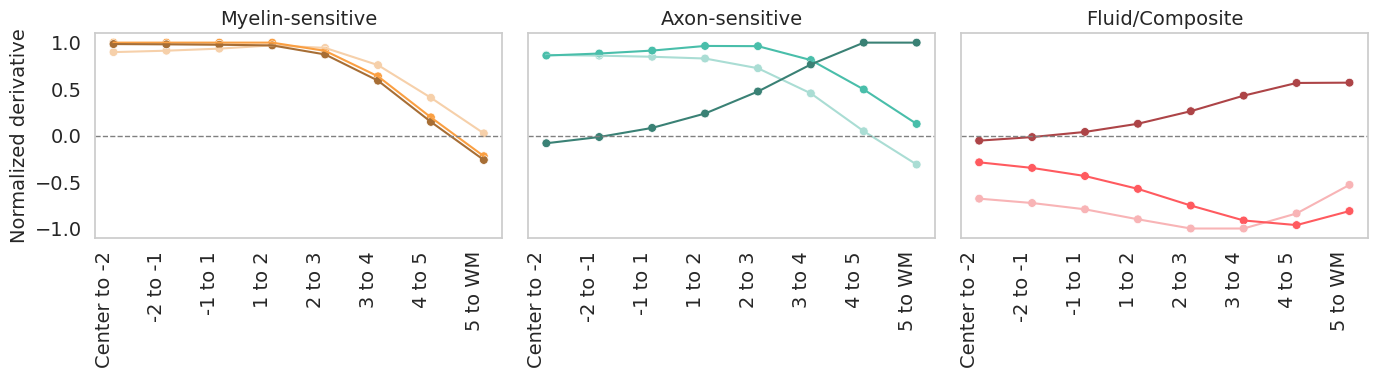

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Example numeric group map (adjust as needed)
group_label_map = {
    'WMH_center': 0,
    'InnerLayer2': 1,
    'InnerLayer1': 2,
    'Layer1': 3,
    'Layer2': 4,
    'Layer3': 5,
    'Layer4': 6,
    'Layer5': 7,
    'WM_left': 8
}

groups_to_plot = ['WMH_center', 'InnerLayer2', 'InnerLayer1', 'Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5', 'WM_left']  # Layers to plot

deriv_results = []

for metric in metrics_to_plot:
    x_data = []
    y_data = []
    
    metric_key = f'Mean_Metrics_In_{metric}'
    for group_label in groups_to_plot:
        if group_label in combined_mean_metrics_data_cross_sectionnal[metric_key]:
            pr_values = list(combined_mean_metrics_data_cross_sectionnal[metric_key][group_label].values())

            pr_values = [v[0] if isinstance(v, list) else v for v in pr_values]
            pr_values = [v for v in pr_values if v is not None and np.isfinite(v)]
            
            numeric_group = group_label_map[group_label]
            x_data.extend([numeric_group] * len(pr_values))
            y_data.extend(pr_values)
    
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    
    # Standardize y_data (mean=0, std=1)
    y_mean = y_data.mean()
    y_std = y_data.std()
    if y_std == 0:
        continue  # Skip metrics with no variability
    y_data_std = (y_data - y_mean) / y_std
    
    # Fit polynomial
    poly = PolynomialFeatures(2)
    X_poly = poly.fit_transform(x_data.reshape(-1,1))
    model = LinearRegression()
    model.fit(X_poly, y_data_std)
    coefs = model.coef_
    intercept = model.intercept_
    
    # Derivative: dy/dx = 2*a*x + b
    a = coefs[2]
    b = coefs[1]
    
    # Evaluate derivative at segment midpoints
    segment_points = {
        'Center_to_-2': (group_label_map['WMH_center'] + group_label_map['InnerLayer2']) / 2,
        '-2_to_-1': (group_label_map['InnerLayer2'] + group_label_map['InnerLayer1']) / 2,
        '-1_to_1': (group_label_map['InnerLayer1'] + group_label_map['Layer1']) / 2,
        '1_to_2': (group_label_map['Layer1'] + group_label_map['Layer2']) / 2,
        '2_to_3': (group_label_map['Layer2'] + group_label_map['Layer3']) / 2,
        '3_to_4': (group_label_map['Layer3'] + group_label_map['Layer4']) / 2,
        '4_to_5': (group_label_map['Layer4'] + group_label_map['Layer5']) / 2,
        '5_to_WM': (group_label_map['Layer5'] + group_label_map['WM_left']) / 2
    }
    
    for seg, x_val in segment_points.items():
        dydx = 2 * a * x_val + b
        deriv_results.append({'Metric': metric, 'Segment': seg, 'AbsDerivative': (dydx)})

# Convert to DataFrame
deriv_df = pd.DataFrame(deriv_results)

# Pivot for easier reading
pivot_deriv = deriv_df.pivot(index='Metric', columns='Segment', values='AbsDerivative')

# Your segment order
segment_order = list(segment_points.keys())

# Ensure pivot_deriv has segments in correct order
pivot_deriv = pivot_deriv[segment_order]

# Normalize per segment (column-wise)
pivot_norm = pivot_deriv.apply(lambda col: col / col.abs().max(), axis=0)
# Melt for plotting
plot_df = pivot_norm.reset_index().melt(id_vars='Metric', var_name='Segment', value_name='NormalizedAbsDerivative')

# Set font sizes globally
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

# If you're working with the derivative DataFrame (e.g., plot_df or deriv_df)
# Add a new column with the group
plot_df['Group'] = plot_df['Metric'].map(metric_group_map)

# Your mapping
metric_group_map = {
    'MT': 'Myelin-sensitive',
    'R1': 'Myelin-sensitive',
    'R2*': 'Myelin-sensitive',
    'FA': 'Axon-sensitive',
    'ICVF': 'Axon-sensitive',
    'OD': 'Axon-sensitive',
    'MD': 'Fluid-sensitive',
    'ISOVF': 'Fluid-sensitive',
    'g-ratio': 'Composite'
}


# Group combined
plot_df['GroupCombined'] = plot_df['Group'].replace({
    'Composite': 'Fluid/Composite',
    'Fluid-sensitive': 'Fluid/Composite'
})

# Group order
group_order = ['Myelin-sensitive', 'Axon-sensitive', 'Fluid/Composite']

# Metric order list
metric_list = list(metric_group_map.keys())

# Per-subplot palettes
palette_1 = {metric_list[i]: palette_metrics[i] for i in range(3)}
palette_2 = {metric_list[i]: palette_metrics[i] for i in range(3, 6)}
palette_3 = {metric_list[i]: palette_metrics[i] for i in range(6, 9)}

palette_by_group = {
    'Myelin-sensitive': palette_1,
    'Axon-sensitive': palette_2,
    'Fluid/Composite': palette_3
}

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, group in zip(axes, group_order):
    df_sub = plot_df[plot_df['GroupCombined'] == group]
    group_palette = palette_by_group[group]
    hue_order = list(group_palette.keys())
    
    # Lineplot without markers
    sns.lineplot(
        data=df_sub,
        x='Segment',
        y='NormalizedAbsDerivative',
        hue='Metric',
        palette=group_palette,
        hue_order=hue_order,
        legend=False,
        ax=ax
    )
    
    # Scatterplot for markers
    sns.scatterplot(
        data=df_sub,
        x='Segment',
        y='NormalizedAbsDerivative',
        hue='Metric',
        palette=group_palette,
        hue_order=hue_order,
        s=40,
        legend=False,
        ax=ax
    )
    
    ax.set_title(group)
    ax.set_xlabel(None)
    ax.set_ylabel('Normalized derivative' if ax == axes[0] else None)
    ax.set_xticklabels(
        [label.get_text().replace('_', ' ') for label in ax.get_xticklabels()],
        rotation=90, ha='right'
    )
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)


plt.tight_layout()

for ax, group in zip(axes, group_order):

    # Add legend below each subplot
    handles, labels = ax.get_legend_handles_labels()
    ax.grid(False)
    #ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.7), ncol=3, frameon=False)
    

# Save the plot
plot_path = os.path.join(notebook_dir, f'Figures_new/Derivative_metric_layers.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Derivative_metric_layers.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()


### Plot metric coloured caption

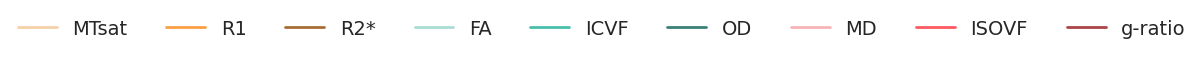

In [64]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Flatten palette_by_group into a single dict {metric: color}
flat_palette = {}
for group in palette_by_group:
    flat_palette.update(palette_by_group[group])

# Prepare the figure
fig_legend, ax_legend = plt.subplots(figsize=(14, 0.5))

# Build handles + labels (replace MT -> MTsat)
handles = []
labels = []
for metric in flat_palette.keys():
    display_label = 'MTsat' if metric == 'MT' else metric
    handles.append(Line2D([0], [0], color=flat_palette[metric], lw=2, label=display_label))
    labels.append(display_label)

# Create the legend
ax_legend.legend(
    handles,
    labels,
    loc='center',
    ncol=len(labels),  # All in one row
    frameon=False
)

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12
})

# Remove axes
ax_legend.axis('off')

# Save
plot_path = os.path.join(notebook_dir, f'Figures_new/Derivative_metric_layers_legend.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Derivative_metric_layers_legend.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()


### Plot age effect per layer

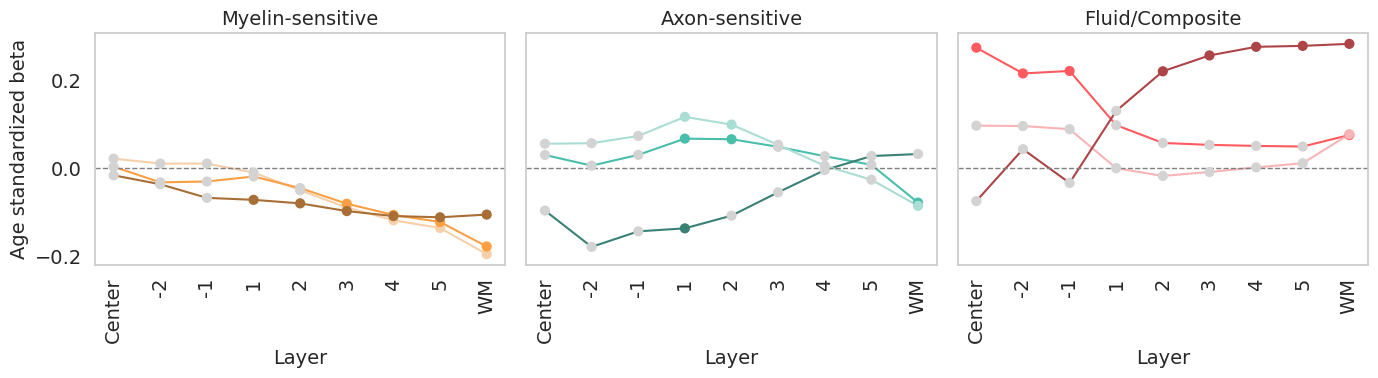

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Your mapping
metric_group_map_modif = {
    'MT': 'Myelin-sensitive',
    'R1': 'Myelin-sensitive',
    'R2s': 'Myelin-sensitive',
    'FA': 'Axon-sensitive',
    'ICVF': 'Axon-sensitive',
    'OD': 'Axon-sensitive',
    'MD': 'Fluid-sensitive',
    'ISOVF': 'Fluid-sensitive',
    'g_ratio': 'Composite'
}



# Build palette
metric_order = list(metric_group_map_modif.keys())
palette_metrics_match_1 = {metric: color for metric, color in zip(metric_order, palette_metrics)}

# Convert beta_dict to long-form DataFrame
beta_records = []

for metric, layer_betas in beta_dict.items():
    for layer, beta in layer_betas.items():
        beta_records.append({
            'Metric': metric,
            'Layer': layer,
            'Beta': beta
        })

# Create DataFrame
beta_df_long = pd.DataFrame(beta_records)

# Ensure 'Layer' is categorical with proper order (optional, if you want ordered plotting)
layer_order = final_df['Layer'].cat.categories.tolist()
beta_df_long['Layer'] = pd.Categorical(beta_df_long['Layer'], categories=layer_order, ordered=True)

# Add group column
beta_df_long['Group'] = beta_df_long['Metric'].map(metric_group_map_modif)

# Group combined
beta_df_long['GroupCombined'] = beta_df_long['Group'].replace({
    'Composite': 'Fluid/Composite',
    'Fluid-sensitive': 'Fluid/Composite'
})

# Create DataFrame of pvalue_dict_fdr for merge
pval_records = []
for metric, layers in pvalue_dict_fdr.items():
    for layer, pval in layers.items():
        pval_records.append({
            'Metric': metric,
            'Layer': layer,
            'PvalFDR': pval
        })
pval_df = pd.DataFrame(pval_records)

# Merge p-values into beta_df_long
beta_df_long = beta_df_long.merge(pval_df, on=['Metric', 'Layer'])

# Ensure layer order
layer_order = final_df['Layer'].cat.categories.tolist()
beta_df_long['Layer'] = pd.Categorical(beta_df_long['Layer'], categories=layer_order, ordered=True)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

group_order = ['Myelin-sensitive', 'Axon-sensitive', 'Fluid/Composite']

for ax, group in zip(axes, group_order):
    df_sub = beta_df_long[beta_df_long['GroupCombined'] == group]
    metrics_in_group = df_sub['Metric'].unique()
    group_palette = {metric: palette_metrics_match_1[metric] for metric in metrics_in_group}
    
    # Plot lines
    sns.lineplot(
        data=df_sub,
        x='Layer',
        y='Beta',
        hue='Metric',
        marker=None,
        palette=group_palette,
        legend=False,
        ax=ax
    )
    
    # Plot dots: color if significant, gray otherwise
    for metric in metrics_in_group:
        df_metric = df_sub[df_sub['Metric'] == metric]
        colors = [
            group_palette[metric] if p < 0.05 else 'lightgray'
            for p in df_metric['PvalFDR']
        ]
        ax.scatter(
            df_metric['Layer'],
            df_metric['Beta'],
            color=colors,
            s=40, 
            zorder=10
        )
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.grid(False)
    ax.set_title(group)
    ax.set_xlabel('Layer')
    if ax == axes[0]:
        ax.set_ylabel('Age standardized beta')
    else:
        ax.set_ylabel(None)
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()

# Save
plot_path = os.path.join(notebook_dir, f'Figures_new/Age_beta_metric_layers.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Age_beta_metric_layers.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()


## Fig 6 - PLS analyses

### Install package

In [115]:
pip install "git+https://github.com/rmarkello/pyls.git"

  Cloning https://github.com/rmarkello/pyls.git to /tmp/pip-req-build-lxbl3oas
  Running command git clone --filter=blob:none --quiet https://github.com/rmarkello/pyls.git /tmp/pip-req-build-lxbl3oas
  Resolved https://github.com/rmarkello/pyls.git to commit d8a19d564cc5804249527b68c937df3a5fd8c7cc
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


### Run PLS WMH + NAWM vs CVR

In [116]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os
from pyls import behavioral_pls

# Function to create region DataFrame
def create_region_df(region_name):
    all_metrics = list(combined_mean_metrics_data_cross_sectionnal.keys())
    data_per_pr = {}

    for metric in all_metrics:
        metric_data = combined_mean_metrics_data_cross_sectionnal[metric].get(region_name, {})
        for pr, values in metric_data.items():
            if pr not in data_per_pr:
                data_per_pr[pr] = {}
            data_per_pr[pr][metric] = values[0] if values else None

    region_df = pd.DataFrame.from_dict(data_per_pr, orient='index')
    region_df.index.name = 'PR'
    region_df.reset_index(inplace=True)
    return region_df

# === PARAMETERS ===
cvr_vars = [ 'F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch', 
             'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
            'F3conso_hebdo', 'F3cafuse', 
             'F3equiv', 'F3hba1c', 'F3TSH', 'F3FT4', 'F3hb', 'F3age']

# === Build region_dfs ===
print("\nCreating DataFrames for WMH and NAWM")
wmh_df = create_region_df('WMH')
nawm_df = create_region_df('NAWM')

# === VALID PRs ===
valid_prs_wmh = wmh_df[wmh_df.drop(columns='PR').notna().any(axis=1)]['PR']
valid_prs_nawm = nawm_df[nawm_df.drop(columns='PR').notna().any(axis=1)]['PR']
valid_prs_cvr = final_matched_rows[final_matched_rows[cvr_vars].notna().any(axis=1)]['PR']

# === Intersection ===
common_prs = set(valid_prs_wmh).intersection(set(valid_prs_nawm)).intersection(set(valid_prs_cvr))
print(f"Common PRs: {len(common_prs)}")

# === Filter DataFrames ===
filtered_wmh = wmh_df[wmh_df['PR'].isin(common_prs)].copy()
filtered_nawm = nawm_df[wmh_df['PR'].isin(common_prs)].copy()  # Note: force same PR order as wmh_df
filtered_cvr = final_matched_rows[final_matched_rows['PR'].isin(common_prs)].copy()

# === Reorder filtered_cvr to match filtered_wmh['PR']
wmh_prs = filtered_wmh['PR'].tolist()
cvr_prs = filtered_cvr['PR'].tolist()

# Safe reorder
common_ordered_prs = [pr for pr in wmh_prs if pr in cvr_prs]
filtered_cvr = filtered_cvr.set_index('PR').loc[common_ordered_prs].reset_index()

# === Prepare metrics dataframe (concatenate WMH and NAWM metrics) ===
metrics_wmh = filtered_wmh.reset_index(drop=True).drop(columns='PR')
metrics_nawm = filtered_nawm.reset_index(drop=True).drop(columns='PR')

# Rename columns
metrics_wmh = metrics_wmh.rename(columns={col: f'WMH_{col.replace("Mean_Metrics_In_", "")}' for col in metrics_wmh.columns})
metrics_nawm = metrics_nawm.rename(columns={col: f'NAWM_{col.replace("Mean_Metrics_In_", "")}' for col in metrics_nawm.columns})

# Concatenate along columns
metrics_combined = pd.concat([metrics_wmh, metrics_nawm], axis=1)

# === Prepare CVR dataframe ===
cvr_vars_with_pr = ['PR'] + cvr_vars
cvr_df_common = filtered_cvr[cvr_vars_with_pr].reset_index(drop=True)
cvr_df_common = cvr_df_common.set_index('PR').loc[filtered_wmh['PR']].reset_index()

cvr_df_common_no_pr = cvr_df_common.drop(columns='PR')
cvr_df_common_no_pr = cvr_df_common_no_pr.rename(columns={col: col[2:] if col.startswith('F3') else col for col in cvr_df_common_no_pr.columns})

# === Handle NaNs ===
if metrics_combined.isnull().values.any() or cvr_df_common_no_pr.isnull().values.any():
    print("NaN values detected → filling with column mean.")
    metrics_combined = metrics_combined.fillna(metrics_combined.mean())
    cvr_df_common_no_pr = cvr_df_common_no_pr.fillna(cvr_df_common_no_pr.mean())

# === Standardize ===
scaler = StandardScaler()
cvr_scaled = scaler.fit_transform(cvr_df_common_no_pr)
qmri_scaled = scaler.fit_transform(metrics_combined)

# === Output directory ===
output_dir = f'/home/a0342481/Analyses/PLS_WMH_NAWM_combined'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# === Run PLS ===
print(f"Running PLS → X shape: {qmri_scaled.shape}, Y shape: {cvr_scaled.shape}")
n_perm = 10000
n_boot = 10000
n_proc = 10  # you can test 1 if needed

bpls = behavioral_pls(qmri_scaled, cvr_scaled, n_perm=n_perm, n_boot=n_boot, seed=123, n_proc=n_proc)

# === Save results ===
np.savetxt(f'{output_dir}/x_weights.csv', bpls['x_weights'], delimiter=',')
np.savetxt(f'{output_dir}/y_weights.csv', bpls['y_weights'], delimiter=',')
np.savetxt(f'{output_dir}/x_scores.csv', bpls['x_scores'], delimiter=',')
np.savetxt(f'{output_dir}/y_scores.csv', bpls['y_scores'], delimiter=',')
np.savetxt(f'{output_dir}/y_loadings.csv', bpls['y_loadings'], delimiter=',')
np.savetxt(f'{output_dir}/sinvals.csv', bpls['singvals'], delimiter=',')
np.savetxt(f'{output_dir}/varexp.csv', bpls['varexp'], delimiter=',')
np.savetxt(f'{output_dir}/permres_pvals.csv', bpls['permres']['pvals'], delimiter=',')
np.savetxt(f'{output_dir}/permres_permsamples.csv', bpls['permres']['permsamples'], delimiter=',')
np.savetxt(f'{output_dir}/bootres_x_weights_normed.csv', bpls['bootres']['x_weights_normed'], delimiter=',')
np.savetxt(f'{output_dir}/bootres_x_weights_stderr.csv', bpls['bootres']['x_weights_stderr'], delimiter=',')
np.savetxt(f'{output_dir}/bootres_bootsamples.csv', bpls['bootres']['bootsamples'], delimiter=',')
np.savetxt(f'{output_dir}/bootres_y_loadings.csv', bpls['bootres']['y_loadings'], delimiter=',')

os.makedirs(f'{output_dir}/y_loadings_ci', exist_ok=True)
for i in range(bpls['bootres']['y_loadings_ci'].shape[0]):
    np.savetxt(f'{output_dir}/y_loadings_ci/bootres_y_loadings_ci_{i}.csv', bpls['bootres']['y_loadings_ci'][i], delimiter=',')

os.makedirs(f'{output_dir}/y_loadings_boot', exist_ok=True)
for i in range(bpls['bootres']['y_loadings_boot'].shape[0]):
    np.savetxt(f'{output_dir}/y_loadings_boot/bootres_y_loadings_boot_{i}.csv', bpls['bootres']['y_loadings_boot'][i], delimiter=',')

np.savetxt(f'{output_dir}/inputs_X.csv', bpls['inputs']['X'], delimiter=',')
np.savetxt(f'{output_dir}/inputs_Y.csv', bpls['inputs']['Y'], delimiter=',')

print(f"PLS run and save DONE for WMH + NAWM combined ✅")



Creating DataFrames for WMH and NAWM
Common PRs: 200
NaN values detected → filling with column mean.
Running PLS → X shape: (200, 18), Y shape: (200, 20)


KeyboardInterrupt: 

### Print variance and pvalues

In [ ]:
import pandas as pd
import numpy as np
import os

# === Load PLS results for WMH + NAWM combined ===

# Define the directory where PLS results are saved
input_dir = '/home/a0342481/Analyses/PLS_WMH_NAWM_combined'
output_vis = f"{input_dir}/visualization"

# Check directory exists
if not os.path.exists(input_dir):
    raise RuntimeError(f"Input directory {input_dir} does not exist!")

print(f"\n=== Loading PLS results for WMH + NAWM combined ===")

# Load PLS outputs
x_scores = pd.read_csv(f"{input_dir}/x_scores.csv", header=None)
y_scores = pd.read_csv(f"{input_dir}/y_scores.csv", header=None)
bootres_bootsamples = pd.read_csv(f"{input_dir}/bootres_bootsamples.csv", header=None)
bootres_x_weights_normed = pd.read_csv(f"{input_dir}/bootres_x_weights_normed.csv", header=None)
bootres_x_weights_stderr = pd.read_csv(f"{input_dir}/bootres_x_weights_stderr.csv", header=None)
permres_permsamples = pd.read_csv(f"{input_dir}/permres_permsamples.csv", header=None)
permres_pvals = pd.read_csv(f"{input_dir}/permres_pvals.csv", header=None)
varexp = pd.read_csv(f"{input_dir}/varexp.csv", header=None)
x_weights = pd.read_csv(f"{input_dir}/x_weights.csv", header=None)
y_loadings = pd.read_csv(f"{input_dir}/y_loadings.csv", header=None)

# === Sanity check: print shapes ===
print("x_scores shape: ", x_scores.shape)
print("y_scores shape: ", y_scores.shape)
print("bootres_bootsamples shape: ", bootres_bootsamples.shape)
print("bootres_x_weights_normed shape: ", bootres_x_weights_normed.shape)
print("bootres_x_weights_stderr shape: ", bootres_x_weights_stderr.shape)
print("permres_permsamples shape: ", permres_permsamples.shape)
print("permres_pvals shape: ", permres_pvals.shape)
print("varexp shape: ", varexp.shape)
print("x_weights shape: ", x_weights.shape)
print("y_loadings shape: ", y_loadings.shape)

# === Print key outputs ===
print("\npermres_pvals:")
print(permres_pvals)

# Also print number of significant LVs
n_significant_lvs = (permres_pvals.values.flatten() < 0.05).sum()
print(f"\n→ Number of significant LVs (p < 0.05): {n_significant_lvs}")

print("\nvarexp:")
print(varexp)



=== Loading PLS results for WMH + NAWM combined ===
x_scores shape:  (200, 18)
y_scores shape:  (200, 18)
bootres_bootsamples shape:  (200, 10000)
bootres_x_weights_normed shape:  (18, 18)
bootres_x_weights_stderr shape:  (18, 18)
permres_permsamples shape:  (200, 10000)
permres_pvals shape:  (18, 1)
varexp shape:  (18, 1)
x_weights shape:  (18, 18)
y_loadings shape:  (20, 18)

permres_pvals:
           0
0   0.000100
1   0.009499
2   0.006499
3   0.261774
4   0.143986
5   0.557944
6   0.878712
7   0.900410
8   0.843516
9   0.993301
10  0.999700
11  1.000000
12  1.000000
13  1.000000
14  1.000000
15  1.000000
16  1.000000
17  1.000000

→ Number of significant LVs (p < 0.05): 3

varexp:
           0
0   0.609214
1   0.163960
2   0.071144
3   0.046665
4   0.037986
5   0.028464
6   0.014064
7   0.010336
8   0.008356
9   0.004241
10  0.002149
11  0.001582
12  0.000942
13  0.000509
14  0.000187
15  0.000123
16  0.000062
17  0.000015


### Plot results


=== Plotting behavioural loadings and BSR for LV1 side by side ===

→ Plotting LV 1 (p=0.0001)


/tmp/ipykernel_4021517/1028873786.py:162: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_yticklabels([var.replace('_', ' ') for var in df_bsr['Metric']])  # Remove underscores from labels


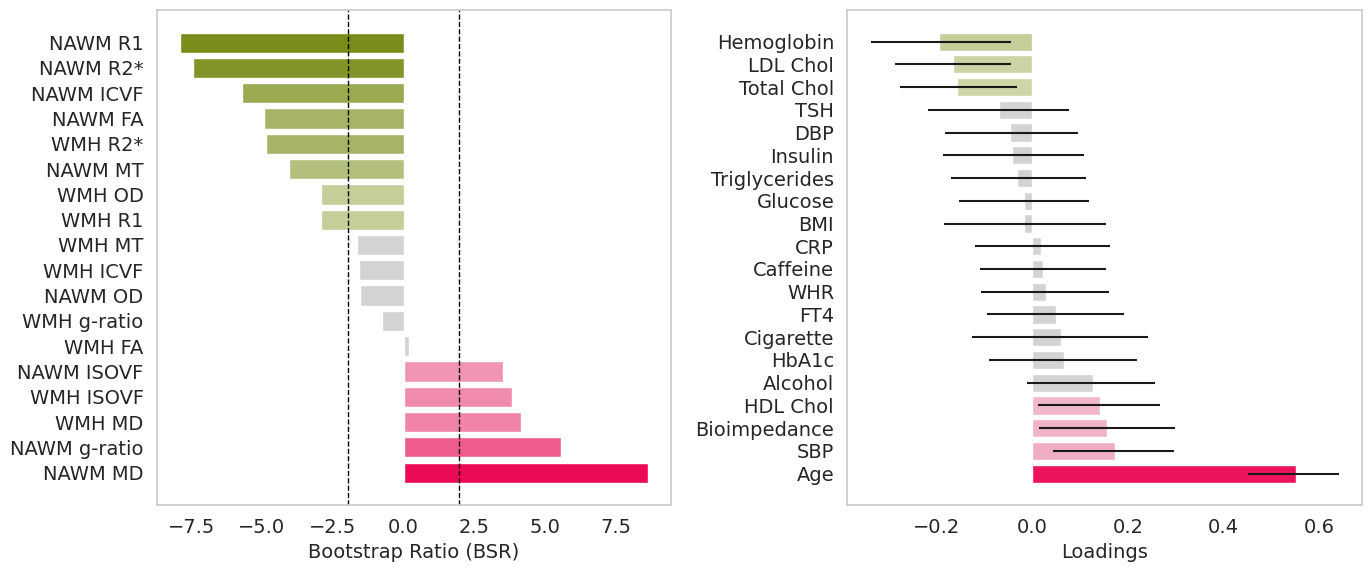

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors

# Function to categorize variable names
def categorize_variable(variable_name):
    if "_x" in variable_name.lower():
        return 'x'
    elif "_y" in variable_name.lower():
        return 'y'
    else:
        return 'other'

# === CVR variables used in your run ===
cvr_vars = ['F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch', 
             'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
             'F3conso_hebdo', 'F3cafuse', 
             'F3equiv', 'F3hba1c', 'F3TSH', 'F3FT4', 'F3hb','F3age']

cvr_vars_display = [
    'SBP', 'DBP', 'BMI', 'Bioimpedance', 
    'HDL Chol', 'LDL Chol', 'WHR', 'Total Chol', 'Triglycerides', 
    'Glucose', 'Insulin', 'CRP', 'Alcohol', 
    'Caffeine', 'Cigarette', 'HbA1c', 'TSH', 
    'FT4', 'Hemoglobin', 'Age'
]

# Set the color map (centered at 0, with the range between -0.4 and 0.4)
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# === Directory where PLS was saved ===
input_dir = '/home/a0342481/Analyses/PLS_WMH_NAWM_combined/'
output_dir = input_dir

print(f"\n=== Plotting behavioural loadings and BSR for LV1 side by side ===")

# Load BSR values
bsr_values = np.loadtxt(f'{output_dir}/bootres_x_weights_normed.csv', delimiter=',')  # shape: (num metrics, num LVs)

# Load X inputs → to get number of columns
X_inputs = pd.read_csv(f'{output_dir}/inputs_X.csv', header=None)
num_rows = X_inputs.shape[0]
num_cols = X_inputs.shape[1]

# Define your metric names → WMH first, then NAWM
# You used metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']
base_metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']
metric_names = [f'WMH_{m}' for m in base_metrics] + [f'NAWM_{m}' for m in base_metrics]

# Sanity check:
if len(metric_names) != bsr_values.shape[0]:
    print(f"Warning: number of metric names ({len(metric_names)}) does not match number of BSR rows ({bsr_values.shape[0]})")

# Parameters
pval = 0.05

# Load necessary files
permres_pvals = np.loadtxt(f"{output_dir}/permres_pvals.csv", delimiter=',')
y_loadings = np.loadtxt(f"{output_dir}/y_loadings.csv", delimiter=',')

# Create output dir if needed
os.makedirs(f"{output_dir}/behavioural_loadings/", exist_ok=True)

# Define a diverging color palette centered around 0 (using seaborn)
diverging_cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Plot the first 2 LVs (LV1 and LV2) side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Create a figure with 2 subplots side by side

# Loop over the LVs (just for LV1)
lv_idx = 0
if permres_pvals[lv_idx] <= pval:
    print(f"\n→ Plotting LV {lv_idx+1} (p={permres_pvals[lv_idx]:.4f})")

    y_load = y_loadings[:, lv_idx]
    loading_info = []

    # Loop over behavioral variables
    for j, var in enumerate(cvr_vars_display):
        ci_file_path = f"{input_dir}/y_loadings_ci/bootres_y_loadings_ci_{j}.csv"
        if os.path.exists(ci_file_path):
            y_loadings_ci = np.loadtxt(ci_file_path, delimiter=",")
            ci_pair = y_loadings_ci[lv_idx]  # For LV i
            loading_value = y_load[j]
            loading_info.append({
                "variable": var,
                "loading": loading_value,
                "ci_low": ci_pair[0],
                "ci_high": ci_pair[1],
                "category": categorize_variable(var)
            })
        else:
            print(f"Warning: CI file not found for behavior {j}: {ci_file_path}")
            loading_info.append({
                "variable": var,
                "loading": y_load[j],
                "ci_low": y_load[j],
                "ci_high": y_load[j],
                "category": categorize_variable(var)
            })

    # Sort variables by loading
    loading_info_sorted = sorted(loading_info, key=lambda x: x["loading"])

    # Prepare data for plotting
    variables = [item["variable"] for item in loading_info_sorted]
    y_load_sorted = np.array([item["loading"] for item in loading_info_sorted])
    x_error = np.array([
        [abs(item["loading"] - item["ci_low"]), abs(item["ci_high"] - item["loading"])]
        for item in loading_info_sorted
    ]).T
    categories = [item["category"] for item in loading_info_sorted]

    norm = mcolors.Normalize(vmin=-0.6, vmax=0.6)

    # Define colors using the diverging palette for significant variables
    colors = []
    for item in loading_info_sorted:
        a = item["ci_low"]
        b = item["ci_high"]
        if a * b >= 0:  # Significant if CI doesn't cross zero
            # Significant: use diverging color palette based on loading value
            normalized_loading = (item["loading"] - np.min(y_load_sorted)) / (np.max(y_load_sorted) - np.min(y_load_sorted))
            colors.append(cmap(norm(item["loading"])))  # Normalize loading to the colormap
        else:
            colors.append("lightgray")  # Non-significant bars in light grey

    # Plot Behavioral Loadings for LV1 (on the second subplot)
    axes[1].barh(np.arange(len(variables)), y_load_sorted, xerr=x_error, align='center', color=colors)
    axes[1].set_yticks(np.arange(len(variables)))
    axes[1].set_yticklabels([var.replace('_', ' ') for var in variables])  # Remove underscores from labels
    axes[1].invert_yaxis()  # Invert y-axis to have the largest loading at the top
    axes[1].set_xlabel('Loadings')
    axes[1].set_title(None)
    axes[1].grid(False)

    # BSR Plot for LV1 (on the first subplot)
    bsr_lv = bsr_values[:, lv_idx]
    df_bsr = pd.DataFrame({
        'Metric': metric_names,
        'BSR': bsr_lv
    })

    # Sort metrics by BSR (descending → positive to negative)
    df_bsr = df_bsr.sort_values('BSR', ascending=False)
    norm = mcolors.Normalize(vmin=-9, vmax=9)

    # Plot BSR
    bars = axes[0].barh(df_bsr['Metric'], df_bsr['BSR'], color=[cmap(norm(b)) if b < -1.96 or b > 1.96 else 'lightgray' for b in df_bsr['BSR']])

    # Threshold lines
    axes[0].axvline(x=1.96, color='black', linestyle='--', linewidth=1)
    axes[0].axvline(x=-1.96, color='black', linestyle='--', linewidth=1)

    # Labels for BSR plot
    axes[0].set_xlabel('Bootstrap Ratio (BSR)')
    axes[0].set_ylabel(None)
    axes[0].set_title(None)
    axes[0].set_yticklabels([var.replace('_', ' ') for var in df_bsr['Metric']])  # Remove underscores from labels
    axes[0].grid(False)

    plt.tight_layout()
    
    # Adjust layout to ensure there's no overlap between the legend and the boxplots
    plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
        'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
    
    # Save the plot
    plot_path = os.path.join(notebook_dir, f'Figures_new/PLS_NAWM_WMH_LV1.png')
    plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PLS_NAWM_WMH_LV1.svg')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
    plt.show()


### Run PLS ATC codes

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os
from pyls import behavioral_pls

# Function to create region DataFrame
def create_region_df(region_name):
    all_metrics = list(combined_mean_metrics_data_cross_sectionnal.keys())
    data_per_pr = {}

    for metric in all_metrics:
        metric_data = combined_mean_metrics_data_cross_sectionnal[metric].get(region_name, {})
        for pr, values in metric_data.items():
            if pr not in data_per_pr:
                data_per_pr[pr] = {}
            data_per_pr[pr][metric] = values[0] if values else None

    region_df = pd.DataFrame.from_dict(data_per_pr, orient='index')
    region_df.index.name = 'PR'
    region_df.reset_index(inplace=True)
    return region_df

# === Build region_dfs ===
print("\nCreating DataFrames for WMH and NAWM")
wmh_df = create_region_df('WMH')
nawm_df = create_region_df('NAWM')

# === VALID PRs ===
valid_prs_wmh = wmh_df[wmh_df.drop(columns='PR').notna().any(axis=1)]['PR']
valid_prs_nawm = nawm_df[nawm_df.drop(columns='PR').notna().any(axis=1)]['PR']
valid_prs_cvr = final_matched_rows[final_matched_rows[cvr_vars].notna().any(axis=1)]['PR']

# === Intersection ===
common_prs = set(valid_prs_wmh).intersection(set(valid_prs_nawm)).intersection(set(valid_prs_cvr))
print(f"Common PRs: {len(common_prs)}")

# === Filter DataFrames ===
filtered_wmh = wmh_df[wmh_df['PR'].isin(common_prs)].copy()
filtered_nawm = nawm_df[wmh_df['PR'].isin(common_prs)].copy()  # Note: force same PR order as wmh_df
filtered_cvr = final_matched_rows[final_matched_rows['PR'].isin(common_prs)].copy()

# === Reorder filtered_cvr to match filtered_wmh['PR']
wmh_prs = filtered_wmh['PR'].tolist()
cvr_prs = filtered_cvr['PR'].tolist()

# Safe reorder
common_ordered_prs = [pr for pr in wmh_prs if pr in cvr_prs]
filtered_cvr = filtered_cvr.set_index('PR').loc[common_ordered_prs].reset_index()

# === Prepare metrics dataframe (concatenate WMH and NAWM metrics) ===
metrics_wmh = filtered_wmh.reset_index(drop=True).drop(columns='PR')
metrics_nawm = filtered_nawm.reset_index(drop=True).drop(columns='PR')

# Rename columns
metrics_wmh = metrics_wmh.rename(columns={col: f'WMH_{col.replace("Mean_Metrics_In_", "")}' for col in metrics_wmh.columns})
metrics_nawm = metrics_nawm.rename(columns={col: f'NAWM_{col.replace("Mean_Metrics_In_", "")}' for col in metrics_nawm.columns})

# Concatenate along columns
metrics_combined = pd.concat([metrics_wmh, metrics_nawm], axis=1)

# === Prepare CVR dataframe ===
cvr_vars_with_pr = ['PR'] + cvr_vars
cvr_df_common = filtered_cvr[cvr_vars_with_pr].reset_index(drop=True)
cvr_df_common = cvr_df_common.set_index('PR').loc[filtered_wmh['PR']].reset_index()

cvr_df_common_no_pr = cvr_df_common.drop(columns='PR')
cvr_df_common_no_pr = cvr_df_common_no_pr.rename(columns={col: col[2:] if col.startswith('F3') else col for col in cvr_df_common_no_pr.columns})

# List of ATC columns
atc_cols = ['F3ATC1', 'F3ATC2', 'F3ATC3', 'F3ATC4']

# Extended ATC class mapping
atc_classes = {
    'n_antihypertensive': ['C02', 'C03', 'C07', 'C08', 'C09'],
    'n_antidiabetic': ['A10'],
    'n_antiinflammatory': ['M01', 'H02', 'L04'],
    'n_thyroid': ['H03AA'],
    'n_sedatives': ['N05C', 'N05BA'],
    'n_antidepressants': ['N06A'],
    'n_antiplatelet_anticoagulant': ['B01AC', 'B01AF'],
    'n_neurological': ['N03', 'N04', 'N05A', 'N06D'],
    'n_sex_hormones': ['G03'],
    'n_vasodilators_nitrates': ['C01'],
    'n_diuretics': ['C03'],
    'n_respiratory': ['R03']
}

# Count drugs per class
for class_name, prefixes in atc_classes.items():
    cvr_df_common_no_pr[class_name] = filtered_cvr[atc_cols].apply(
        lambda row: sum(str(code).startswith(prefix) for code in row if pd.notnull(code) for prefix in prefixes),
        axis=1
    )

# Optionally, total number of relevant drugs
cvr_df_common_no_pr['n_cvr_relevant_drugs'] = cvr_df_common_no_pr[[*atc_classes]].sum(axis=1)
columns_to_select = [
    'n_antihypertensive', 'n_antidiabetic', 'n_antiinflammatory', 'n_thyroid', 
    'n_sedatives', 'n_antidepressants', 'n_antiplatelet_anticoagulant', 'n_neurological', 
    'n_sex_hormones', 'n_vasodilators_nitrates', 'n_diuretics', 'n_respiratory', 'n_cvr_relevant_drugs'
]

# Select only the columns that are in the list
cvr_df_common_no_pr_select = cvr_df_common_no_pr[columns_to_select]

# === Handle NaNs ===
if metrics_combined.isnull().values.any() or cvr_df_common_no_pr.isnull().values.any():
    print("NaN values detected → filling with column mean.")
    metrics_combined = metrics_combined.fillna(metrics_combined.mean())
    cvr_df_common_no_pr_select = cvr_df_common_no_pr_select.fillna(cvr_df_common_no_pr_select.mean())

# === Standardize ===
scaler = StandardScaler()
cvr_scaled = scaler.fit_transform(cvr_df_common_no_pr_select)
qmri_scaled = scaler.fit_transform(metrics_combined)

# === Output directory ===
output_dir = f'/home/a0342481/Analyses/PLS_WMH_NAWM_treatment'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# === Run PLS ===
print(f"Running PLS → X shape: {qmri_scaled.shape}, Y shape: {cvr_scaled.shape}")
n_perm = 10000
n_boot = 10000
n_proc = 10  # you can test 1 if needed

bpls = behavioral_pls(qmri_scaled, cvr_scaled, n_perm=n_perm, n_boot=n_boot, seed=123, n_proc=n_proc)

# === Save results ===
np.savetxt(f'{output_dir}/x_weights.csv', bpls['x_weights'], delimiter=',')
np.savetxt(f'{output_dir}/y_weights.csv', bpls['y_weights'], delimiter=',')
np.savetxt(f'{output_dir}/x_scores.csv', bpls['x_scores'], delimiter=',')
np.savetxt(f'{output_dir}/y_scores.csv', bpls['y_scores'], delimiter=',')
np.savetxt(f'{output_dir}/y_loadings.csv', bpls['y_loadings'], delimiter=',')
np.savetxt(f'{output_dir}/sinvals.csv', bpls['singvals'], delimiter=',')
np.savetxt(f'{output_dir}/varexp.csv', bpls['varexp'], delimiter=',')
np.savetxt(f'{output_dir}/permres_pvals.csv', bpls['permres']['pvals'], delimiter=',')
np.savetxt(f'{output_dir}/permres_permsamples.csv', bpls['permres']['permsamples'], delimiter=',')
np.savetxt(f'{output_dir}/bootres_x_weights_normed.csv', bpls['bootres']['x_weights_normed'], delimiter=',')
np.savetxt(f'{output_dir}/bootres_x_weights_stderr.csv', bpls['bootres']['x_weights_stderr'], delimiter=',')
np.savetxt(f'{output_dir}/bootres_bootsamples.csv', bpls['bootres']['bootsamples'], delimiter=',')
np.savetxt(f'{output_dir}/bootres_y_loadings.csv', bpls['bootres']['y_loadings'], delimiter=',')

os.makedirs(f'{output_dir}/y_loadings_ci', exist_ok=True)
for i in range(bpls['bootres']['y_loadings_ci'].shape[0]):
    np.savetxt(f'{output_dir}/y_loadings_ci/bootres_y_loadings_ci_{i}.csv', bpls['bootres']['y_loadings_ci'][i], delimiter=',')

os.makedirs(f'{output_dir}/y_loadings_boot', exist_ok=True)
for i in range(bpls['bootres']['y_loadings_boot'].shape[0]):
    np.savetxt(f'{output_dir}/y_loadings_boot/bootres_y_loadings_boot_{i}.csv', bpls['bootres']['y_loadings_boot'][i], delimiter=',')

np.savetxt(f'{output_dir}/inputs_X.csv', bpls['inputs']['X'], delimiter=',')
np.savetxt(f'{output_dir}/inputs_Y.csv', bpls['inputs']['Y'], delimiter=',')

print(f"PLS run and save DONE for WMH + NAWM combined ✅")



Creating DataFrames for WMH and NAWM
Common PRs: 200
NaN values detected → filling with column mean.
Running PLS → X shape: (200, 18), Y shape: (200, 13)


PLS run and save DONE for WMH + NAWM combined ✅


### Print variance and p-values

In [ ]:
import pandas as pd
import numpy as np
import os

# === Load PLS results for WMH + NAWM combined ===

# Define the directory where PLS results are saved
input_dir = '/home/a0342481/Analyses/PLS_WMH_NAWM_treatment'
output_vis = f"{input_dir}/visualization"

# Check directory exists
if not os.path.exists(input_dir):
    raise RuntimeError(f"Input directory {input_dir} does not exist!")

print(f"\n=== Loading PLS results for WMH + NAWM combined ===")

# Load PLS outputs
x_scores = pd.read_csv(f"{input_dir}/x_scores.csv", header=None)
y_scores = pd.read_csv(f"{input_dir}/y_scores.csv", header=None)
bootres_bootsamples = pd.read_csv(f"{input_dir}/bootres_bootsamples.csv", header=None)
bootres_x_weights_normed = pd.read_csv(f"{input_dir}/bootres_x_weights_normed.csv", header=None)
bootres_x_weights_stderr = pd.read_csv(f"{input_dir}/bootres_x_weights_stderr.csv", header=None)
permres_permsamples = pd.read_csv(f"{input_dir}/permres_permsamples.csv", header=None)
permres_pvals = pd.read_csv(f"{input_dir}/permres_pvals.csv", header=None)
varexp = pd.read_csv(f"{input_dir}/varexp.csv", header=None)
x_weights = pd.read_csv(f"{input_dir}/x_weights.csv", header=None)
y_loadings = pd.read_csv(f"{input_dir}/y_loadings.csv", header=None)

# === Sanity check: print shapes ===
print("x_scores shape: ", x_scores.shape)
print("y_scores shape: ", y_scores.shape)
print("bootres_bootsamples shape: ", bootres_bootsamples.shape)
print("bootres_x_weights_normed shape: ", bootres_x_weights_normed.shape)
print("bootres_x_weights_stderr shape: ", bootres_x_weights_stderr.shape)
print("permres_permsamples shape: ", permres_permsamples.shape)
print("permres_pvals shape: ", permres_pvals.shape)
print("varexp shape: ", varexp.shape)
print("x_weights shape: ", x_weights.shape)
print("y_loadings shape: ", y_loadings.shape)

# === Print key outputs ===
print("\npermres_pvals:")
print(permres_pvals)

# Also print number of significant LVs
n_significant_lvs = (permres_pvals.values.flatten() < 0.05).sum()
print(f"\n→ Number of significant LVs (p < 0.05): {n_significant_lvs}")

print("\nvarexp:")
print(varexp)



=== Loading PLS results for WMH + NAWM combined ===
x_scores shape:  (200, 13)
y_scores shape:  (200, 13)
bootres_bootsamples shape:  (200, 10000)
bootres_x_weights_normed shape:  (18, 13)
bootres_x_weights_stderr shape:  (18, 13)
permres_permsamples shape:  (200, 10000)
permres_pvals shape:  (13, 1)
varexp shape:  (13, 1)
x_weights shape:  (18, 13)
y_loadings shape:  (13, 13)

permres_pvals:
           0
0   0.000100
1   0.018498
2   0.047495
3   0.182682
4   0.652935
5   0.895310
6   0.996400
7   0.999100
8   0.999900
9   1.000000
10  1.000000
11  1.000000
12  1.000000

→ Number of significant LVs (p < 0.05): 3

varexp:
               0
0   4.626696e-01
1   1.903129e-01
2   1.471374e-01
3   1.080062e-01
4   4.663520e-02
5   2.449530e-02
6   7.991120e-03
7   6.291091e-03
8   3.489689e-03
9   1.502396e-03
10  9.607658e-04
11  5.083881e-04
12  1.531624e-32


### Plot results


=== Plotting behavioural loadings and BSR for LV1 side by side ===

→ Plotting LV 1 (p=0.0001)


/tmp/ipykernel_4021517/2742177431.py:145: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_yticklabels([var.replace('_', ' ') for var in df_bsr['Metric']])  # Remove underscores from labels


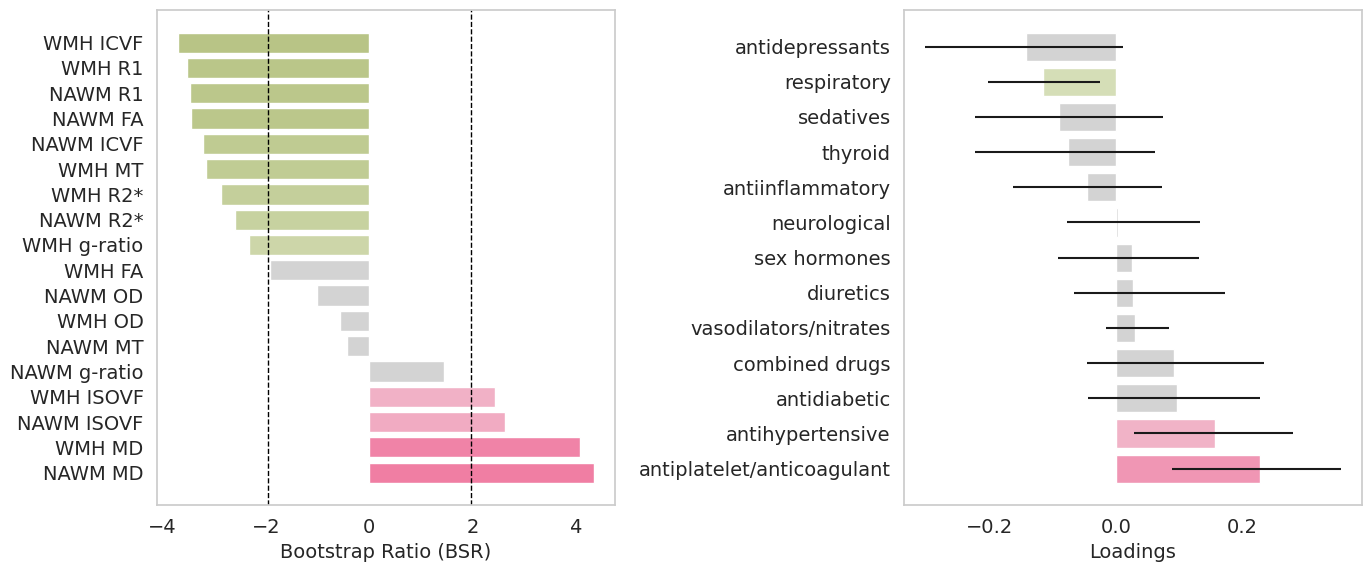

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors

# Function to categorize variable names
def categorize_variable(variable_name):
    if "_x" in variable_name.lower():
        return 'x'
    elif "_y" in variable_name.lower():
        return 'y'
    else:
        return 'other'

# === CVR variables used in your run ===

cvr_vars = [
    'n_antihypertensive', 'n_antidiabetic', 'n_antiinflammatory', 'n_thyroid', 
    'n_sedatives', 'n_antidepressants', 'n_antiplatelet_anticoagulant', 'n_neurological', 
    'n_sex_hormones', 'n_vasodilators_nitrates', 'n_diuretics', 'n_respiratory', 'n_cvr_relevant_drugs'
]

cvr_vars_display = [
   'antihypertensive', 'antidiabetic', 'antiinflammatory', 'thyroid', 
    'sedatives', 'antidepressants', 'antiplatelet/anticoagulant', 'neurological', 
    'sex hormones', 'vasodilators/nitrates', 'diuretics', 'respiratory', 'combined drugs'
]

# Set the color map (centered at 0, with the range between -0.4 and 0.4)
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# === Directory where PLS was saved ===
input_dir = '/home/a0342481/Analyses/PLS_WMH_NAWM_treatment'
output_dir = input_dir

print(f"\n=== Plotting behavioural loadings and BSR for LV1 side by side ===")

# Parameters
pval = 0.05

# Load necessary files
permres_pvals = np.loadtxt(f"{output_dir}/permres_pvals.csv", delimiter=',')
y_loadings = np.loadtxt(f"{output_dir}/y_loadings.csv", delimiter=',')

# Create output dir if needed
os.makedirs(f"{output_dir}/behavioural_loadings/", exist_ok=True)

# Define a diverging color palette centered around 0 (using seaborn)
diverging_cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# Plot the first 2 LVs (LV1 and LV2) side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Create a figure with 2 subplots side by side

# Loop over the LVs (just for LV1)
lv_idx = 0
if permres_pvals[lv_idx] <= pval:
    print(f"\n→ Plotting LV {lv_idx+1} (p={permres_pvals[lv_idx]:.4f})")

    y_load = y_loadings[:, lv_idx]
    loading_info = []

    # Loop over behavioral variables
    for j, var in enumerate(cvr_vars_display):
        ci_file_path = f"{input_dir}/y_loadings_ci/bootres_y_loadings_ci_{j}.csv"
        if os.path.exists(ci_file_path):
            y_loadings_ci = np.loadtxt(ci_file_path, delimiter=",")
            ci_pair = y_loadings_ci[lv_idx]  # For LV i
            loading_value = y_load[j]
            loading_info.append({
                "variable": var,
                "loading": loading_value,
                "ci_low": ci_pair[0],
                "ci_high": ci_pair[1],
                "category": categorize_variable(var)
            })
        else:
            print(f"Warning: CI file not found for behavior {j}: {ci_file_path}")
            loading_info.append({
                "variable": var,
                "loading": y_load[j],
                "ci_low": y_load[j],
                "ci_high": y_load[j],
                "category": categorize_variable(var)
            })

    # Sort variables by loading
    loading_info_sorted = sorted(loading_info, key=lambda x: x["loading"])

    # Prepare data for plotting
    variables = [item["variable"] for item in loading_info_sorted]
    y_load_sorted = np.array([item["loading"] for item in loading_info_sorted])
    x_error = np.array([
        [abs(item["loading"] - item["ci_low"]), abs(item["ci_high"] - item["loading"])]
        for item in loading_info_sorted
    ]).T
    categories = [item["category"] for item in loading_info_sorted]

    norm = mcolors.Normalize(vmin=-0.6, vmax=0.6)

    # Define colors using the diverging palette for significant variables
    colors = []
    for item in loading_info_sorted:
        a = item["ci_low"]
        b = item["ci_high"]
        if a * b >= 0:  # Significant if CI doesn't cross zero
            # Significant: use diverging color palette based on loading value
            normalized_loading = (item["loading"] - np.min(y_load_sorted)) / (np.max(y_load_sorted) - np.min(y_load_sorted))
            colors.append(cmap(norm(item["loading"])))  # Normalize loading to the colormap
        else:
            colors.append("lightgray")  # Non-significant bars in light grey

    # Plot Behavioral Loadings for LV1 (on the second subplot)
    axes[1].barh(np.arange(len(variables)), y_load_sorted, xerr=x_error, align='center', color=colors)
    axes[1].set_yticks(np.arange(len(variables)))
    axes[1].set_yticklabels([var.replace('_', ' ') for var in variables])  # Remove underscores from labels
    axes[1].invert_yaxis()  # Invert y-axis to have the largest loading at the top
    axes[1].set_xlabel('Loadings')
    axes[1].set_title(None)
    axes[1].grid(False)

    # BSR Plot for LV1 (on the first subplot)
    bsr_lv = bsr_values[:, lv_idx]
    df_bsr = pd.DataFrame({
        'Metric': metric_names,
        'BSR': bsr_lv
    })

    # Sort metrics by BSR (descending → positive to negative)
    df_bsr = df_bsr.sort_values('BSR', ascending=False)
    norm = mcolors.Normalize(vmin=-9, vmax=9)

    # Plot BSR
    bars = axes[0].barh(df_bsr['Metric'], df_bsr['BSR'], color=[cmap(norm(b)) if b < -1.96 or b > 1.96 else 'lightgray' for b in df_bsr['BSR']])

    # Threshold lines
    axes[0].axvline(x=1.96, color='black', linestyle='--', linewidth=1)
    axes[0].axvline(x=-1.96, color='black', linestyle='--', linewidth=1)

    # Labels for BSR plot
    axes[0].set_xlabel('Bootstrap Ratio (BSR)')
    axes[0].set_ylabel(None)
    axes[0].set_title(None)
    axes[0].set_yticklabels([var.replace('_', ' ') for var in df_bsr['Metric']])  # Remove underscores from labels
    axes[0].grid(False)

    plt.tight_layout()
    
    # Adjust layout to ensure there's no overlap between the legend and the boxplots
    plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
        'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
    
    # Save the plot
    plot_path = os.path.join(notebook_dir, f'Figures_new/PLS_NAWM_WMH_LV1_ttt.png')
    plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PLS_NAWM_WMH_LV1_ttt.svg')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
    plt.show()


## Supplementary fig 1

### Heatmap CVR

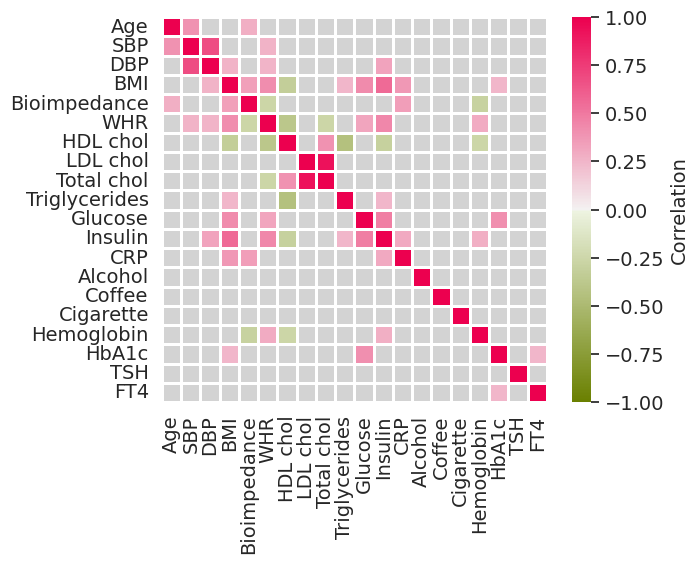

In [114]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from scipy.stats import pearsonr
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.colors as mcolors


# Define the dictionary for renaming columns
rename_dict = {
    'F3age': 'Age',
    'F3crpu': 'CRP',
    'F3conso_hebdo': 'Alcohol',
    'F3SBP': 'SBP',
    'F3DBP': 'DBP',
    'F3BMI': 'BMI',
    'F3ldlch': 'LDL chol',
    'F3trig': 'Triglycerides',
    'F3chol': 'Total chol',
    'F3hdlch': 'HDL chol',
    'F3gluc': 'Glucose',
    'F3insulin': 'Insulin',
    'F3TSH' : 'TSH',
    'F3equiv' : 'Cigarette',
    'F3WHR' : 'WHR',
    'F3hba1c':'HbA1c',
    'F3FT4': 'FT4',
    'F3bmpsc': 'Bioimpedance',
    'F3cafuse': 'Coffee',
    'F3hb' : 'Hemoglobin'
}

# List of CVR variables to calculate correlation matrix
cvr_vars = [ 
    'F3age', 'F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3WHR','F3hdlch', 'F3ldlch', 
     'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
    'F3conso_hebdo', 'F3cafuse', 
    'F3equiv', 'F3hb' ,'F3hba1c', 'F3TSH', 'F3FT4'
]

# Extract the relevant columns from the dataset
data = final_matched_rows[cvr_vars]

# Drop rows with NaN values for any of the CVRs
data_clean = data.dropna()

# Initialize empty matrices for the correlation coefficients and p-values
correlation_matrix = np.zeros((len(cvr_vars), len(cvr_vars)))
p_value_matrix = np.ones_like(correlation_matrix, dtype=float)

# Compute the correlation matrix and p-values for each CVR pair
for i in range(len(cvr_vars)):
    for j in range(len(cvr_vars)):  # Correlations are symmetric, so compute for all pairs
        # Pearson correlation and p-value
        corr, p_value = pearsonr(data_clean[cvr_vars[i]], data_clean[cvr_vars[j]])
        
        # Store correlation coefficients
        correlation_matrix[i, j] = corr
        
        # Store p-values
        p_value_matrix[i, j] = p_value

# Apply FDR correction to the p-value matrix
flat_pvalues = p_value_matrix.flatten()

# Apply FDR correction
_, corrected_p_values, _, _ = multipletests(flat_pvalues, alpha=0.05, method='fdr_bh')

# Reshape the corrected p-values back into the original p_value_matrix size
corrected_p_value_matrix = corrected_p_values.reshape(p_value_matrix.shape)

# Mask non-significant correlations (p-value > 0.05)
mask = corrected_p_value_matrix > 0.05
mask_p1=corrected_p_value_matrix < 0.05
# Rename rows and columns of the matrix using the rename_dict
renamed_cvr_vars = [rename_dict.get(var, var) for var in cvr_vars]

diverging_cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

# Plot the correlation matrix with significant correlations
plt.figure(figsize=(6.5, 5))
sns.heatmap(correlation_matrix, annot=False, cmap=diverging_cmap, fmt='.2f', vmin=-1, vmax=1, 
            mask=mask, cbar_kws={'label': 'Correlation'}, annot_kws={'size': 12}, 
            linewidths=0.5, linecolor='white',
            xticklabels=renamed_cvr_vars, yticklabels=renamed_cvr_vars, square=True)

light_gray_cmap = mcolors.LinearSegmentedColormap.from_list("light_gray", ['lightgray', 'lightgray', 'lightgray'])

sns.heatmap(correlation_matrix, annot=False, cmap=light_gray_cmap, fmt='.2f', vmin=-1, vmax=1, 
            mask=mask_p1, cbar=False, linewidths=1, linecolor='white', 
            xticklabels=renamed_cvr_vars, yticklabels=renamed_cvr_vars,square=True)

plt.title(None, fontsize=12)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
plot_path = os.path.join(notebook_dir, f'Figures_new/Heatmap_CVR.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Heatmap_CVR.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()


## Supplementary fig 2

### PC1 WMH vs PC1 NAWM

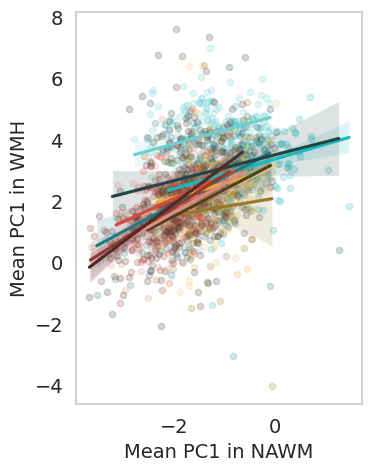

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Prepare DataFrame with PC1, PC2 and Region
df_pca = df_scaled.copy()
df_pca['PC1'] = pca_result[:, 0]
df_pca['PC2'] = pca_result[:, 1]

# Initialize a list to store the distances for PC1 and PC2 separately
centroid_distances = []

# Get unique regions
regions = df_pca['BaseRegion'].unique()

# Build color map for regions
all_regions = df_scaled['BaseRegion'].unique()  # Get all unique regions
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(all_regions)}

# Group by PR x BaseRegion
group_cols = ['PR', 'BaseRegion']

# Mean PC1 per PR x BaseRegion
mean_PC1_NAWM = df_pca[df_pca['WMH_NAWM'] == 'NAWM'].groupby(group_cols)['PC1'].mean()
mean_PC1_WMH  = df_pca[df_pca['WMH_NAWM'] == 'WMH'].groupby(group_cols)['PC1'].mean()

# Mean PC2 per PR x BaseRegion
mean_PC2_NAWM = df_pca[df_pca['WMH_NAWM'] == 'NAWM'].groupby(group_cols)['PC2'].mean()
mean_PC2_WMH  = df_pca[df_pca['WMH_NAWM'] == 'WMH'].groupby(group_cols)['PC2'].mean()

# Align PR x Region pairs
common_pairs = mean_PC1_NAWM.index.intersection(mean_PC1_WMH.index).intersection(mean_PC2_NAWM.index).intersection(mean_PC2_WMH.index)

# Build dataframe
df_plot = pd.DataFrame({
    'Mean_PC1_NAWM': mean_PC1_NAWM.loc[common_pairs].values,
    'Mean_PC1_WMH': mean_PC1_WMH.loc[common_pairs].values,
    'Mean_PC2_NAWM': mean_PC2_NAWM.loc[common_pairs].values,
    'Mean_PC2_WMH': mean_PC2_WMH.loc[common_pairs].values,
    'BaseRegion': [pair[1] for pair in common_pairs],
    'PR': [pair[0] for pair in common_pairs]
})

# Set up two subplots for PC1 and PC2
fig, axes = plt.subplots(1, 1, figsize=(4, 5))

# Plot PC1 correlation in the first subplot
for region in regions:
    df_region = df_plot[df_plot['BaseRegion'] == region]
    r_pc1, p_pc1 = pearsonr(df_region['Mean_PC1_NAWM'], df_region['Mean_PC1_WMH'])

    sns.regplot(x='Mean_PC1_NAWM', y='Mean_PC1_WMH', data=df_region,
                scatter=False, color=base_region_colors[region], label=f"{region} PC1 (r={r_pc1:.2f}, p={p_pc1:.3f})", ax=axes)

    axes.scatter(df_region['Mean_PC1_NAWM'], df_region['Mean_PC1_WMH'],
                    color=base_region_colors[region], alpha=0.2, s=20)

axes.set_title(None)
axes.set_xlabel('Mean PC1 in NAWM')
axes.set_ylabel('Mean PC1 in WMH')
axes.tick_params(axis='x')
axes.grid(False)


# Adjust the layout
plt.tight_layout()
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
plot_path = os.path.join(notebook_dir, f'Figures_new/PC1_loadings_NAWM_vs_WMH_scatterplot.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PC1_loadings_NAWM_vs_WMH_scatterplot.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()


### PC1 WMH vs PC1 NAWM per region

/tmp/ipykernel_4021517/2600299918.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


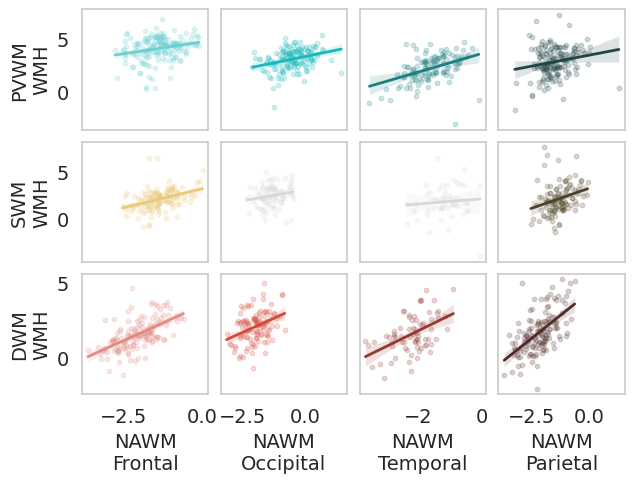

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import os

# Prepare TissueType and Lobe columns
df_scaled['TissueType'] = df_scaled['Region'].apply(
    lambda x: 'SWM' if 'SWM' in x else
              'DWM' if 'DWM' in x else
              'PVWM' if 'PVWM' in x else 'unknown'
)

df_scaled['Lobe'] = df_scaled['Region'].apply(
    lambda x: 'frontal' if 'frontal' in x else
              'parietal' if 'parietal' in x else
              'temporal' if 'temporal' in x else
              'occipital' if 'occipital' in x else 'unknown'
)

# --- Pivot tables for PC1 and PC2 ---
pivot_pc1 = df_scaled.pivot_table(index=['PR', 'TissueType', 'Lobe'], columns='WMH_NAWM', values='PC1').reset_index()
pivot_pc2 = df_scaled.pivot_table(index=['PR', 'TissueType', 'Lobe'], columns='WMH_NAWM', values='PC2').reset_index()

# Only keep rows where both NAWM and WMH exist
required_cols = {'NAWM', 'WMH'}
if required_cols.issubset(pivot_pc1.columns):
    pivot_pc1 = pivot_pc1.dropna(subset=['NAWM', 'WMH'])
else:
    raise ValueError("Missing NAWM or WMH columns in pivot_pc1")

if required_cols.issubset(pivot_pc2.columns):
    pivot_pc2 = pivot_pc2.dropna(subset=['NAWM', 'WMH'])
else:
    raise ValueError("Missing NAWM or WMH columns in pivot_pc2")

# --- Define layout ---
tissue_types = ['PVWM', 'SWM', 'DWM']
lobes = ['frontal', 'occipital', 'temporal', 'parietal']
n_rows, n_cols = 3, 4  # 3 tissue types and 4 lobes

# Generate color palette with enough colors for each tissue-lobe combination
tissue_lobe_combinations = [(tissue, lobe) for tissue in tissue_types for lobe in lobes]
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(tissue_lobe_combinations)}

# List to store p-values before FDR correction
all_p_values = []
all_beta_values = []
# Prepare subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 5), sharex='col', sharey='row', gridspec_kw={'wspace': 0.1, 'hspace': 0.1})

# --- Loop over rows (TissueType) and columns (Lobe x 2 blocks) ---
for i, tissue in enumerate(tissue_types):
    for j, lobe in enumerate(lobes):
        # Get the color for the current tissue-lobe combination
        color = base_region_colors[(tissue, lobe)]
        
        # --- NAWM vs WMH subplot ---
        ax1 = axes[i, j]
        ax1.grid(False)
        df_sub = pivot_pc1[(pivot_pc1['TissueType'] == tissue) & (pivot_pc1['Lobe'] == lobe)].copy()  # Create a copy

        if not df_sub.empty:
            # Standardize NAWM and WMH values for regression
            df_sub.loc[:, 'NAWM_standardized'] = (df_sub['NAWM'] - df_sub['NAWM'].mean()) / df_sub['NAWM'].std()
            df_sub.loc[:, 'WMH_standardized'] = (df_sub['WMH'] - df_sub['WMH'].mean()) / df_sub['WMH'].std()

            # Fit the regression model (NAWM and WMH vs TissueType and Lobe)
            X = df_sub[['WMH_standardized']]
            X = sm.add_constant(X)  # Adds a constant to the model (intercept)
            y = df_sub['NAWM_standardized']  # Assuming we are using NAWM as a dependent variable

            model = sm.OLS(y, X).fit()  # Ordinary Least Squares regression

            # Retrieve the p-values
            p_values = model.pvalues[1:]  # Exclude constant
            beta_values = model.params[1:]  # Exclude constant

            # Append p-values for later FDR correction
            all_p_values.append(p_values[0])  # Append the p-value for the WMH predictor
            all_beta_values.append(beta_values[0])  # Append the p-value for the WMH predictor

        else:
            ax1.set_visible(False)

        # --- Clean axis labels ---
        if i < 2:
            ax1.set_xlabel("")
        if j > 0:
            ax1.set_ylabel("")
        else:
            ax1.set_ylabel(f"{tissue}")

        # --- Set titles only for top row ---
        if i == 0:
            ax1.set_title(f"{lobe.capitalize()}", fontsize=14)

# --- Apply FDR correction to p-values ---
_, pvals_corrected, _, _ = multipletests(all_p_values, method='fdr_bh')

# --- Set color based on corrected p-value ---
# Re-assign colors based on the corrected p-values
all_p_values_index = 0
for i, tissue in enumerate(tissue_types):
    for j, lobe in enumerate(lobes):
        df_sub = pivot_pc1[(pivot_pc1['TissueType'] == tissue) & (pivot_pc1['Lobe'] == lobe)]

        # Get the color for the current tissue-lobe combination
        color = base_region_colors[(tissue, lobe)]
        ax1 = axes[i, j]

        # If p-value after FDR correction is less than 0.05, use tissue color, else use gray
        plot_color = color if pvals_corrected[all_p_values_index] < 0.05 else '#d8d8d8'

        # Re-color the scatter plot and the regression line
        sns.regplot(data=df_sub, x='NAWM', y='WMH', ax=ax1,
                    scatter_kws={'s': 10, 'alpha': 0.2, 'color': plot_color},
                    line_kws={'color': plot_color, 'linewidth': 2})

         # --- Clean axis labels ---
        if i < 2:
            ax1.set_xlabel(None)
            
        if i == 2:
            ax1.set_xlabel(f"NAWM\n{lobe.capitalize()}")
        if j > 0:
            ax1.set_ylabel("")
        else:
            ax1.set_ylabel(f"{tissue}\nWMH")

        # --- Set titles only for top row ---
        if i == 0:
            ax1.set_title(None, fontsize=14)

        all_p_values_index += 1  # Move to the next p-value

# --- Final touches ---
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
plot_path = os.path.join(notebook_dir, f'Figures_new/PC_loadings_NAWM_vs_WMH_scatterplot_detailed_PC1.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PC_loadings_NAWM_vs_WMH_scatterplot_detailed_PC1.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 

plt.show()


### Heatmap beta values

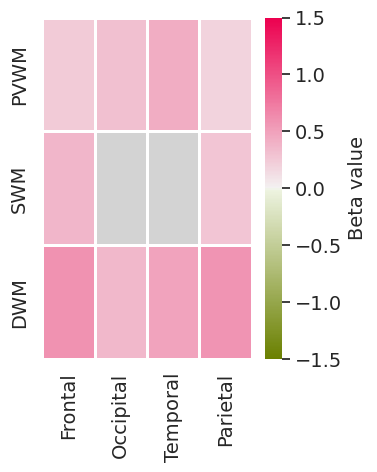

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

order_regions = [
    'PVWM_frontal', 'PVWM_occipital', 'PVWM_temporal', 'PVWM_parietal',
    'SWM_frontal', 'SWM_occipital', 'SWM_temporal', 'SWM_parietal',
    'DWM_frontal', 'DWM_occipital', 'DWM_temporal', 'DWM_parietal'
]
# Reshaping the region_betas list into a 2x12 matrix
region_betas_matrix = np.array(all_beta_values).reshape(3, 4)  # 2 rows, 12 columns
corrected_pvalues_matrix = np.array(pvals_corrected).reshape(3, 4)  # 2 rows, 12 columns

# Replace underscores with spaces for the display
regions_display = [region.replace('_', ' ') for region in order_regions]  # Replace underscores with spaces
light_gray_cmap = mcolors.LinearSegmentedColormap.from_list("light_gray", ['lightgray', 'lightgray', 'lightgray'])

# Mask for p-values >= 0.05
mask = corrected_pvalues_matrix >= 0.05

diverging_cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# Set up the figure and axis
plt.figure(figsize=(4,5))

# Plot the heatmap with the diverging color palette
sns.heatmap(region_betas_matrix, annot=False, cmap=diverging_cmap,  # .T to transpose the heatmap
            center=0, vmin=-1.5, vmax=1.5, linewidths=1, cbar_kws={'label': 'Beta value'}, 
            mask=mask, cbar=True,
            linecolor='white')


sns.heatmap(region_betas_matrix, annot=False, cmap=light_gray_cmap, xticklabels=['Frontal', 'Occipital', 'Temporal', 'Parietal'], 
            yticklabels=['PVWM', 'SWM', 'DWM'],
            mask=~mask, cbar=False, linewidths=1, linecolor='white')
    
# Set the title and labels
plt.title(None, fontsize=16)
plt.xlabel(None, fontsize=12)
plt.ylabel(None, fontsize=12)

# Show the plot
plt.tight_layout()
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
plot_path = os.path.join(notebook_dir, f'Figures_new/NAWM_vs_WMH_PC1_heatmap.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/NAWM_vs_WMH_PC1_heatmap.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 

plt.show()


### PC1 WMH/NAWM vs WMH vol

[0.39673234368952665, 0.28402007682620933, 0.38000469366046374, 0.4233932023633783, 0.29890456108170027, -0.008322297345085453, 0.07738921628105759, 0.16202625969536646, 0.3692612601102676, 0.17610565593592512, 0.29268633790147414, 0.3783543671666091, 0.19095235691933965, 0.24910210995026624, 0.3449360016976025, 0.15037573830742038, 0.2565318310238012, 0.30849359485016326, 0.16385273559517355, 0.35001711207403424, 0.3612204498617667, 0.33896273822576445, 0.5015044134137555, 0.6730134734096338]
[1.33609909e-11 6.10912273e-04 9.84905058e-06 6.73175853e-10
 5.90971638e-05 9.23672850e-01 6.46794705e-01 3.20826085e-02
 4.90101258e-08 3.20826085e-02 1.32533382e-02 6.04096332e-08
 1.37304233e-03 1.71269333e-04 2.37119071e-04 6.11852665e-02
 2.11571000e-03 8.03748701e-03 5.81564356e-01 4.61231068e-03
 5.19506099e-11 1.19199551e-04 1.19199551e-04 1.12319220e-22]


/tmp/ipykernel_4021517/2461392640.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_4021517/2461392640.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.98])


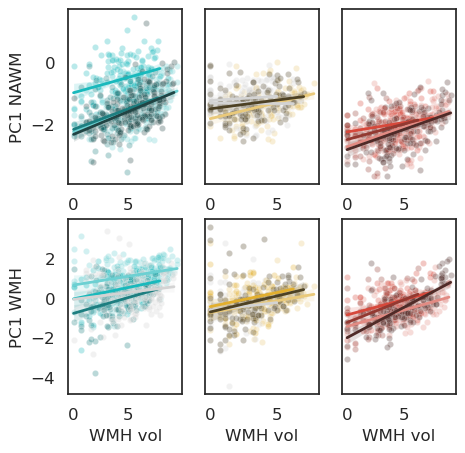

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

# Standardize the data across all regions before splitting
df_scaled_voxels_WMH['Voxel_Count_log'] = np.log(df_scaled_voxels_WMH['Voxel_Count'])

# Standardize the log of the Voxel_Count
df_scaled_voxels_WMH['Voxel_Count_log_standardized'] = (df_scaled_voxels_WMH['Voxel_Count_log'] - df_scaled_voxels_WMH['Voxel_Count_log'].mean()) / df_scaled_voxels_WMH['Voxel_Count_log'].std()

df_scaled_voxels_WMH['PC1_WMH_std'] = (df_scaled_voxels_WMH['PC1'] - df_scaled_voxels_WMH['PC1'].mean()) / df_scaled_voxels_WMH['PC1'].std()
df_scaled_voxels_NAWM['PC1_NAWM_std'] = (df_scaled_voxels_NAWM['PC1'] - df_scaled_voxels_NAWM['PC1'].mean()) / df_scaled_voxels_NAWM['PC1'].std()
df_scaled_voxels_WMH['PC1_WMH']=df_scaled_voxels_WMH['PC1']
df_scaled_voxels_NAWM['PC1_NAWM']=df_scaled_voxels_NAWM['PC1']

# Merge NAWM and WMH data on 'PR' and 'BaseRegion' to align PC1 values with WMH log volume
merged_data = pd.merge(df_scaled_voxels_NAWM[['PR', 'BaseRegion', 'PC1_NAWM_std', 'PC1_NAWM']],
                       df_scaled_voxels_WMH[['PR', 'BaseRegion','PC1_WMH_std', 'PC1_WMH', 'Voxel_Count_log_standardized','Voxel_Count_log']],
                       on=['PR', 'BaseRegion'],
                       how='inner')


merged_data['BaseRegion'] = pd.Categorical(merged_data['BaseRegion'], categories=order_regions, ordered=True)
merged_data = merged_data.sort_values(by='BaseRegion')

# Create a mapping of BaseRegion to colors (this assigns unique colors to each region)
region_color_map = {order_regions[i]: palette[i] for i in range(len(order_regions))}

# Initialize lists to store p-values and betas for each region and metric
region_betas = []
region_pvalues = []
region_names = []

# Set up the figure for a 2x3 grid (2 rows, 3 columns), sharing y-axis within each row
fig, axes = plt.subplots(2, 3, figsize=(5, 5), sharey='row', gridspec_kw={'wspace': 0.2})  # 'sharey=row' ensures y-axis is shared within each row

# First row: NAWM PC1 vs WMH Log_Voxel_Count for PVWM, SWM, DWM
for idx, region_group in enumerate(['PVWM', 'SWM', 'DWM']):
    ax = axes[0, idx]  # First row, each plot in one column
    
    # Filter data for the current region group (e.g., PVWM, SWM, DWM)
    region_filter = merged_data['BaseRegion'].str.contains(region_group)
    region_data = merged_data[region_filter]
    
    # Loop over the regions within the group (e.g., PVWM_frontal, PVWM_occipital, etc.)
    for i, region in enumerate(region_data['BaseRegion'].unique()):
        region_data_filtered = region_data[region_data['BaseRegion'] == region]

        # Apply the region color based on the region color map
        color = region_color_map[region]
        
        # Perform linear regression (PC1 vs WMH Log_Voxel_Count)
        X = sm.add_constant(region_data_filtered['Voxel_Count_log_standardized'])  # Add constant for intercept
        y = region_data_filtered['PC1_NAWM_std']  # PC1 as the dependent variable
        model = sm.OLS(y, X).fit()
        
        # Store the beta and p-value
        region_betas.append(model.params[1])  # Standardized beta
        region_pvalues.append(model.pvalues[1])  # p-value for the metric
        region_names.append(f"{region}_NAWM")
        # Check if the p-value is significant or not
        if model.pvalues[1] < 0.05:
            # Plot the scatter plot for this region with the appropriate color
            sns.scatterplot(x=region_data_filtered['Voxel_Count_log'], y=region_data_filtered['PC1_NAWM'], 
                            color=color, alpha=0.3, label=region, s=20, ax=ax)

            # Add a regression line for this region
            sns.regplot(x='Voxel_Count_log', y='PC1_NAWM', data=region_data_filtered, scatter=False, 
                        line_kws={'color': color, 'lw': 2}, ax=ax)  # Use color based on region group
        else:
            # Plot the scatter plot and regression in light gray if non-significant
            sns.scatterplot(x=region_data_filtered['Voxel_Count_log'], y=region_data_filtered['PC1_NAWM'], 
                            color='lightgray', alpha=0.3, label=region, s=20, ax=ax)

            # Add a regression line for this region in light gray
            sns.regplot(x='Voxel_Count_log', y='PC1_NAWM', data=region_data_filtered, scatter=False, 
                        line_kws={'color': 'lightgray', 'lw': 2}, ax=ax)  # Use light gray for non-significant

    # Set titles and labels
    ax.set_title(None, fontsize=12)
    ax.set_xlabel(None, fontsize=12)
    ax.set_ylabel('PC1 NAWM', fontsize=12)
    ax.grid(False)
    ax.legend().set_visible(False)  # Hide legend


# Second row: WMH PC1 vs Log_Voxel_Count for PVWM, SWM, DWM
for idx, region_group in enumerate(['PVWM', 'SWM', 'DWM']):
    ax = axes[1, idx]  # Second row, each plot in one column
    
    # Filter data for the current region group (e.g., PVWM, SWM, DWM)
    region_filter = merged_data['BaseRegion'].str.contains(region_group)
    region_data = merged_data[region_filter]
    
    # Loop over the regions within the group (e.g., PVWM_frontal, PVWM_occipital, etc.)
    for i, region in enumerate(region_data['BaseRegion'].unique()):
        region_data_filtered = region_data[region_data['BaseRegion'] == region]
        # Apply the region color based on the region color map
        color = region_color_map[region]
        
        # Perform linear regression (PC1 vs Log_Voxel_Count)
        X = sm.add_constant(region_data_filtered['Voxel_Count_log_standardized'])  # Add constant for intercept
        y = region_data_filtered['PC1_WMH_std']
        model = sm.OLS(y, X).fit()
        
        # Store the beta and p-value
        region_betas.append(model.params[1])  # Standardized beta
        region_pvalues.append(model.pvalues[1])  # p-value for the metric
        region_names.append(f"{region}_WMH")
        
        # Check if the p-value is significant or not
        if model.pvalues[1] < 0.05:
            # Plot the scatter plot for this region with the appropriate color
            sns.scatterplot(x=region_data_filtered['Voxel_Count_log'], y=region_data_filtered['PC1_WMH_std'], 
                            color=color, alpha=0.3, label=region, s=20, ax=ax)

            # Add a regression line for this region
            sns.regplot(x='Voxel_Count_log', y='PC1_WMH_std', data=region_data_filtered, scatter=False, 
                        line_kws={'color': color, 'lw': 2}, ax=ax)  # Use color based on region group
        else:
            # Plot the scatter plot and regression in light gray if non-significant
            sns.scatterplot(x=region_data_filtered['Voxel_Count_log'], y=region_data_filtered['PC1_WMH_std'], 
                            color='lightgray', alpha=0.3, label=region, s=20, ax=ax)

            # Add a regression line for this region in light gray
            sns.regplot(x='Voxel_Count_log', y='PC1_WMH_std', data=region_data_filtered, scatter=False, 
                        line_kws={'color': 'lightgray', 'lw': 2}, ax=ax)  # Use light gray for non-significant


    # Set titles and labels
    ax.set_title(None, fontsize=12)
    ax.set_xlabel('WMH vol', fontsize=12)
    ax.set_ylabel('PC1 WMH', fontsize=12)
    ax.grid(False)
    ax.legend().set_visible(False)  # Hide legend

# Apply FDR correction to the p-values
_, corrected_pvalues, _, _ = multipletests(region_pvalues, alpha=0.05, method='fdr_bh')

print(region_betas)
print(corrected_pvalues)

# Adjust layout and show the plot
plt.tight_layout()

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 12, 'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})

plot_path = os.path.join(notebook_dir, f'Figures_new/PC1_vs_Volume_split_by_region_color.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PC1_vs_Volume_split_by_region_color.svg')

plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()


### Heatmap beta PC1 WMH/NAWM vs WMH vol

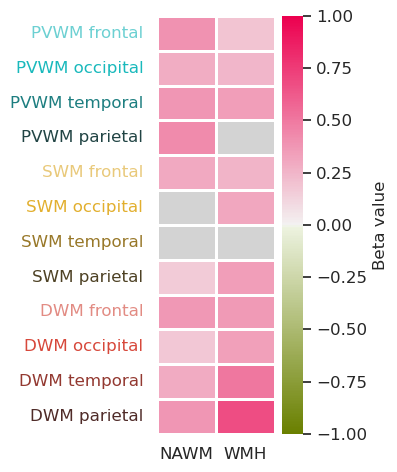

In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming `region_betas` contains the beta values and `order_regions` has the corresponding region names
# Reshaping the region_betas list into a 2x12 matrix
region_betas_matrix = np.array(region_betas).reshape(2, 12)  # 2 rows, 12 columns
corrected_pvalues_matrix = np.array(corrected_pvalues).reshape(2, 12)  # 2 rows, 12 columns

# Replace underscores with spaces for the display
regions_display = [region.replace('_', ' ') for region in order_regions]  # Replace underscores with spaces

# Mask for p-values >= 0.05
mask = corrected_pvalues_matrix >= 0.05

# Set up the figure and axis
plt.figure(figsize=(4,5))

# Plot the heatmap with the diverging color palette
sns.heatmap(region_betas_matrix.T, annot=False, cmap=diverging_cmap,  # .T to transpose the heatmap
            center=0, vmin=-1, vmax=1, linewidths=1, cbar_kws={'label': 'Beta value'}, 
            xticklabels=['NAWM', 'WMH'], yticklabels=regions_display[:12], mask=mask.T, cbar=True,
            linecolor='white')


sns.heatmap(region_betas_matrix.T, annot=False, cmap=light_gray_cmap, 
            mask=~mask.T, cbar=False, linewidths=1, xticklabels=['NAWM', 'WMH'],
            yticklabels=regions_display[:12], linecolor='white')


# Color the region names (yticklabels) with the custom palette
for i, label in enumerate(plt.gca().get_yticklabels()):
    label.set_color(palette[i])

# Set the title and labels
plt.title(None, fontsize=16)
plt.xlabel(None, fontsize=12)
plt.ylabel(None, fontsize=12)

# Show the plot
plt.tight_layout()

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 12, 'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})

plot_path = os.path.join(notebook_dir, f'Figures_new/PC1_vs_WMH_volume_heatmap.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PC1_vs_WMH_volume_heatmap.svg')

plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()


### Violin plot w or wo WMH

/tmp/ipykernel_4021517/3551707389.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.98])


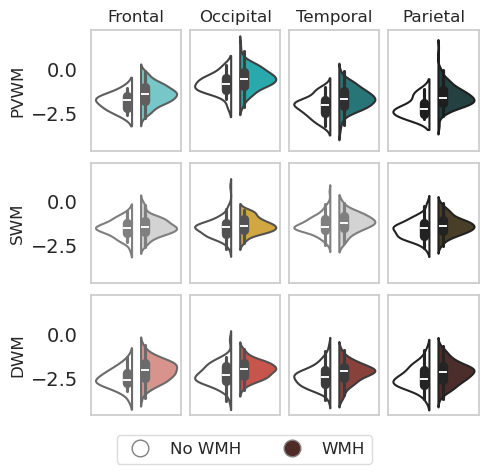

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import os

# Collect p-values + tracking info
pval_results = []

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5, 5), sharey=True, gridspec_kw={'wspace': 0.1, 'hspace': 0.1})
sns.set(style="white", font_scale=1.3)

# First loop: plot + collect p-values
for i, tissue in enumerate(tissue_types):
    for j, lobe in enumerate(lobes):
        ax = axes[i, j]
        pivot_pc1 = df_scaled.pivot_table(index=['PR', 'TissueType', 'Lobe'], columns='WMH_NAWM', values='PC1').reset_index()
        pivot_pc1['WMH_present'] = pivot_pc1['WMH'].notna().astype(int)
        pivot_pc1['WMH_present_str'] = pivot_pc1['WMH_present'].map({1: 'WMH', 0: 'No WMH'})
        df_sub = pivot_pc1[(pivot_pc1['TissueType'] == tissue) & (pivot_pc1['Lobe'] == lobe)].copy()

        hue_palette = { 'WMH': palette[i * 4 + j], 'No WMH': 'white' }

        if df_sub.empty:
            ax.set_visible(False)
            continue

        group1 = df_sub[df_sub['WMH_present_str'] == 'WMH']['NAWM'].dropna()
        group2 = df_sub[df_sub['WMH_present_str'] == 'No WMH']['NAWM'].dropna()

        if len(group1) >= 3 and len(group2) >= 3:
            stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
        else:
            p_value = 1.0

        # Store for FDR
        pval_results.append({
            'i': i,
            'j': j,
            'pval': p_value,
            'tissue': tissue,
            'lobe': lobe,
            'hue_palette': hue_palette,
            'stat':stat
        })

# Apply FDR
raw_pvals = [x['pval'] for x in pval_results]
_, pvals_fdr, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Second loop: plot violins with final coloring
for idx, result in enumerate(pval_results):
    i, j = result['i'], result['j']
    ax = axes[i, j]
    tissue = result['tissue']
    lobe = result['lobe']
    pval_fdr = pvals_fdr[idx]

    pivot_pc1 = df_scaled.pivot_table(index=['PR', 'TissueType', 'Lobe'], columns='WMH_NAWM', values='PC1').reset_index()
    pivot_pc1['WMH_present'] = pivot_pc1['WMH'].notna().astype(int)
    pivot_pc1['WMH_present_str'] = pivot_pc1['WMH_present'].map({1: 'WMH', 0: 'No WMH'})
    df_sub = pivot_pc1[(pivot_pc1['TissueType'] == tissue) & (pivot_pc1['Lobe'] == lobe)].copy()

    hue_palette = result['hue_palette'].copy()

    # Recolor to grey if not significant after FDR
    if pval_fdr >= 0.05:
        hue_palette['WMH'] = 'lightgrey'

    sns.violinplot(
        data=df_sub,
        x='WMH_present_str', y='NAWM',
        hue='WMH_present_str',
        palette=hue_palette,
        order=['No WMH', 'WMH'],
        ax=ax,
        inner="box",
        linewidth=1.5,
        saturation=0.8,
        dodge=False,
        legend=False,
        split=True,
        hue_order=['No WMH', 'WMH']
    )

    #ax.text(0.5, 0.95, f"FDR p={pval_fdr:.3f}", transform=ax.transAxes,
    #        ha='center', va='top', fontsize=10,
    #        bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))

    ax.grid(False)


                # Format x-axis
    if i == n_rows - 1:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    if j == 0:
        ax.set_ylabel(f"{tissue}", fontsize=12)
    else:
        ax.set_ylabel("")

    if i == 0:
        ax.set_title(lobe.capitalize(), fontsize=12)
    else:
        ax.set_title("")

# Create legend manually
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='No WMH',
               markerfacecolor=hue_palette['No WMH'],markeredgecolor='gray',  markersize=12),  # Use color from palette
    plt.Line2D([0], [0], marker='o', color='w', label='WMH',
               markerfacecolor=hue_palette['WMH'], markeredgecolor='gray', markersize=12)  # Use color from palette
]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=True, facecolor='white', edgecolor='lightgrey', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 12,
    'axes.titlesize': 12, 'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
plot_path = os.path.join(notebook_dir, f'Figures_new/PC_loadings_NAWM_with_wo_WMH.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/PC_loadings_NAWM_with_wo_WMH.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()

### Mean PC1 with or without 

In [100]:
import pandas as pd

# We will store means here
mean_results = []

for i, tissue in enumerate(tissue_types):
    for j, lobe in enumerate(lobes):
        pivot_pc1 = df_scaled.pivot_table(index=['PR', 'TissueType', 'Lobe'], columns='WMH_NAWM', values='PC1').reset_index()
        pivot_pc1['WMH_present'] = pivot_pc1['WMH'].notna().astype(int)
        pivot_pc1['WMH_present_str'] = pivot_pc1['WMH_present'].map({1: 'WMH', 0: 'No WMH'})
        df_sub = pivot_pc1[(pivot_pc1['TissueType'] == tissue) & (pivot_pc1['Lobe'] == lobe)].copy()

        if df_sub.empty:
            continue

        # Calculate means for both groups
        mean_wmh = df_sub[df_sub['WMH_present_str'] == 'WMH']['NAWM'].mean()
        mean_nowmh = df_sub[df_sub['WMH_present_str'] == 'No WMH']['NAWM'].mean()

        mean_results.append({
            'Tissue': tissue,
            'Lobe': lobe,
            'Mean_PC1_WMH': mean_wmh,
            'Mean_PC1_No_WMH': mean_nowmh
        })

# Convert to DataFrame for nice display
mean_df = pd.DataFrame(mean_results)

# Show the table
print(mean_df)

   Tissue       Lobe  Mean_PC1_WMH  Mean_PC1_No_WMH
0    PVWM    frontal     -1.399636        -1.825449
1    PVWM  occipital     -0.523742        -0.807317
2    PVWM   temporal     -1.626105        -2.083126
3    PVWM   parietal     -1.515433        -2.160873
4     SWM    frontal     -1.401796        -1.492118
5     SWM  occipital     -1.320483        -1.455183
6     SWM   temporal     -1.168630        -1.304607
7     SWM   parietal     -1.329501        -1.537625
8     DWM    frontal     -2.067471        -2.510821
9     DWM  occipital     -2.001166        -2.277955
10    DWM   temporal     -2.194534        -2.406268
11    DWM   parietal     -2.175958        -2.447505


## Supplementary figure 3

### Age relationship plot per layers

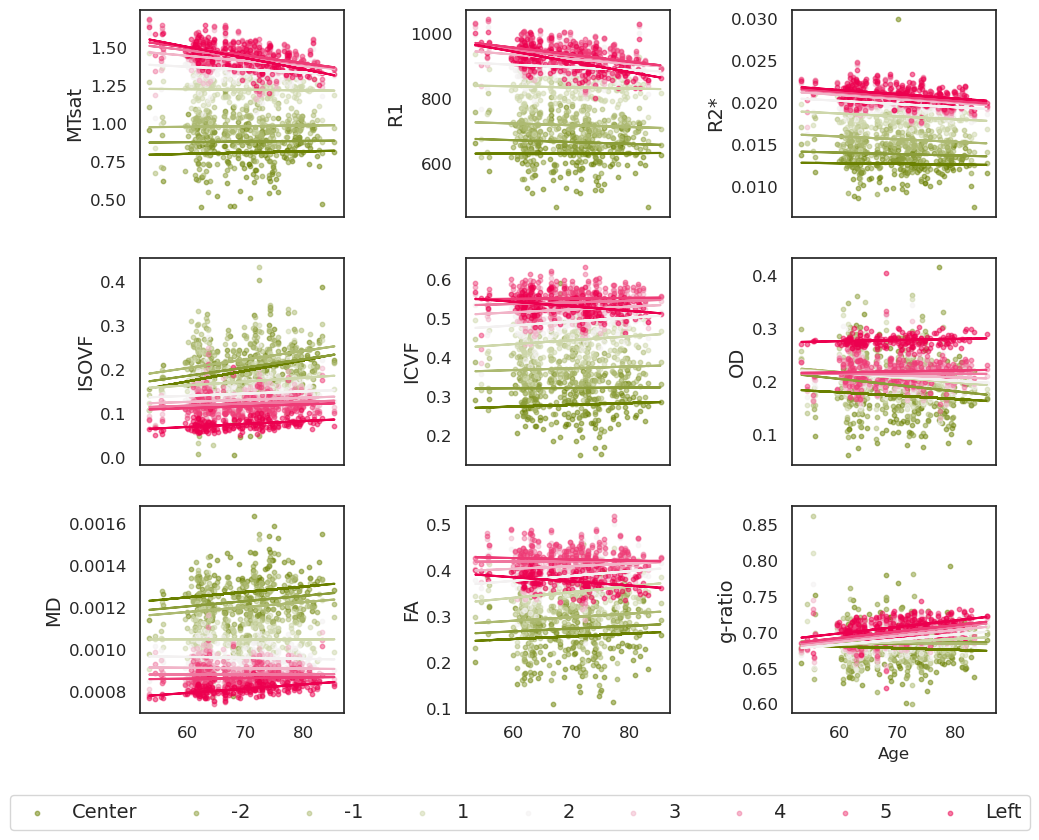

In [110]:
import os
import pickle
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler

# Define groups (layers) and metrics to iterate over
groups_to_plot = {
    'Center': 'WMH_center',
    '-2': 'InnerLayer2',
    '-1': 'InnerLayer1',
    '1': 'Layer1',
    '2': 'Layer2',
    '3': 'Layer3',
    '4': 'Layer4',
    '5': 'Layer5',
    'Left': 'WM_left'
}

metrics_to_plot = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_to_plot1 = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_to_plot2 = ['MT', 'R1', 'R2s', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']  # Updated 'R2*' to 'R2s'

# Initialize a dictionary to store the data for each metric
metric_dfs = {}

# Loop through each metric and layer to extract corresponding values
for metric in metrics_to_plot:
    metric_data = combined_mean_metrics_data_cross_sectionnal.get(f'Mean_Metrics_In_{metric}', {})
    
    # List to store data for this metric
    metric_data_list = []
    
    # Loop through each layer
    for group_label, mask in groups_to_plot.items():
        if mask in metric_data:
            layer_data = metric_data[mask]
            
            # Extract scalar values (if they are lists, take the first value)
            if isinstance(layer_data, dict):
                layer_values = list(layer_data.values())
                layer_values = [value[0] if isinstance(value, list) else value for value in layer_values]
                
                # Create DataFrame for this metric and layer
                df = pd.DataFrame({
                    'PR': list(layer_data.keys()),
                    f'{metric}': layer_values,  # Add metric values
                    'Layer': [group_label] * len(layer_data)  # Add layer label
                })
                
                # Append to list for this metric
                metric_data_list.append(df)
    
    # Concatenate data for the current metric and store in dictionary
    if metric_data_list:
        metric_df = pd.concat(metric_data_list, ignore_index=True)
        metric_dfs[metric] = metric_df

# Merge all metric DataFrames on 'PR' and 'Layer'
final_df = metric_dfs['MT']  # Start with 'MT'

# Merge other metric DataFrames on 'PR' and 'Layer'
for metric, df in metric_dfs.items():
    if metric != 'MT':
        final_df = pd.merge(final_df, df[['PR', 'Layer', metric]], on=['PR', 'Layer'], how='inner')

# Merge with final_matched_rows for additional info
final_df = pd.merge(final_df, final_matched_rows, on=['PR'], how='inner')

# Ensure the 'Layer' column is ordered correctly
final_df['Layer'] = pd.Categorical(final_df['Layer'], categories=groups_to_plot.keys(), ordered=True)

# Rename columns for consistency (e.g., 'g-ratio' -> 'g_ratio', 'R2*' -> 'R2s')
final_df.rename(columns={'F3age': 'Age','g-ratio': 'g_ratio', 'R2*': 'R2s'}, inplace=True)


# Define the diverging color map for layers
diverging_cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

def plot_metrics_vs_age_per_layer(final_df, groups_to_plot, metrics_to_plot, cvr_of_interest='Age'):
    # Set up a grid for the plots (3x3 grid)
    num_metrics = len(metrics_to_plot)
    num_rows = (num_metrics // 3)  # Adjust rows based on number of metrics
    fig, axes = plt.subplots(3, 3, figsize=(10, 8), sharex=True)
    axes = axes.flatten()  # Flatten the axes to make indexing easier

    # Create a color map based on the layers
    layers = final_df['Layer'].unique()  # Get unique layers
    layer_colors = diverging_cmap(np.linspace(0, 1, len(layers)))  # Generate a diverging color palette based on the layers
    
    # Create a mapping from layer names to colors
    layer_color_map = dict(zip(layers, layer_colors))

    # Loop through each metric to plot
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]  # Get the axis for the current subplot

        # Extract the data for the metric
        # Filter the dataframe for the current metric and remove rows with NaN values for Age or the current metric
        metric_data = final_df[['PR', 'Layer', metric, 'Age']].dropna(subset=['Age', metric])

        # Loop through each layer and plot the data for the current metric
        for layer in layers:
            layer_data = metric_data[metric_data['Layer'] == layer]

            # Plot the data points, color by layer
            ax.scatter(layer_data['Age'], layer_data[metric], alpha=0.5, s=10,
                       color=layer_color_map[layer], label=f'{layer}')  # Scatter plot for data points
            # Fit a linear regression model for each layer
            X = layer_data['Age'].values.reshape(-1, 1)
            y = layer_data[metric].values
            model = LinearRegression().fit(X, y)
            y_pred = model.predict(X)

            # Plot the regression line
            ax.plot(layer_data['Age'], y_pred, color=layer_color_map[layer])  

        # Set labels and title for each subplot
        ax.set_title(None)
        ax.set_xlabel(f'{cvr_of_interest}', fontsize=12)
        ax.grid(False)
        
        ax.tick_params(axis='y', labelsize=12)
        ax.tick_params(axis='x', labelsize=12)
        ax.set_ylabel(metrics_to_plot1[idx])

        # Remove x-axis label for all but the last row
        if idx < len(metrics_to_plot) - 1:  # Remove x-axis label for all but last row
            ax.set_xlabel('')

    
    # Add a common legend at the bottom of the grid
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=9)

    # Adjust layout and make room for the legend
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.6, hspace=0.2)
    plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
        'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
    
    # Save the plot
    plot_path = os.path.join(notebook_dir, f'Figures_new/Layer_linear_fit_per_layer.png')
    plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Layer_linear_fit_per_layer.svg')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
    # Show the plot
    plt.show()

# Example: Use the function with selected PRs and final_df
cvr_of_interest = 'Age'  # Or any other CVR variable you want to plot

# Example for the groups_to_plot and metrics_to_plot (you will need to define these as per your data)
groups_to_plot = ['WMH_center', 'InnerLayer2', 'InnerLayer1', 'Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5', 'WM_left']  # Layers to plot
metrics_to_plot = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']  # Example metrics

# Call the function with the final_df data
plot_metrics_vs_age_per_layer(final_df, groups_to_plot, metrics_to_plot2, cvr_of_interest='Age')


### Significant values heatmap

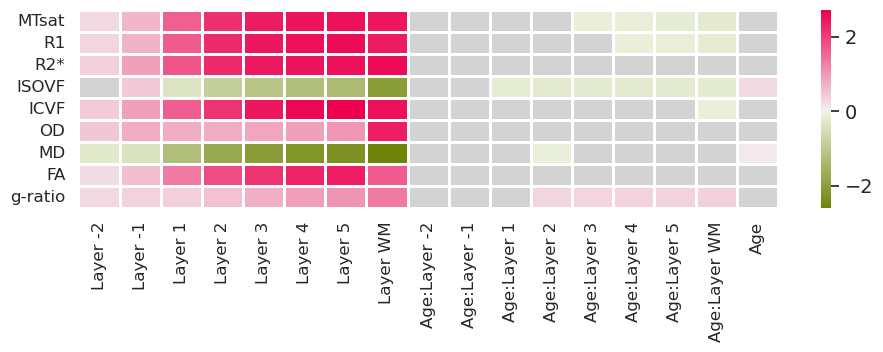

In [112]:
import os
import pickle
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler

# Define groups (layers) and metrics to iterate over
groups_to_plot = {
    'Center': 'WMH_center',
    '-2': 'InnerLayer2',
    '-1': 'InnerLayer1',
    '1': 'Layer1',
    '2': 'Layer2',
    '3': 'Layer3',
    '4': 'Layer4',
    '5': 'Layer5',
    'WM': 'WM_left'
}

metrics_to_plot = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_to_plot1 = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_to_plot2 = ['MT', 'R1', 'R2s', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']  # Updated 'R2*' to 'R2s'

# Initialize a dictionary to store the data for each metric
metric_dfs = {}

# Loop through each metric and layer to extract corresponding values
for metric in metrics_to_plot:
    metric_data = combined_mean_metrics_data_cross_sectionnal.get(f'Mean_Metrics_In_{metric}', {})
    
    # List to store data for this metric
    metric_data_list = []
    
    # Loop through each layer
    for group_label, mask in groups_to_plot.items():
        if mask in metric_data:
            layer_data = metric_data[mask]
            
            # Extract scalar values (if they are lists, take the first value)
            if isinstance(layer_data, dict):
                layer_values = list(layer_data.values())
                layer_values = [value[0] if isinstance(value, list) else value for value in layer_values]
                
                # Create DataFrame for this metric and layer
                df = pd.DataFrame({
                    'PR': list(layer_data.keys()),
                    f'{metric}': layer_values,  # Add metric values
                    'Layer': [group_label] * len(layer_data)  # Add layer label
                })
                
                # Append to list for this metric
                metric_data_list.append(df)
    
    # Concatenate data for the current metric and store in dictionary
    if metric_data_list:
        metric_df = pd.concat(metric_data_list, ignore_index=True)
        metric_dfs[metric] = metric_df

# Merge all metric DataFrames on 'PR' and 'Layer'
final_df = metric_dfs['MT']  # Start with 'MT'

# Merge other metric DataFrames on 'PR' and 'Layer'
for metric, df in metric_dfs.items():
    if metric != 'MT':
        final_df = pd.merge(final_df, df[['PR', 'Layer', metric]], on=['PR', 'Layer'], how='inner')

# Merge with final_matched_rows for additional info
final_df = pd.merge(final_df, final_matched_rows, on=['PR'], how='inner')

# Ensure the 'Layer' column is ordered correctly
final_df['Layer'] = pd.Categorical(final_df['Layer'], categories=groups_to_plot.keys(), ordered=True)

# Rename columns for consistency (e.g., 'g-ratio' -> 'g_ratio', 'R2*' -> 'R2s')
final_df.rename(columns={'F3age': 'Age','g-ratio': 'g_ratio', 'R2*': 'R2s'}, inplace=True)

# Z-score standardization of 'F3age' and all metrics
scaler = StandardScaler()

# List of columns to standardize
columns_to_standardize = ['Age'] + metrics_to_plot2

# Apply standardization
final_df[columns_to_standardize] = scaler.fit_transform(final_df[columns_to_standardize])

# Initialize dictionaries to store betas and p-values
beta_dict = {}
pvalue_dict = {}

# Loop through each metric, standardize variables, and fit the OLS model
for metric in metrics_to_plot2:
    df = final_df.dropna(subset=['Layer', 'Age', metric])  # Drop rows with missing values
    
    # Fit the OLS model with interaction term
    model = smf.ols(f'{metric} ~ Age * Layer', data=df).fit()
    
    # Store betas and p-values for the current metric
    beta_dict[metric] = {
        'Intercept': model.params['Intercept'],
        'Age': model.params['Age'],
        'Layer': {f'Layer[T.{layer}]': model.params.get(f'Layer[T.{layer}]', np.nan) for layer in final_df['Layer'].unique() if layer != 'Center'},
        'Interaction': {f'Age:Layer[T.{layer}]': model.params.get(f'Age:Layer[T.{layer}]', np.nan) for layer in final_df['Layer'].unique() if layer != 'Center'}
    }
    
    pvalue_dict[metric] = {
        'Intercept': model.pvalues['Intercept'],
        'Age': model.pvalues['Age'],
        'Layer': {f'Layer[T.{layer}]': model.pvalues.get(f'Layer[T.{layer}]', np.nan) for layer in final_df['Layer'].unique() if layer != 'Center'},
        'Interaction': {f'Age:Layer[T.{layer}]': model.pvalues.get(f'Age:Layer[T.{layer}]', np.nan) for layer in final_df['Layer'].unique() if layer != 'Center'}
    }

# Flatten p-values for correction
flat_pvalues = []
for metric in metrics_to_plot2:
    flat_pvalues.extend(pvalue_dict[metric]['Layer'].values())
    flat_pvalues.extend(pvalue_dict[metric]['Interaction'].values())
    flat_pvalues.append(pvalue_dict[metric]['Age'])  # Add F3age p-value to the list

# Perform FDR correction on p-values
corrected_pvalues = multipletests(flat_pvalues, method='fdr_bh')[1]

# Reassign corrected p-values to the pvalue_dict
corrected_pvalues_index = 0
for metric in metrics_to_plot2:
    pvalue_dict[metric]['Layer'] = {f'Layer[T.{layer}]': corrected_pvalues[corrected_pvalues_index] for layer in final_df['Layer'].unique() if layer != 'Center'}
    corrected_pvalues_index += len([layer for layer in final_df['Layer'].unique() if layer != 'Center'])
    
    pvalue_dict[metric]['Interaction'] = {f'Age:Layer[T.{layer}]': corrected_pvalues[corrected_pvalues_index] for layer in final_df['Layer'].unique() if layer != 'Center'}    
    corrected_pvalues_index += len([layer for layer in final_df['Layer'].unique() if layer != 'Center'])
    
    pvalue_dict[metric]['Age'] = corrected_pvalues[corrected_pvalues_index]  # Reassign corrected F3age p-value
    corrected_pvalues_index += 1  # Move to next p-value index

# Prepare the matrix of betas for heatmap
flat_betas = []
for metric in metrics_to_plot2:
    flat_betas.extend(beta_dict[metric]['Layer'].values())
    flat_betas.extend(beta_dict[metric]['Interaction'].values())
    flat_betas.append(beta_dict[metric]['Age'])  # Add F3age beta to the list

# Reshape the betas for the heatmap
beta_matrix = np.array(flat_betas).reshape(len(metrics_to_plot2), len([layer for layer in final_df['Layer'].unique() if layer != 'Center']) * 2 + 1)

# Prepare the DataFrame for betas heatmap
beta_df = pd.DataFrame(beta_matrix, columns=[f'Layer {layer}' for layer in final_df['Layer'].unique() if layer != 'Center'] +
                                          [f'Age:Layer {layer}' for layer in final_df['Layer'].unique() if layer != 'Center'] + ['Age'])

beta_df.index = metrics_to_plot2


# Plot the heatmap for corrected p-values (after FDR correction)
corrected_pvalues_df = pd.DataFrame(np.array(corrected_pvalues).reshape(len(metrics_to_plot2), len([layer for layer in final_df['Layer'].unique() if layer != 'Center']) * 2 + 1),
                                    columns=[f'Layer {layer}' for layer in final_df['Layer'].unique() if layer != 'Center'] +
                                            [f'Age:Layer {layer}' for layer in final_df['Layer'].unique() if layer != 'Center'] + ['Age'])

corrected_pvalues_df.index = metrics_to_plot1
mask_p = corrected_pvalues_df > 0.05
mask_p1 = corrected_pvalues_df < 0.05

beta_df.index = metrics_to_plot1
light_gray_cmap = mcolors.LinearSegmentedColormap.from_list("light_gray", ['lightgray', 'lightgray', 'lightgray'])


# Plot the heatmap for betas with p-value mask
plt.figure(figsize=(10, 4))
sns.heatmap(beta_df, annot=False, cmap=diverging_cmap, center=0, mask=mask_p,linewidths=0.5, linecolor='white')
sns.heatmap(beta_df, annot=False, cmap=light_gray_cmap, mask=mask_p1, cbar=False, linewidths=1, linecolor='white')
plt.title(None, fontsize=16)
plt.xlabel(None)
plt.ylabel(None)
plt.tight_layout()
plt.grid(None)

plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)


plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
        'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
    
    # Save the plot
plot_path = os.path.join(notebook_dir, f'Figures_new/Layers_age_interaction_heatmap.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures_new/Layers_age_interaction_heatmap.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()


## Additionnal tables

### ATC table

In [89]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os
from pyls import behavioral_pls

# Function to create region DataFrame
def create_region_df(region_name):
    all_metrics = list(combined_mean_metrics_data_cross_sectionnal.keys())
    data_per_pr = {}

    for metric in all_metrics:
        metric_data = combined_mean_metrics_data_cross_sectionnal[metric].get(region_name, {})
        for pr, values in metric_data.items():
            if pr not in data_per_pr:
                data_per_pr[pr] = {}
            data_per_pr[pr][metric] = values[0] if values else None

    region_df = pd.DataFrame.from_dict(data_per_pr, orient='index')
    region_df.index.name = 'PR'
    region_df.reset_index(inplace=True)
    return region_df

# === PARAMETERS ===
cvr_vars = [ 'F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch', 
             'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
            'F3conso_hebdo', 'F3cafuse', 
             'F3equiv', 'F3antiHTA', 'F3antiDIAB', 'F3hba1c', 'F3TSH', 'F3FT4', 'F3hb', 'F3age','F3hypolip', 'F3metab_synd',
           'F3ATC1', 'F3ATC2', 'F3ATC3', 'F3ATC4']

# === Build region_dfs ===
print("\nCreating DataFrames for WMH and NAWM")
wmh_df = create_region_df('WMH')
nawm_df = create_region_df('NAWM')

# === VALID PRs ===
valid_prs_wmh = wmh_df[wmh_df.drop(columns='PR').notna().any(axis=1)]['PR']
valid_prs_nawm = nawm_df[nawm_df.drop(columns='PR').notna().any(axis=1)]['PR']
valid_prs_cvr = final_matched_rows[final_matched_rows[cvr_vars].notna().any(axis=1)]['PR']

# === Intersection ===
common_prs = set(valid_prs_wmh).intersection(set(valid_prs_nawm)).intersection(set(valid_prs_cvr))
print(f"Common PRs: {len(common_prs)}")

# === Filter DataFrames ===
filtered_wmh = wmh_df[wmh_df['PR'].isin(common_prs)].copy()
filtered_nawm = nawm_df[wmh_df['PR'].isin(common_prs)].copy()  # Note: force same PR order as wmh_df
filtered_cvr = final_matched_rows[final_matched_rows['PR'].isin(common_prs)].copy()

# === Reorder filtered_cvr to match filtered_wmh['PR']
wmh_prs = filtered_wmh['PR'].tolist()
cvr_prs = filtered_cvr['PR'].tolist()

# Safe reorder
common_ordered_prs = [pr for pr in wmh_prs if pr in cvr_prs]
filtered_cvr = filtered_cvr.set_index('PR').loc[common_ordered_prs].reset_index()

# === Prepare metrics dataframe (concatenate WMH and NAWM metrics) ===
metrics_wmh = filtered_wmh.reset_index(drop=True).drop(columns='PR')
metrics_nawm = filtered_nawm.reset_index(drop=True).drop(columns='PR')

# Rename columns
metrics_wmh = metrics_wmh.rename(columns={col: f'WMH_{col.replace("Mean_Metrics_In_", "")}' for col in metrics_wmh.columns})
metrics_nawm = metrics_nawm.rename(columns={col: f'NAWM_{col.replace("Mean_Metrics_In_", "")}' for col in metrics_nawm.columns})

# Concatenate along columns
metrics_combined = pd.concat([metrics_wmh, metrics_nawm], axis=1)

# === Prepare CVR dataframe ===
cvr_vars_with_pr = ['PR'] + cvr_vars
cvr_df_common = filtered_cvr[cvr_vars_with_pr].reset_index(drop=True)
cvr_df_common = cvr_df_common.set_index('PR').loc[filtered_wmh['PR']].reset_index()

cvr_df_common_no_pr = cvr_df_common.drop(columns='PR')
cvr_df_common_no_pr = cvr_df_common_no_pr.rename(columns={col: col[2:] if col.startswith('F3') else col for col in cvr_df_common_no_pr.columns})

# List of ATC columns
atc_cols = ['ATC1', 'ATC2', 'ATC3', 'ATC4']

# Extended ATC class mapping
atc_classes = {
    'n_antihypertensive': ['C02', 'C07', 'C08', 'C09'],
    'n_antidiabetic': ['A10'],
    'n_antiinflammatory': ['M01', 'H02', 'L04'],
    'n_thyroid': ['H03AA'],
    'n_sedatives': ['N05C', 'N05BA'],
    'n_antidepressants': ['N06A'],
    'n_antiplatelet_anticoagulant': ['B01AC', 'B01AF'],
    'n_neurological': ['N03', 'N04', 'N05A', 'N06D'],
    'n_sex_hormones': ['G03'],
    'n_vasodilators_nitrates': ['C01'],
    'n_diuretics': ['C03'],
    'n_respiratory': ['R03']
}

# Count drugs per class
for class_name, prefixes in atc_classes.items():
    cvr_df_common_no_pr[class_name] = cvr_df_common_no_pr[atc_cols].apply(
        lambda row: sum(str(code).startswith(prefix) for code in row if pd.notnull(code) for prefix in prefixes),
        axis=1
    )

# Optionally, total number of relevant drugs
cvr_df_common_no_pr['n_cvr_relevant_drugs'] = cvr_df_common_no_pr[[*atc_classes]].sum(axis=1)




Creating DataFrames for WMH and NAWM
Common PRs: 200


In [90]:
# List of ATC columns
atc_cols = ['ATC1', 'ATC2', 'ATC3', 'ATC4']

# Extended ATC class mapping
atc_classes = {
    'n_antihypertensive': ['C02', 'C03', 'C07', 'C08', 'C09'],
    'n_antidiabetic': ['A10'],
    'n_antiinflammatory': ['M01', 'H02', 'L04'],
    'n_thyroid': ['H03AA'],
    'n_sedatives': ['N05C', 'N05BA'],
    'n_antidepressants': ['N06A'],
    'n_antiplatelet_anticoagulant': ['B01AC', 'B01AF'],
    'n_neurological': ['N03', 'N04', 'N05A', 'N06D'],
    'n_sex_hormones': ['G03'],
    'n_vasodilators_nitrates': ['C01'],
    'n_diuretics': ['C03'],
    'n_respiratory': ['R03']
}

# Count drugs per class
for class_name, prefixes in atc_classes.items():
    cvr_df_common_no_pr[class_name] = cvr_df_common_no_pr[atc_cols].apply(
        lambda row: sum(str(code).startswith(prefix) for code in row if pd.notnull(code) for prefix in prefixes),
        axis=1
    )

# Optionally, total number of relevant drugs
cvr_df_common_no_pr['n_cvr_relevant_drugs'] = cvr_df_common_no_pr[[*atc_classes]].sum(axis=1)

# Select only the CVR drug count columns
cvr_drug_cols = list(atc_classes.keys()) + ['n_cvr_relevant_drugs']

# Summary table
summary_table = pd.DataFrame({
    'Variables': cvr_drug_cols,
    'n_NaN': cvr_df_common_no_pr[cvr_drug_cols].isna().sum(),
    'Min': cvr_df_common_no_pr[cvr_drug_cols].min(),
    'Max': cvr_df_common_no_pr[cvr_drug_cols].max(),
    'Mean': cvr_df_common_no_pr[cvr_drug_cols].mean(),
    'Std': cvr_df_common_no_pr[cvr_drug_cols].std()
})

# Round mean for clarity (optional)
summary_table['Mean'] = summary_table['Mean'].round(2)
summary_table['Std'] = summary_table['Std'].round(2)

df = pd.DataFrame(summary_table)

df.to_csv('CSV/ACT_table.csv', index=False)  # index=False removes the row numbers


## Left

In [ ]:
from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# --- Clean & prepare ---
tmp = df_scaled_voxels_NAWM_WMH[['PR','BaseRegion','Percent_WMH']].copy()
tmp['Percent_WMH'] = pd.to_numeric(tmp['Percent_WMH'], errors='coerce')
tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna(subset=['Percent_WMH'])

# If multiple rows per PR×BaseRegion, average first
tmp = tmp.groupby(['PR','BaseRegion'], as_index=False)['Percent_WMH'].mean()

# Keep only regions with enough data and non-zero variance
MIN_N = 3
counts = tmp.groupby('BaseRegion')['Percent_WMH'].count()
vars_  = tmp.groupby('BaseRegion')['Percent_WMH'].var()

valid_regions = counts[(counts >= MIN_N)].index.tolist()
valid_regions = [r for r in valid_regions if vars_.get(r, np.nan) not in (0, np.nan)]
# respect your preferred order if available
if 'base_region_order_wmh' in locals():
    valid_regions = [r for r in base_region_order_wmh if r in valid_regions]
else:
    valid_regions = sorted(valid_regions)

# --- Kruskal–Wallis across valid regions ---
if len(valid_regions) < 2:
    print("Not enough valid regions for Kruskal–Wallis after filtering (need ≥2).")
else:
    groups = [tmp.loc[tmp['BaseRegion'] == r, 'Percent_WMH'].values for r in valid_regions]
    kw_H, kw_p = stats.kruskal(*groups)  # all arrays finite, n≥3, var>0
    print(f"[Kruskal–Wallis] H={kw_H:.2f}, p={kw_p:.3e}  (k={len(valid_regions)} regions)")
    if kw_p >= 0.05:
        print("No global region effect (α=0.05). Pairwise tests shown for completeness below.")

    # --- Pairwise Mann–Whitney + FDR, with effect sizes ---
    def cliffs_delta(a, b):
        a = np.asarray(a); b = np.asarray(b)
        diff = a[:, None] - b[None, :]
        return (np.sum(diff > 0) - np.sum(diff < 0)) / diff.size

    rows = []
    for r1, r2 in combinations(valid_regions, 2):
        a = tmp.loc[tmp['BaseRegion'] == r1, 'Percent_WMH'].values
        b = tmp.loc[tmp['BaseRegion'] == r2, 'Percent_WMH'].values
        # safety (should be fine after filtering)
        if len(a) < MIN_N or len(b) < MIN_N or np.var(a) == 0 or np.var(b) == 0:
            U, p, delta = np.nan, np.nan, np.nan
        else:
            U, p = stats.mannwhitneyu(a, b, alternative='two-sided')
            delta = cliffs_delta(a, b)
        rows.append({
            'RegionA': r1, 'RegionB': r2,
            'nA': len(a), 'nB': len(b),
            'medianA': np.median(a), 'medianB': np.median(b),
            'median_diff(A-B)': np.median(a) - np.median(b),
            'U': U, 'p_raw': p, 'cliffs_delta': delta
        })

    pairwise = pd.DataFrame(rows)
    # FDR
    mask = pairwise['p_raw'].notna()
    p_adj = np.full(len(pairwise), np.nan)
    if mask.any():
        _, p_adj[mask], _, _ = multipletests(pairwise.loc[mask, 'p_raw'], method='fdr_bh')
    pairwise['p_fdr'] = p_adj
    pairwise['significant_0.05'] = pairwise['p_fdr'] < 0.05

    # Order nicely
    pairwise['RegionA'] = pd.Categorical(pairwise['RegionA'], categories=valid_regions, ordered=True)
    pairwise['RegionB'] = pd.Categorical(pairwise['RegionB'], categories=valid_regions, ordered=True)
    pairwise = pairwise.sort_values(['RegionA','RegionB']).reset_index(drop=True)

    print("\n=== Pairwise Mann–Whitney (two-sided), BH/FDR corrected ===")
    print(pairwise[['RegionA','RegionB','nA','nB','medianA','medianB',
                    'median_diff(A-B)','cliffs_delta','p_raw','p_fdr','significant_0.05']].round(4))

    # Optional median-difference matrix
    mat = pairwise.pivot(index='RegionA', columns='RegionB', values='median_diff(A-B)')
    mat_full = mat.copy()
    for i, r1 in enumerate(valid_regions):
        for j, r2 in enumerate(valid_regions):
            if j < i:
                mat_full.loc[r1, r2] = -mat_full.loc[r2, r1]
    print("\n=== Matrix of median differences (A-B) ===")
    print(mat_full.round(3))

    # Optional: Dunn’s (if installed)
    try:
        import scikit_posthocs as sp
        dunn = sp.posthoc_dunn(tmp[tmp['BaseRegion'].isin(valid_regions)],
                               val_col='Percent_WMH', group_col='BaseRegion', p_adjust='fdr_bh')
        dunn = dunn.reindex(index=valid_regions, columns=valid_regions)
        print("\n=== Dunn’s test (FDR-corrected p-values) ===")
        print(dunn.round(4))
    except Exception:
        pass


[Kruskal–Wallis] H=nan, p=nan  (k=12 regions)

=== Pairwise Mann–Whitney (two-sided), BH/FDR corrected ===
          RegionA         RegionB   nA   nB  medianA  medianB  \
0    PVWM_frontal  PVWM_occipital  183  183      NaN      NaN   
1    PVWM_frontal   PVWM_temporal  183  183      NaN      NaN   
2    PVWM_frontal   PVWM_parietal  183  183      NaN      NaN   
3    PVWM_frontal     SWM_frontal  183  183      NaN      NaN   
4    PVWM_frontal   SWM_occipital  183  183      NaN      NaN   
..            ...             ...  ...  ...      ...      ...   
61    DWM_frontal    DWM_temporal  183  183      NaN      NaN   
62    DWM_frontal    DWM_parietal  183  183      NaN      NaN   
63  DWM_occipital    DWM_temporal  183  183      NaN      NaN   
64  DWM_occipital    DWM_parietal  183  183      NaN      NaN   
65   DWM_temporal    DWM_parietal  183  183      NaN      NaN   

    median_diff(A-B)  cliffs_delta  p_raw  p_fdr  significant_0.05  
0                NaN        0.0010    NaN  